In [1]:
# Top of notebook
%config InlineBackend.figure_formats = ['jpeg']
%config InlineBackend.rc = {'figure.dpi': 100}

In [2]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem import rdMolDescriptors  
from rdkit.Chem import Lipinski
from rdkit import DataStructs
from rdkit.Chem import Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors

import pubchempy as pcp
#from IPython.display import Imag

import matplotlib as mpl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.ticker import MaxNLocator, FormatStrFormatter
import matplotlib.ticker as ticker
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn import metrics
#from sklearn.ensemble import RandomForestRegressor

#import torch
from scipy import stats
import os

import joblib
import json

from tqdm import tqdm
import pickle

import time
from collections import defaultdict

plt.rcParams['font.style'] = 'normal'

In [3]:
# Convert header to molecule name
header_to_name = {'c16':'1-Hexadecanol',
                  'd18':'1-Octadecanol',
                  'o18':'Oleyl alcohol',
                  'bcr':'Beta-carotene',
                  'dcg':'Diacylglycerol',
                  'pcc':'Phosphatidylcholine ', #\nC18 C18:1',
                  'pcs':'Phosphatidylcholine \nshort chain',
                  'tro':'Triolein',
                  'trs':'Tristearin',
                  'bdo':'2,3-Butanediol',
                  'wat':'Water'
                 }

gloabel_plot_keys = ['c16', 'd18', 'o18', 'bcr', 'dcg', 'pcc', 'tro', 'trs']
def if_contain_keys(input_key, key_list=gloabel_plot_keys):
    return np.any([ k in input_key for k in key_list ])

# Data collection (skip if needed)
This part creates modeling_results.csv, which contains all the energy data needed. If the file exists, this section can be skipped.

In [ ]:
table_names_smiles = pd.read_csv('data/solvent_name_SMILES_table.csv')#, sep='|')
table_names_smiles = table_names_smiles.set_index('Solvent Name')

table_names_smiles

In [ ]:
solvent_names_c16 = pd.read_csv('data/results-smd-001-c16.log', sep='|')
solvent_names_c18dec = pd.read_csv('data/results-smd-002-c18-octadecanol.log', sep='|')
solvent_names_c18ole = pd.read_csv('data/results-smd-003-c18-oleyl.log', sep='|')

# Remove some unwanted space
solvent_names_c16.columns = solvent_names_c16.columns.str.strip()
solvent_names_c16['Solvent Name'] = [ s.strip()[1:-1] for s in solvent_names_c16['Solvent Name']]
solvent_names_c18dec.columns = solvent_names_c18dec.columns.str.strip()
solvent_names_c18dec['Solvent Name'] = [ s.strip()[1:-1] for s in solvent_names_c18dec['Solvent Name']]
solvent_names_c18ole.columns = solvent_names_c18ole.columns.str.strip()
solvent_names_c18ole['Solvent Name'] = [ s.strip()[1:-1] for s in solvent_names_c18ole['Solvent Name']]

solvent_names_c16 = solvent_names_c16.set_index('Solvent Name')
solvent_names_c18dec = solvent_names_c18dec.set_index('Solvent Name')
solvent_names_c18ole = solvent_names_c18ole.set_index('Solvent Name')

display(solvent_names_c16, solvent_names_c18dec, solvent_names_c18ole)

In [ ]:
# Merge data into one df
solvent_names_c16 = solvent_names_c16.drop(columns='JobID')
solvent_names_c18dec = solvent_names_c18dec.drop(columns='JobID')
solvent_names_c18ole = solvent_names_c18ole.drop(columns='JobID')

solvent_names_c16 = solvent_names_c16.add_suffix('_c16')
solvent_names_c18dec = solvent_names_c18dec.add_suffix('_d18')
solvent_names_c18ole = solvent_names_c18ole.add_suffix('_o18')

df_solvent_merged = pd.concat([table_names_smiles, solvent_names_c16, solvent_names_c18dec, solvent_names_c18ole], axis=1, join='inner')

df_solvent_merged

In [ ]:
# Other compunds
logs = [ os.path.join('data',f) for f in os.listdir('data') if 'energy-smd-' in f]

name_dict = {'energy-smd-beta-carotene.log': 'bcr',
             'energy-smd-diacylgycerol.log': 'dcg',
             'energy-smd-phosphotidylcholine_c18_c181.log': 'pcc',
             'energy-smd-phosphotidylcholine_short.log': 'pcs',
             'energy-smd-triolein.log': 'tro',
             'energy-smd-tristearin.log': 'trs',
            }

for log in logs:
    mol_name = name_dict[ os.path.basename(log) ]

    data = []
    with open(log,'r') as f1:
        lines = f1.readlines()
    for line in lines:
        line = line.replace('FINAL SINGLE POINT ENERGY','|').replace('SMDSOLVENT','')
        line = line.split('|')
        solvent_name = line[0].strip()[1:-1] # use [1:-1] to remove double quote sign
        energy_value = float(line[1])
        data.append( [ solvent_name , energy_value ] )
    df = pd.DataFrame(data, columns=['Solvent Name', 'Free Energy_'+mol_name]).set_index('Solvent Name')
    df_solvent_merged = df_solvent_merged.join(df, how='inner')
    
df_solvent_merged

In [ ]:
new_col = { col: 'dG'+col[-4:]+'(kcal/mol)' for col in df_solvent_merged.columns if 'Free Energy_' in col }
Eh_to_kcalmol = 627.509

for col, new in new_col.items():
    G_water = df_solvent_merged[ df_solvent_merged['SMILES']=='O' ][col].values[0]
    deltaG = (df_solvent_merged[col] - G_water)*Eh_to_kcalmol
    df_solvent_merged[new] = deltaG

df_solvent_merged

In [ ]:
# Add previous BDO
df1 = pd.read_csv('../Diol/results_bdo_with_SMILES.csv', sep=',').set_index('Solvent Name')
df2 = pd.read_csv('../Diol/results_wat_with_SMILES.csv', sep=',').set_index('Solvent Name')

df1 = df1.rename(columns={'deltaG_Sol-Wat(kcal/mol)': 'dG_bdo(kcal/mol)'})
df2 = df2.rename(columns={'deltaG_Sol-Wat(kcal/mol)': 'dG_wat(kcal/mol)'})
    
df_solvent_merged = df_solvent_merged.join(df1['dG_bdo(kcal/mol)'], how='inner')
df_solvent_merged = df_solvent_merged.join(df2['dG_wat(kcal/mol)'], how='inner')
df_solvent_merged

In [ ]:
df_solvent_merged = df_solvent_merged.drop(columns=[ c for c in df_solvent_merged.columns if 'Energy' in c ])
df_solvent_merged.to_csv('calculation_results.csv') #, index=False)
df_solvent_merged

# 1. Data loading

In [4]:
df_solvent_merged = pd.read_csv('data/calculation_results.csv')
df_solvent_merged = df_solvent_merged.set_index('Solvent Name')

df_solvent_merged

,SMILES,Solvent Inchi,dG_c16(kcal/mol),dG_d18(kcal/mol),dG_o18(kcal/mol),dG_bcr(kcal/mol),dG_dcg(kcal/mol),dG_pcc(kcal/mol),dG_pcs(kcal/mol),dG_tro(kcal/mol),dG_trs(kcal/mol),dG_bdo(kcal/mol),dG_wat(kcal/mol)
Solvent Name,,,,,,,,,,,,,
DIIODOMETHANE,C(I)I,InChI=1S/CH2I2/c2-1-3/h1H2,-3.356659,-3.851186,-3.475615,-13.412034,-6.851700,8.602645,22.898385,-16.593886,-17.367485,4.371604,4.804874
CIS-DECALIN,C1CCC2CCCCC2C1,InChI=1S/C10H18/c1-2-6-10-8-4-3-7-9(10)5-1/h9-...,-7.398795,-8.730589,-7.653815,-21.086064,-14.884521,10.668876,34.355792,-29.464011,-31.256869,4.271077,5.743013
N-HEXADECANE,CCCCCCCCCCCCCCCC,InChI=1S/C16H34/c1-3-5-7-9-11-13-15-16-14-12-1...,-7.677937,-9.167254,-8.006268,-21.516200,-15.547273,11.358207,35.877781,-30.474694,-32.443510,4.251875,5.815026
N-PENTADECANE,CCCCCCCCCCCCCCC,InChI=1S/C15H32/c1-3-5-7-9-11-13-15-14-12-10-8...,-7.586496,-9.221653,-8.039168,-21.603576,-15.660476,11.285619,35.907704,-30.642798,-32.623452,4.236062,5.812930
DECALIN,C1CCC2CCCCC2C1,InChI=1S/C10H18/c1-2-6-10-8-4-3-7-9(10)5-1/h9-...,-7.367834,-8.943202,-7.843354,-21.386239,-15.265404,10.354026,34.376695,-30.030382,-31.856118,4.214727,5.731278
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2-METHYL-1-PROPANOL,CC(C)CO,"InChI=1S/C4H10O/c1-4(2)3-5/h4-5H,3H2,1-2H3",-11.648657,-13.039261,-12.230646,-21.124441,-23.292579,-23.764192,0.190253,-36.208227,-37.833736,-1.708895,0.321554
2-PROPANOL,CC(C)O,"InChI=1S/C3H8O/c1-3(2)4/h3-4H,1-2H3",-11.785736,-13.256033,-12.441420,-21.391541,-23.770065,-23.977015,-0.246278,-37.051997,-38.826980,-1.755833,0.321705
1-PROPANOL,CCCO,"InChI=1S/C3H8O/c1-2-3-4/h4H,2-3H2,1H3",-11.464696,-12.888062,-12.193949,-20.788446,-22.959329,-24.033361,-0.587601,-35.618125,-37.181364,-1.790283,0.236922


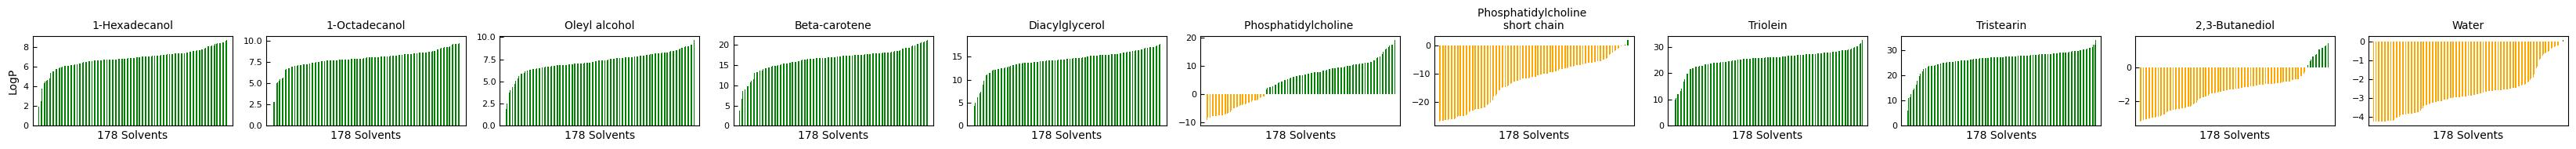

In [5]:
## If we only plot Molecule at T
dG_names = [ col for col in df_solvent_merged.columns if 'dG_' in col ] # and if_contain_keys(col) 
y_names = [ header_to_name[ m[3:6] ] for m in dG_names ]
Temp_C = 25

x = np.arange(len(df_solvent_merged))

fig, axs = plt.subplots(1,len(dG_names),figsize=(3*len(dG_names),2), tight_layout=True, dpi=100)

for n,dg in enumerate(dG_names):
    df = df_solvent_merged.sort_values(dg, ascending=False) #.reset_index(drop=True)
    y = df[dg]
    y = -y/(2.303*1.987*0.001*(273.15+Temp_C))

    m = df.index #['Solvent Name']
    idx_water = np.where(m=='WATER')[0][0]
    colors = np.array(['gray' if i==idx_water else 
                       'orange' if  i<idx_water else
                       'g' for i in range(len(x))])
    
    axs[n].bar(x,y, color=colors, width=0.5)  

    axs[n].set_title( f'{y_names[n]}', fontsize=10 )
    axs[n].set_xlabel('178 Solvents',fontsize=10) ## input X name
    #axs[n].set_ylabel('LogP', fontsize=10) ## input Y name
    axs[n].tick_params(direction='in',labelsize='8')
    #axs.plot([-100,1000], [y[idx_water] ,y[idx_water] ], '--', color='gray', lw=1)
    xlim = [ np.amin(x)-5, np.amax(x)+5 ]
    axs[n].set_xlim(xlim)
    #axs[n].set_ylim([0,10.5])
    axs[n].set_xticks([])

    #print(n, dg)
    #display( y[m == '1-OCTANOL'] )

#axs[-1].set_xlabel('178 Solvents',fontsize=10) ## input X name  
axs[0].set_ylabel('LogP', fontsize=10) ## input Y name
#axs[0].plot( df_solvent_merged['dG_c16(kcal/mol)'] , df_solvent_merged['dG_d18(kcal/mol)'], color='r', marker='o', ls=' ', lw='2', markerfacecolor='none', markeredgecolor='r', markersize=6, ) 
#axs[1].plot( df_solvent_merged['dG_c16(kcal/mol)'] , df_solvent_merged['dG_o18(kcal/mol)'], color='r', marker='o', ls=' ', lw='2', markerfacecolor='none', markeredgecolor='r', markersize=6, ) 
#axs[2].plot( df_solvent_merged['dG_d18(kcal/mol)'] , df_solvent_merged['dG_o18(kcal/mol)'], color='r', marker='o', ls=' ', lw='2', markerfacecolor='none', markeredgecolor='r', markersize=6, ) 

#plt.savefig('logP_SimpleOnly.png', dpi=800)
plt.show()

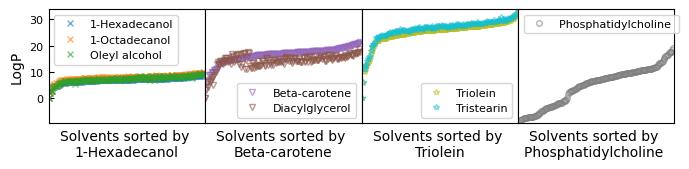

In [8]:
key1 = ['c16', 'd18', 'o18']
key2 = ['bcr', 'dcg']
key4 = ['pcc' ]
key3 = ['tro', 'trs']
keys_array = [ key1, key2, key3, key4 ]

markers = ['x','v','*','o']
legend_loc = ['upper left', 'lower right', 'lower right', 'upper left' ]

cmap = mpl.colormaps['tab10']
colors_rgba = cmap(np.linspace(0, 1, len(gloabel_plot_keys)))
colors_rgba = {i:c for i,c in zip(gloabel_plot_keys,colors_rgba) }

x = np.arange(len(df_solvent_merged))

fig, axs = plt.subplots(1,4, figsize=(7,1.8), tight_layout=True, dpi=100, gridspec_kw={'wspace': 0})

y_lim = [1e9,-1e9]
x_lim = [-0.5, len(x)+0.5 ]
for n,keys in enumerate(keys_array):
    marker = markers[n]
    dG_names = [ col for col in df_solvent_merged.columns if if_contain_keys(col,key_list=keys) ]
    colors =  [ colors_rgba[ m[3:6] ] for m in dG_names ]
    y_names = [ header_to_name[ m[3:6] ] for m in dG_names ]

    df = df_solvent_merged.sort_values(dG_names[0], ascending=False) #.reset_index(drop=True)
    x_label = 'Solvents sorted by \n'+ y_names[0]

    #id_row, id_col = int(n/2), n%2
    ax = axs[n] #[id_row][id_col]
    for i,dg in enumerate(dG_names):
        y = df[dg]
        y = -y/(2.303*1.987*0.001*(273.15+25))

        b = y_names[i]#.replace( 'Phosphatidylcholine', 'Phospha-\n tidylcholine')
        ax.plot(x, y, color=colors[i], lw=2, ls='', marker=marker, ms=4, markerfacecolor='None', markeredgecolor=colors[i], alpha=0.6, label=b )
        #display(dg,y)

        y_lim[0] = np.min( ( -0.5, y_lim[0], min(y) ) )
        y_lim[1] = np.max( ( y_lim[1], max(y) ) )
    
    ax.set_xlabel(x_label,fontsize=10) ## input X name
    ax.tick_params(direction='in',labelsize='8')
    ax.set_xticks([])
    ax.legend(fontsize=8, loc=legend_loc[n], ncol=1, )#bbox_to_anchor=(1.01, 0.94), title='UF$_4$%', handlelength=2, title_fontsize=9 )

#for i in range(2):
#    for j in range(2):
#        ax = axs[i][j]
for n in range(4):
    ax = axs[n]
    ax.set_xlim( x_lim )
    ax.set_ylim( y_lim )
    #if j>0:
    if n >0:
        ax.tick_params(left=False, labelleft=False)
    else:
        ax.set_ylabel('LogP', fontsize=10) ## input Y name

plt.savefig('logP_SimpleOnly.png', dpi=800)
plt.show()

logP from  dG_d18(kcal/mol) vs dG_c16(kcal/mol) 0.9949758602310932 0.9955776571317966 1.0094386069769081
logP from  dG_o18(kcal/mol) vs dG_c16(kcal/mol) 0.9791568092223693 0.41858476194684757 0.4855455564552766
logP from  dG_o18(kcal/mol) vs dG_d18(kcal/mol) 0.9733670705173401 0.6126706448020752 0.6780058511851162
logP from  dG_bcr(kcal/mol) vs dG_c16(kcal/mol) 0.762727223309653 9.562761524677969 9.84167059648555
logP from  dG_bcr(kcal/mol) vs dG_d18(kcal/mol) 0.7917471946856633 8.567183867546172 8.850062448390771
logP from  dG_bcr(kcal/mol) vs dG_o18(kcal/mol) 0.7580485912813841 9.174350388972499 9.449816166287818
logP from  dG_dcg(kcal/mol) vs dG_c16(kcal/mol) 0.9715244605050166 7.221728206428165 7.393006055303257
logP from  dG_dcg(kcal/mol) vs dG_d18(kcal/mol) 0.967691850943641 6.226150549296367 6.401701222472472
logP from  dG_dcg(kcal/mol) vs dG_o18(kcal/mol) 0.960605101734457 6.833317070722694 6.991451744372319
logP from  dG_dcg(kcal/mol) vs dG_bcr(kcal/mol) 0.8312386054267016 2.6

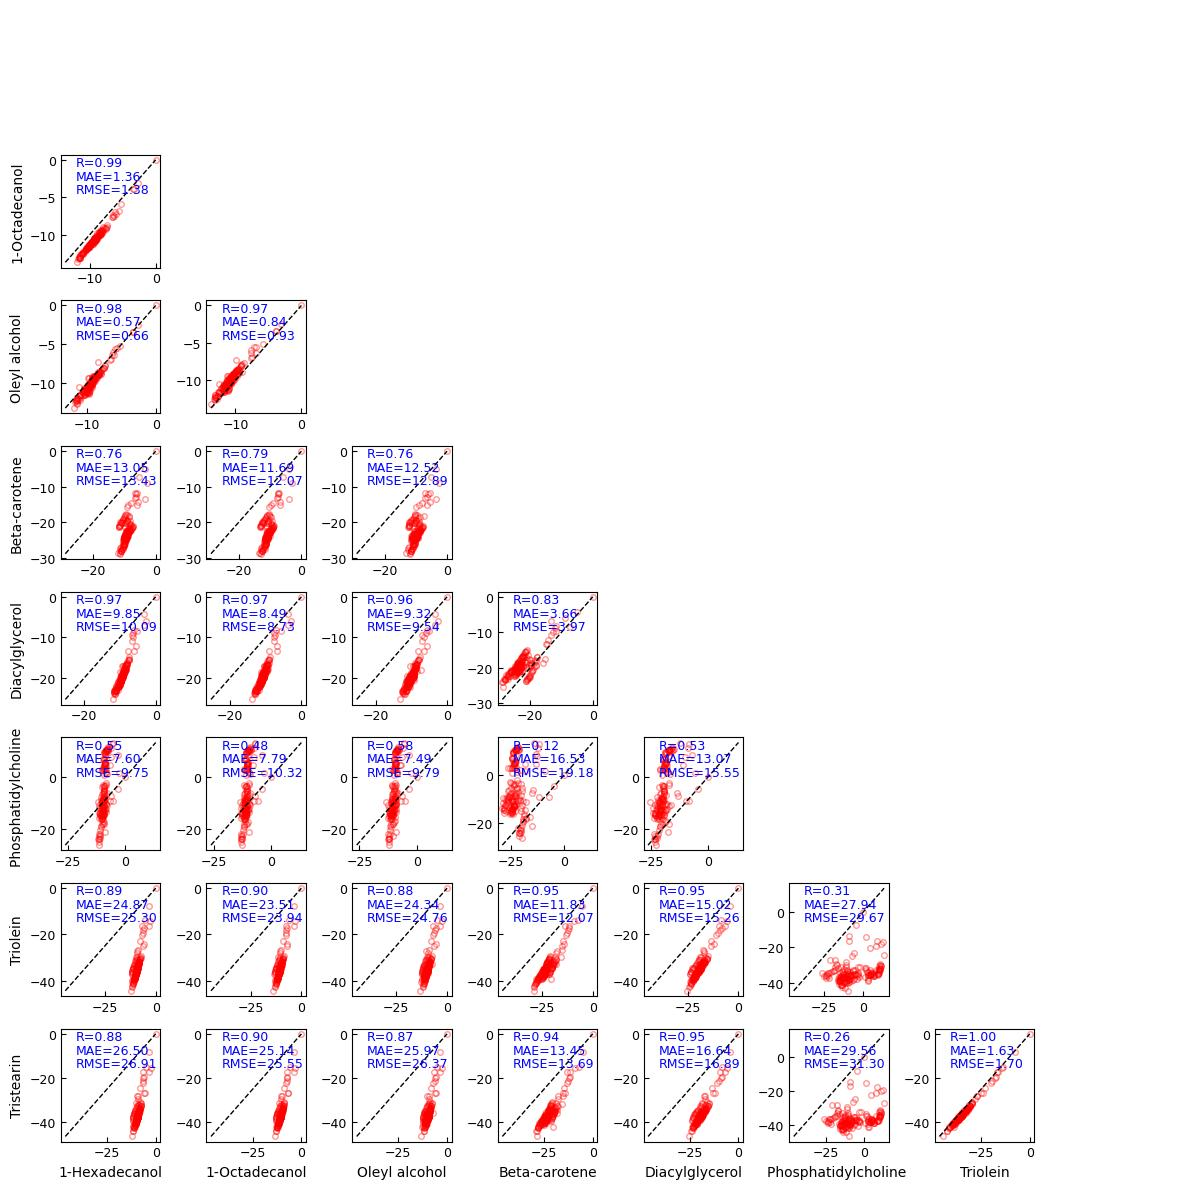

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import itertools

cols = [ col for col in df_solvent_merged.columns if 'dG_' in col and if_contain_keys(col) ]
n = len(cols)

labels = [c.replace('dG_', '').replace('(kcal/mol)', '') for c in cols]
labels = [ header_to_name[b] for b in labels ]

fig, axs = plt.subplots(n, n, figsize=(12,12), dpi=100, tight_layout=True)

comparison_pairs = {}
for i in range(n):
    for j in range(n):
        ax = axs[i, j]
        if j >= i:
            # upper triangle + diagonal: hide (or use diagonal for histograms if you want)
            ax.axis('off')
            continue

        x = df_solvent_merged[cols[j]]
        y = df_solvent_merged[cols[i]]

        ax.plot(x, y, color='r', lw=2, ls='', marker='o', ms=4, markerfacecolor='None', markeredgecolor='r', alpha=0.4)
        ax_min, ax_max = np.min((x, y)), np.max((x, y))
        ax.plot([ax_min, ax_max], [ax_min, ax_max], color='k', lw=1, ls='--')

        # Pearson correlation coefficient
        r = np.corrcoef(x, y)[0, 1]
        mae = np.mean(np.abs(x - y))
        rmse = np.sqrt(np.mean((x - y) ** 2))

        ax.text(0.15, 0.90, f'R={r:.2f}', transform=ax.transAxes, fontsize=9, color='b')
        ax.text(0.15, 0.78, f'MAE={mae:.2f}', transform=ax.transAxes, fontsize=9, color='b')
        ax.text(0.15, 0.66, f'RMSE={rmse:.2f}', transform=ax.transAxes, fontsize=9, color='b')
        #print( cols[i], 'vs', cols[j], r, mae, rmse )

        ax.tick_params(direction='in', labelsize=9)
        # Only label outer axes to avoid clutter
        if i == n - 1:
            ax.set_xlabel(labels[j], fontsize=10)
        if j == 0:
            ax.set_ylabel(labels[i], fontsize=10)

        # For logP
        x = -x/(2.303*1.987*0.001*(273.15+25))
        y = -y/(2.303*1.987*0.001*(273.15+25))
        r = np.corrcoef(x, y)[0, 1]
        mae = np.mean(np.abs(x - y))
        rmse = np.sqrt(np.mean((x - y) ** 2))
        print( 'logP from ', cols[i], 'vs', cols[j], r, mae, rmse )
        comparison_pairs[ cols[i]+'_vs_'+cols[j] ] = [r, rmse]

plt.savefig('Compare_dG_pairwise.png', dpi=400)
plt.show()

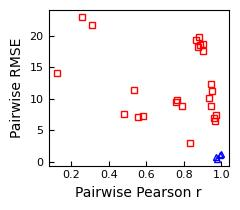

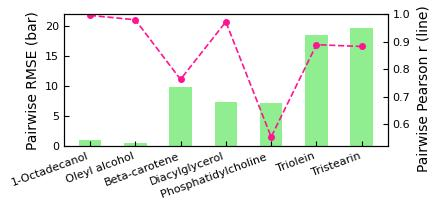

In [16]:
highligh_pairs = []

fig, axs = plt.subplots(1,1, figsize=(2.5, 2.2), dpi=100, tight_layout=True)
for k,v in comparison_pairs.items():
    x, y = v[0],v[1]
    if 'dG_c16' in k:
        highligh_pairs.append(k)

    if x>0.95 and y<2:
        color, marker = 'b','^'
    else:
        color, marker = 'r','s'
    axs.plot(x, y, color=color, lw=2, ls='', marker=marker, ms=5, markerfacecolor='None', markeredgecolor=color, alpha=0.99)

axs.set_ylabel('Pairwise RMSE',fontsize=10) 
axs.set_xlabel('Pairwise Pearson r',fontsize=10) 
axs.tick_params(direction='in',labelsize='8')
plt.savefig('Compare_logP_pairwise_summary.png', dpi=800)
plt.show()


fig, axs = plt.subplots(1,1, figsize=(4.5,2.2), dpi=100, tight_layout=True)

data = np.transpose([ comparison_pairs[p] for p in highligh_pairs ])

bar_labels = [ header_to_name[ p.split('_vs_')[0][3:6] ] for p in highligh_pairs ] 
x_pos = np.arange( len(bar_labels) )
axs.bar(bar_labels, data[1], color='lightgreen', width=0.5)  

ax2 = axs.twinx()
ax2.plot(x_pos, data[0], color='deeppink', lw=1.2, ls='--', marker='o', ms=4, )#markerfacecolor='None', markeredgecolor='m', alpha=0.8)

axs.tick_params(direction='in',labelsize='8')
ax2.tick_params(direction='in',labelsize='8')
axs.set_xticks(x_pos)
axs.set_xticklabels(bar_labels, rotation=20, ha='right', fontsize=8)

axs.set_ylim( (0,22) )
ax2.set_ylim( (0.52,1) )
axs.set_ylabel('Pairwise RMSE (bar)',fontsize=10) 
ax2.set_ylabel('Pairwise Pearson r (line)    ',fontsize=10) 
plt.savefig('Compare_logP_pairwise_highlight.png', dpi=800)
plt.show()


# Known experimental result

In [ ]:
""" 
For a non-ionizable compound like cetyl alcohol, which remains neutral regardless of pH, the partition coefficient (log P) is equal to the distribution coefficient (log D)

1-hexadecanol
c16 - XLogP3 = 7.3, https://pubchem.ncbi.nlm.nih.gov/compound/Cetyl-Alcohol#section=Depositor-Supplied-Synonyms
Partition coefficient log Pow: 6.73 at 25°C/77°F: https://atomscientific.com/product/cetyl-alcohol#:~:text=Initial%20boiling%20point%20and%20range,HS%20Code%20/%20Commodity%20Code:%2034049090
[?] Exp logP 7.21: https://doi.org/10.1556/JPC.23.2010.3.6

1-OCTADECANOL
Octadecan-1-ol
d18 - XLogP3 = 8.4, https://pubchem.ncbi.nlm.nih.gov/compound/8221#section=Depositor-Supplied-Synonyms

OLEYL ALCOHOL
o18 - XLogP3 = 7.4, https://pubchem.ncbi.nlm.nih.gov/compound/5284499

"""

# 2. Data and feature preparation 

In [7]:
%%capture --no-display

# If needed
df = df_solvent_merged.copy() #.rename(columns={"deltaG_bdo": "deltaG_monomer"})

from rdkit.ML.Descriptors import MoleculeDescriptors

fp_names_prop = [ n[0] for n in Descriptors._descList if not n[0].startswith('fr_')]
fp_names_prop.remove('Ipc')  ## https://github.com/rdkit/rdkit/issues/1527
print( len(fp_names_prop) )

calc = MoleculeDescriptors.MolecularDescriptorCalculator(fp_names_prop)

fp_data = []
for smi in df['SMILES']:
    try:
        fp = calc.CalcDescriptors( Chem.MolFromSmiles(smi) )
        fp_data.append( list(fp) )
    except:
        print(smi, 'has problem')

df_features_prop = pd.DataFrame(fp_data, columns=fp_names_prop, index=df.index)
#df_WatSol_features_prop.to_csv('df_WatSol_features_prop.csv')
#X_features_prop = X_features_prop.dropna(axis='columns')
df_features_prop

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,NumSpiroAtoms,NumUnspecifiedAtomStereoCenters,Phi,RingCount,MolLogP,MolMR
Solvent Name,,,,,,,,,,,,,,,,,,,,,
DIIODOMETHANE,2.275000,2.275000,1.190000,1.190000,0.463980,6.000,267.835,265.819,267.824596,20,...,0,0,0,0,0,0,5.143867,0,1.8139,32.9070
CIS-DECALIN,1.560185,1.560185,1.155093,1.155093,0.481193,40.800,138.254,120.110,138.140851,58,...,0,2,0,2,0,0,1.967279,2,3.3668,43.9160
N-HEXADECANE,2.290220,2.290220,1.372778,1.372778,0.314905,10.875,226.448,192.176,226.266051,98,...,13,0,0,0,0,0,15.000000,0,6.4876,75.9860
N-PENTADECANE,2.287998,2.287998,1.372449,1.372449,0.342950,10.800,212.421,180.165,212.250401,92,...,12,0,0,0,0,0,14.000000,0,6.0975,71.3690
DECALIN,1.560185,1.560185,1.155093,1.155093,0.481193,40.800,138.254,120.110,138.140851,58,...,0,2,0,2,0,0,1.967279,2,3.3668,43.9160
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2-METHYL-1-PROPANOL,8.143519,8.143519,0.305556,0.305556,0.483480,9.600,74.123,64.043,74.073165,32,...,1,0,0,0,0,0,2.194825,0,0.6347,21.9238
2-PROPANOL,8.055556,8.055556,0.166667,-0.166667,0.428405,9.000,60.096,52.032,60.057515,26,...,0,0,0,0,0,0,1.284859,0,0.3871,17.3548
1-PROPANOL,7.875000,7.875000,0.319444,0.319444,0.463784,7.500,60.096,52.032,60.057515,26,...,1,0,0,0,0,0,2.930400,0,0.3887,17.3768


In [8]:
%%capture --no-display

good_elements = ['C','H','O','N',]#'S']#,'P']
mask_element = []   ## molecules to keep, keep=True
for smi in df['SMILES']:
    mol = Chem.MolFromSmiles( smi )
    element = set([at.GetSymbol() for at in mol.GetAtoms()])  ## GetSymbol , GetAtomicNum
    if all(e in good_elements for e in element):
        mask_element.append(True)
    else:
        mask_element.append(False)

solvation_data = df[mask_element]
#df_watsol = df_watsol.reset_index(drop=True)
df_features_prop = df_features_prop[mask_element]

display( df_features_prop, solvation_data )

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,NumSpiroAtoms,NumUnspecifiedAtomStereoCenters,Phi,RingCount,MolLogP,MolMR
Solvent Name,,,,,,,,,,,,,,,,,,,,,
CIS-DECALIN,1.560185,1.560185,1.155093,1.155093,0.481193,40.800,138.254,120.110,138.140851,58,...,0,2,0,2,0,0,1.967279,2,3.3668,43.9160
N-HEXADECANE,2.290220,2.290220,1.372778,1.372778,0.314905,10.875,226.448,192.176,226.266051,98,...,13,0,0,0,0,0,15.000000,0,6.4876,75.9860
N-PENTADECANE,2.287998,2.287998,1.372449,1.372449,0.342950,10.800,212.421,180.165,212.250401,92,...,12,0,0,0,0,0,14.000000,0,6.0975,71.3690
DECALIN,1.560185,1.560185,1.155093,1.155093,0.481193,40.800,138.254,120.110,138.140851,58,...,0,2,0,2,0,0,1.967279,2,3.3668,43.9160
N-DODECANE,2.279016,2.279016,1.370868,1.370868,0.430464,10.500,170.340,144.132,170.203451,74,...,9,0,0,0,0,0,11.000000,0,4.9272,57.5180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2-METHYL-1-PROPANOL,8.143519,8.143519,0.305556,0.305556,0.483480,9.600,74.123,64.043,74.073165,32,...,1,0,0,0,0,0,2.194825,0,0.6347,21.9238
2-PROPANOL,8.055556,8.055556,0.166667,-0.166667,0.428405,9.000,60.096,52.032,60.057515,26,...,0,0,0,0,0,0,1.284859,0,0.3871,17.3548
1-PROPANOL,7.875000,7.875000,0.319444,0.319444,0.463784,7.500,60.096,52.032,60.057515,26,...,1,0,0,0,0,0,2.930400,0,0.3887,17.3768


,SMILES,Solvent Inchi,dG_c16(kcal/mol),dG_d18(kcal/mol),dG_o18(kcal/mol),dG_bcr(kcal/mol),dG_dcg(kcal/mol),dG_pcc(kcal/mol),dG_pcs(kcal/mol),dG_tro(kcal/mol),dG_trs(kcal/mol),dG_bdo(kcal/mol),dG_wat(kcal/mol)
Solvent Name,,,,,,,,,,,,,
CIS-DECALIN,C1CCC2CCCCC2C1,InChI=1S/C10H18/c1-2-6-10-8-4-3-7-9(10)5-1/h9-...,-7.398795,-8.730589,-7.653815,-21.086064,-14.884521,10.668876,34.355792,-29.464011,-31.256869,4.271077,5.743013
N-HEXADECANE,CCCCCCCCCCCCCCCC,InChI=1S/C16H34/c1-3-5-7-9-11-13-15-16-14-12-1...,-7.677937,-9.167254,-8.006268,-21.516200,-15.547273,11.358207,35.877781,-30.474694,-32.443510,4.251875,5.815026
N-PENTADECANE,CCCCCCCCCCCCCCC,InChI=1S/C15H32/c1-3-5-7-9-11-13-15-14-12-10-8...,-7.586496,-9.221653,-8.039168,-21.603576,-15.660476,11.285619,35.907704,-30.642798,-32.623452,4.236062,5.812930
DECALIN,C1CCC2CCCCC2C1,InChI=1S/C10H18/c1-2-6-10-8-4-3-7-9(10)5-1/h9-...,-7.367834,-8.943202,-7.843354,-21.386239,-15.265404,10.354026,34.376695,-30.030382,-31.856118,4.214727,5.731278
N-DODECANE,CCCCCCCCCCCC,InChI=1S/C12H26/c1-3-5-7-9-11-12-10-8-6-4-2/h3...,-8.021134,-9.522775,-8.380471,-22.026256,-16.201210,10.890578,36.000852,-31.448621,-33.481040,4.159443,5.800304
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2-METHYL-1-PROPANOL,CC(C)CO,"InChI=1S/C4H10O/c1-4(2)3-5/h4-5H,3H2,1-2H3",-11.648657,-13.039261,-12.230646,-21.124441,-23.292579,-23.764192,0.190253,-36.208227,-37.833736,-1.708895,0.321554
2-PROPANOL,CC(C)O,"InChI=1S/C3H8O/c1-3(2)4/h3-4H,1-2H3",-11.785736,-13.256033,-12.441420,-21.391541,-23.770065,-23.977015,-0.246278,-37.051997,-38.826980,-1.755833,0.321705
1-PROPANOL,CCCO,"InChI=1S/C3H8O/c1-2-3-4/h4H,2-3H2,1H3",-11.464696,-12.888062,-12.193949,-20.788446,-22.959329,-24.033361,-0.587601,-35.618125,-37.181364,-1.790283,0.236922


In [9]:
## Remove data column with std=0
def clean_std(df):
    print('Before clean', df.shape )
    #X_features.loc[ :, X_features.std() > X_features.mean() ]
    df_new = df.loc[ :, df.std()>0 ]
    print('After clean', df_new.shape )
    return df_new


numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
df_features_prop = df_features_prop.copy().select_dtypes(include=numerics)

df_features_prop = clean_std( df_features_prop )
df_features_prop

Before clean (130, 131)
After clean (130, 121)


,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,NumHeterocycles,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,NumUnspecifiedAtomStereoCenters,Phi,RingCount,MolLogP,MolMR
Solvent Name,,,,,,,,,,,,,,,,,,,,,
CIS-DECALIN,1.560185,1.560185,1.155093,1.155093,0.481193,40.800,138.254,120.110,138.140851,58,...,0,0,2,0,2,0,1.967279,2,3.3668,43.9160
N-HEXADECANE,2.290220,2.290220,1.372778,1.372778,0.314905,10.875,226.448,192.176,226.266051,98,...,0,13,0,0,0,0,15.000000,0,6.4876,75.9860
N-PENTADECANE,2.287998,2.287998,1.372449,1.372449,0.342950,10.800,212.421,180.165,212.250401,92,...,0,12,0,0,0,0,14.000000,0,6.0975,71.3690
DECALIN,1.560185,1.560185,1.155093,1.155093,0.481193,40.800,138.254,120.110,138.140851,58,...,0,0,2,0,2,0,1.967279,2,3.3668,43.9160
N-DODECANE,2.279016,2.279016,1.370868,1.370868,0.430464,10.500,170.340,144.132,170.203451,74,...,0,9,0,0,0,0,11.000000,0,4.9272,57.5180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2-METHYL-1-PROPANOL,8.143519,8.143519,0.305556,0.305556,0.483480,9.600,74.123,64.043,74.073165,32,...,0,1,0,0,0,0,2.194825,0,0.6347,21.9238
2-PROPANOL,8.055556,8.055556,0.166667,-0.166667,0.428405,9.000,60.096,52.032,60.057515,26,...,0,0,0,0,0,0,1.284859,0,0.3871,17.3548
1-PROPANOL,7.875000,7.875000,0.319444,0.319444,0.463784,7.500,60.096,52.032,60.057515,26,...,0,1,0,0,0,0,2.930400,0,0.3887,17.3768


In [10]:
df_features_prop.to_csv(f"data_X.csv", index=True)
solvation_data.to_csv(f"data_Y.csv", index=True)

In [ ]:
# For solute molecules
# Convert header to molecule name
header_to_SMILES={'c16':'CCCCCCCCCCCCCCCCO',
                  'd18':'CCCCCCCCCCCCCCCCCCO',
                  'o18':"CCCCCCCC/C=C\CCCCCCCCO",
                  'bcr':'CC1=C(C(CCC1)(C)C)/C=C/C(=C/C=C/C(=C/C=C/C=C(/C=C/C=C(/C=C/C2=C(CCCC2(C)C)C)\C)\C)/C)/C',
                  'dcg':'CCCCCCCCCCCCCC(=O)OC[C@H](CO)OC(=O)CCCCCCC/C=C\CCCC',
                  'pcc':'Phosphotidylcholine \nC18 C18:1',
                  'pcs':'Phosphotidylcholine \nshort chain',
                  'tro':'CCCCCCCC/C=C\CCCCCCCC(=O)OCC(OC(=O)CCCCCCC/C=C\CCCCCCCC)COC(=O)CCCCCCC/C=C\CCCCCCCC',
                  'trs':'CCCCCCCCCCCCCCCCCC(=O)OCC(COC(=O)CCCCCCCCCCCCCCCCC)OC(=O)CCCCCCCCCCCCCCCCC',
                  'bdo':'CC(C(C)O)O',
                  'wat':'O'
                 }


# 3. Feature analysis

In [4]:
class PCAInfo:
    """Fitted PCA pipeline for descriptor data, storing everything needed to
    re-apply the identical transform to new molecules later.

    Attributes
    ----------
    features   : descriptor names kept (after variance / correlation filtering),
                 in the exact order the scaler and PCA expect
    scaler     : fitted StandardScaler (essential -- RDKit descriptors span
                 wildly different magnitudes, and unscaled PCA would be
                 dominated by whichever descriptors happen to have big units)
    pca        : fitted PCA object; pca.components_ holds the loadings
    loadings   : DataFrame (n_components x n_features) of PCA coefficients
    evr        : explained variance ratio per component
    n_for      : dict {threshold: n_components needed}
    """
    def __init__(self, features, scaler, pca, dropped_zero_var, dropped_corr, corr_threshold):
        self.features = list(features)
        self.scaler = scaler
        self.pca = pca
        self.dropped_zero_var = list(dropped_zero_var)
        self.dropped_corr = list(dropped_corr)
        self.corr_threshold = corr_threshold
        self.evr = pca.explained_variance_ratio_
        self.cumulative = np.cumsum(self.evr)
        self.loadings = pd.DataFrame(
            pca.components_,
            index=[f'PC{i+1}' for i in range(pca.components_.shape[0])],
            columns=self.features)
        self.n_for = {t: int(np.searchsorted(self.cumulative, t) + 1)
                      for t in (0.80, 0.90, 0.95, 0.99)
                      if self.cumulative[-1] >= t}

    def transform(self, new_X, n_components=None):
        """Apply the stored filter -> scale -> PCA transform to new data.
        Reindexes by NAME, so column order in new_X does not matter."""
        missing = [c for c in self.features if c not in new_X.columns]
        if missing:
            raise ValueError(f"new data is missing {len(missing)} required descriptors, "
                             f"e.g. {missing[:5]}")
        Z = self.pca.transform(self.scaler.transform(new_X[self.features].values))
        return Z if n_components is None else Z[:, :n_components]

    def top_loadings(self, component=1, n=10):
        """Descriptors contributing most to a given PC (by |loading|)."""
        row = self.loadings.loc[f'PC{component}']
        return row.reindex(row.abs().sort_values(ascending=False).index).head(n)

    def save(self, path):
        joblib.dump(self, path)

    @classmethod
    def load(cls, path):
        return joblib.load(path)


def fit_pca(data_X, corr_threshold=0.95, n_components=None, variance_targets=(0.80, 0.90, 0.95, 0.99),
            n_bars=5, plot=True, figsize=(3.5,2.5), dpi=110, verbose=True):
    """
    Fit PCA on a descriptor matrix with sensible pre-processing.

    corr_threshold : drop one of each |r| >= threshold pair before PCA.
                     Set to None to skip. PCA already decorrelates, so this is
                     optional -- it mainly reduces size and improves conditioning.
    n_components   : None keeps min(n_samples, n_features) components.
    """
    X = data_X.select_dtypes(include=[np.number]).copy()
    n0 = X.shape[1]

    # 1. drop zero-variance columns (StandardScaler would divide by zero)
    zv = X.columns[X.std(ddof=0) == 0].tolist()
    X = X.drop(columns=zv)

    # 2. optional pairwise correlation pruning
    dropped_corr = []
    if corr_threshold is not None:
        corr = X.corr().abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        dropped_corr = [c for c in upper.columns if (upper[c] >= corr_threshold).any()]
        X = X.drop(columns=dropped_corr)

    # 3. scale, then PCA
    scaler = StandardScaler().fit(X.values)
    Xs = scaler.transform(X.values)
    pca = PCA(n_components=n_components, random_state=42).fit(Xs)

    info = PCAInfo(X.columns, scaler, pca, zv, dropped_corr, corr_threshold)

    if verbose:
        print(f"descriptors: {n0} -> {len(zv)} zero-variance dropped "
              f"-> {len(dropped_corr)} correlated dropped (|r|>={corr_threshold}) "
              f"-> {X.shape[1]} kept")
        print(f"PCA fitted on {Xs.shape[0]} samples x {Xs.shape[1]} descriptors "
              f"-> {pca.n_components_} components")
        for t in variance_targets:
            if info.cumulative[-1] >= t:
                print(f"  {t:.0%} variance needs {int(np.searchsorted(info.cumulative, t)+1):3d} components")
            else:
                print(f"  {t:.0%} variance NOT reached (max {info.cumulative[-1]:.1%})")

    if plot:
        _plot(info, variance_targets, n_bars, figsize, dpi)
    return info


def _plot(info, variance_targets, n_bars, figsize, dpi):
    evr, cum = info.evr, info.cumulative
    #n_line = min(len(evr), max(n_bars * 6, 30))
    n_line = min(len(evr), n_bars)
    x = np.arange(1, n_line + 1)

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    ax.bar(np.arange(1, min(n_bars, len(evr)) + 1), evr[:n_bars],
           color='steelblue', width=0.65, label=f'Individual \nvariance \n(top {n_bars} PCs)')
    #for i, v in enumerate(evr[:n_bars]):
    #    ax.text(i + 1, v + 0.01, f'{v:.1%}', ha='center', fontsize=7)

    ax2 = ax.twinx()
    ax2.plot(x, cum[:n_line], color='darkorange', lw=1., marker='o', ms=3,
             label='Cumulative \nvariance')
    for t in variance_targets:
        if cum[-1] >= t:
            nc = int(np.searchsorted(cum, t) + 1)
            #ax2.axhline(t, color='grey', ls=':', lw=0.8)
            #if nc <= n_line:
            #    ax2.annotate(f'{t:.0%} @ PC{nc}', xy=(nc, t), fontsize=7,
            #                 xytext=(3, -9), textcoords='offset points', color='grey')

    ax.set_xlabel('Principal component', fontsize=10)
    ax.set_ylabel('Individual \nexplained variance', fontsize=10, color='k') 
    ax2.set_ylabel('Cumulative \nexplained variance', fontsize=10, color='k') #
    ax.tick_params(axis='y', labelcolor='k', labelsize=8, direction='in')
    ax2.tick_params(axis='y', labelcolor='k', labelsize=8, direction='in')
    ax.tick_params(axis='x', labelsize=8)
    ax.set_xlim(0.3, n_line + 0.7)
    ax2.set_ylim(0, 1.0)
    h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=8, frameon=False, loc='center right')
    plt.tight_layout()
        
    plt.savefig(f'PAC_cumulative_var.png', dpi=400)
    plt.show()


descriptors: 121 -> 0 zero-variance dropped -> 29 correlated dropped (|r|>=0.95) -> 92 kept
PCA fitted on 130 samples x 92 descriptors -> 92 components
  80% variance needs  14 components
  90% variance needs  21 components
  95% variance needs  27 components
  99% variance needs  39 components


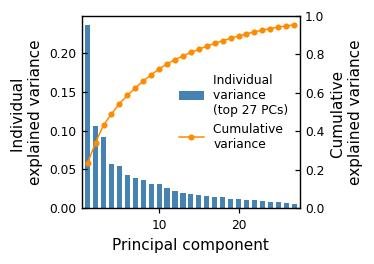

In [5]:
data_Y = pd.read_csv('data_Y.csv', index_col=0).drop( columns=['SMILES','Solvent Inchi'] )
data_X = pd.read_csv('data_X.csv', index_col=0)
pca_info = fit_pca(data_X, corr_threshold=0.95, n_bars=27)

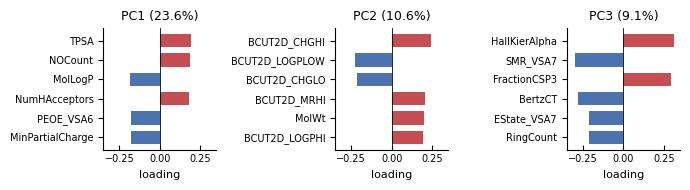

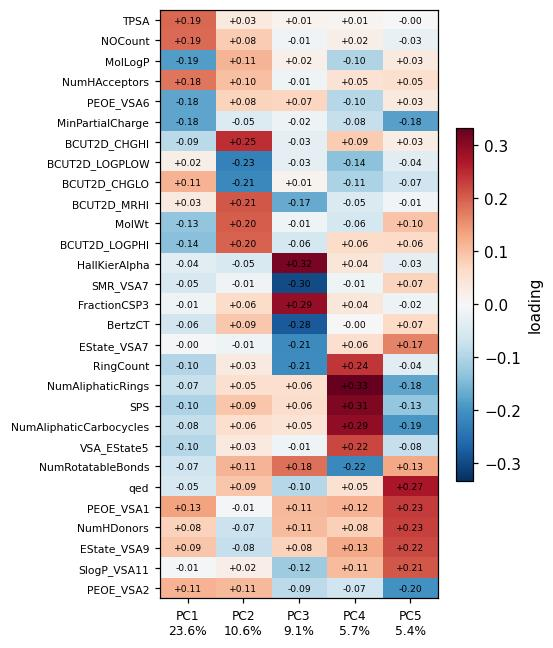

In [6]:
def plot_pc_loadings(pca_info, n_pc=5, n_top=8, figsize=None, dpi=100, savepath=None):
    """One panel per PC: signed top-|loading| descriptors as horizontal bars.
    Sign matters -- opposite signs sit at opposite ends of that axis."""
    figsize = figsize or (2.1*n_pc, 0.32*n_top + 1.2)
    fig, axs = plt.subplots(1, n_pc, figsize=figsize, dpi=dpi, tight_layout=True)
    axs = np.atleast_1d(axs)
    for i in range(n_pc):
        row = pca_info.loadings.loc[f'PC{i+1}']
        top = row.reindex(row.abs().sort_values(ascending=False).index).head(n_top)[::-1]
        colors = ['#c44e52' if v > 0 else '#4c72b0' for v in top.values]
        axs[i].barh(range(len(top)), top.values, color=colors, height=0.7)
        axs[i].set_yticks(range(len(top)))
        axs[i].set_yticklabels(top.index, fontsize=7)
        axs[i].axvline(0, color='k', lw=0.6)
        axs[i].set_title(f'PC{i+1} ({pca_info.evr[i]:.1%})', fontsize=9)
        axs[i].tick_params(axis='x', labelsize=7, direction='in')
        axs[i].set_xlabel('loading', fontsize=8)
        #m = np.abs(top.values).max()*1.25
        m = 0.35
        axs[i].set_xlim(-m, m)
        for s in ['top','right']:
            axs[i].spines[s].set_visible(False)
    if savepath:
        plt.savefig(savepath, dpi=400, bbox_inches='tight')
    plt.show()

def plot_loading_heatmap(pca_info, n_pc=5, n_top=6, figsize=(5,6), dpi=110, savepath=None):
    """Union of each PC's top descriptors, as a signed heatmap across PCs."""
    keep = []
    for i in range(n_pc):
        row = pca_info.loadings.loc[f'PC{i+1}']
        keep += list(row.abs().sort_values(ascending=False).head(n_top).index)
    keep = list(dict.fromkeys(keep))                  # preserve order, drop repeats
    M = pca_info.loadings.iloc[:n_pc][keep].T

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi, tight_layout=True)
    v = np.abs(M.values).max()
    im = ax.imshow(M.values, cmap='RdBu_r', vmin=-v, vmax=v, aspect='auto')
    ax.set_xticks(range(n_pc))
    ax.set_xticklabels([f'PC{i+1}\n{pca_info.evr[i]:.1%}' for i in range(n_pc)], fontsize=8)
    ax.set_yticks(range(len(keep)))
    ax.set_yticklabels(keep, fontsize=7)
    for i in range(len(keep)):
        for j in range(n_pc):
            ax.text(j, i, f'{M.values[i,j]:+.2f}', ha='center', va='center', fontsize=6)
    plt.colorbar(im, ax=ax, shrink=0.6, label='loading')
    if savepath:
        plt.savefig(savepath, dpi=400, bbox_inches='tight')
    plt.show()


plot_pc_loadings(pca_info, n_pc=3, n_top=6, figsize=(7,2), savepath='pc_loadings.png')
plot_loading_heatmap(pca_info, n_pc=5, n_top=6, )#savepath='pc_loading_heatmap.png')

In [7]:
def project_solvents(pca_info, data_X_raw, n_components=2):
    """Solvent scores on the leading PCs. Reindexes by descriptor NAME, so the
    column order of data_X_raw does not matter."""
    Z = pca_info.transform(data_X_raw, n_components=n_components)
    return pd.DataFrame(Z, index=data_X_raw.index, columns=[f'PC{i+1}' for i in range(n_components)])


def plot_pc_scatter(scores, color=None, cbar_label='', labels=None, highlight=None,
                    background=None, ax=None, cmap='viridis', robust=True,
                    figsize=(3.5,2.5), dpi=110, savepath=None, title=None,
                    evr=None, s=26, tick_fmt='.3g'):
    """
    PC1 vs PC2 scatter.

    color      : Series/array aligned to scores.index (continuous) OR a Series of
                 category labels (strings) -> discrete legend.
    background : another scores frame (e.g. the 7,126-solvent library) drawn as
                 faint grey points underneath, to show domain coverage.
    highlight  : list of index labels to mark with a star and annotate.
    labels     : list of index labels to annotate (no star).
    robust     : clip the colour scale to the 2nd-98th percentile so a few
                 extreme solvents do not flatten the rest of the map. When
                 clipping occurs the end tick labels become "<a" / ">b".
    tick_fmt   : format spec for colourbar tick labels (default 3 sig figs).
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, dpi=dpi, tight_layout=True)

    if background is not None:
        ax.scatter(background['PC1'], background['PC2'], s=6, c='0.85',
                   linewidths=0, zorder=0, label='candidate library')

    cb, cvals = None, None
    if color is None:
        ax.scatter(scores['PC1'], scores['PC2'], s=s, c='steelblue',
                   edgecolor='k', linewidth=0.3, zorder=2)
    elif pd.api.types.is_numeric_dtype(pd.Series(color)):
        cvals = pd.Series(color).reindex(scores.index)
        c = cvals.values
        vmin, vmax = (np.nanpercentile(c, [2, 98]) if robust else (np.nanmin(c), np.nanmax(c)))
        sc = ax.scatter(scores['PC1'], scores['PC2'], c=c, cmap=cmap, s=s,
                        vmin=vmin, vmax=vmax, edgecolor='k', linewidth=0.3, zorder=2)

        # only advertise clipping if values actually fall outside the shown range
        clipped_lo = bool(np.nansum(c < vmin))
        clipped_hi = bool(np.nansum(c > vmax))
        ext = ('both' if (clipped_lo and clipped_hi) else
               'min' if clipped_lo else 'max' if clipped_hi else 'neither')
        cb = plt.colorbar(sc, ax=ax, shrink=0.85, extend=ext)

        # Only rewrite ticks when clipping actually happened; otherwise leave
        # matplotlib's defaults alone. Interior ticks sitting too close to a
        # pinned endpoint are dropped so the labels do not overlap.
        if clipped_lo or clipped_hi:
            rng_ = vmax - vmin
            inner = [t for t in cb.get_ticks()
                     if vmin + 0.08*rng_ < t < vmax - 0.08*rng_]
            ticks = ([vmin] if clipped_lo else []) + inner + ([vmax] if clipped_hi else [])
            lab = [f'{t:{tick_fmt}}' for t in ticks]
            if clipped_lo: lab[0] = f'<{vmin:{tick_fmt}}'
            if clipped_hi: lab[-1] = f'>{vmax:{tick_fmt}}'
            cb.set_ticks(ticks); cb.set_ticklabels(lab)
        cb.set_label(cbar_label, fontsize=9)
        cb.ax.tick_params(labelsize=8)
    else:                                            # categorical
        cats = pd.Series(color).reindex(scores.index)
        for k, grp in scores.groupby(cats):
            ax.scatter(grp['PC1'], grp['PC2'], s=s, label=str(k),
                       edgecolor='k', linewidth=0.3, zorder=2)
        ax.legend(fontsize=7, frameon=False, loc='best')

    if highlight:
        hl = [i for i in highlight if i in scores.index]
        h = scores.loc[hl]
        ax.scatter(h['PC1'], h['PC2'], marker='*', s=120, c='red',
                   edgecolor='k', linewidth=0.5, zorder=4)
        #for nm, r in h.iterrows():
        #    ax.annotate(nm, (r['PC1'], r['PC2']), fontsize=7, zorder=5,
        #                xytext=(5, 4), textcoords='offset points')

        if cb is not None and cvals is not None:
            lo, hi = cb.ax.get_ylim()
            for nm in hl:
                v = cvals.get(nm, np.nan)
                if np.isfinite(v):
                    cb.ax.axhline(np.clip(v, lo, hi), color='red', lw=1.6, zorder=5)
    if labels:
        for nm in labels:
            if nm in scores.index:
                r = scores.loc[nm]
                ax.annotate(nm, (r['PC1'], r['PC2']), fontsize=6,
                            xytext=(4, 3), textcoords='offset points')

    xl = f'PC1 ({evr[0]:.1%})' if evr is not None else 'PC1'
    yl = f'PC2 ({evr[1]:.1%})' if evr is not None else 'PC2'
    ax.set_xlabel(xl, fontsize=10); ax.set_ylabel(yl, fontsize=10)
    ax.tick_params(direction='in', labelsize=8)
    ax.axhline(0, color='0.8', lw=0.6, zorder=1); ax.axvline(0, color='0.8', lw=0.6, zorder=1)
    if title: ax.set_title(title, fontsize=10)
    if savepath: plt.savefig(savepath, dpi=400, bbox_inches='tight')
    return ax

scores = project_solvents(pca_info, data_X, n_components=2)

<Axes: xlabel='PC1 (23.6%)', ylabel='PC2 (10.6%)'>

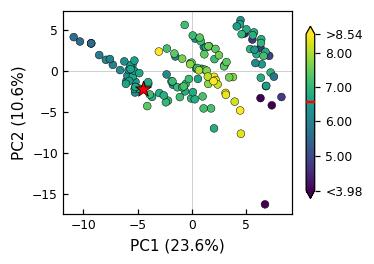

In [8]:
color_logP = -data_Y['dG_c16(kcal/mol)']/(2.303*1.987*0.001*(273.15+25))
color_bar_label = 'logP' #'ΔΔG$_{PC}$ (kcal/mol)'

plot_pc_scatter(scores, color=color_logP, #cbar_label=color_bar_label,
                highlight=['N-HEXANE'], evr=pca_info.evr, tick_fmt='.2f',
                savepath = 'pc_biplot.png'
               )


## Build PCA if need

In [ ]:
def feature_importance(info, n_components=None):
    k = n_components or info.pca.n_components_
    scaled = info.loadings.iloc[:k].T * np.sqrt(info.pca.explained_variance_[:k])
    out = pd.DataFrame({'communality': (scaled ** 2).sum(axis=1),
                        'abs_loading_PC1': info.loadings.loc['PC1'].abs()})
    return out.sort_values('communality', ascending=False)

def compare_importance(info, data_X, y, n_components=None, random_state=42):
    from sklearn.feature_selection import mutual_info_regression
    from scipy.stats import spearmanr
 
    k = n_components or info.pca.n_components_
    scaled = info.loadings.iloc[:k].T * np.sqrt(info.pca.explained_variance_[:k])
    comm = (scaled ** 2).sum(axis=1)
 
    Xf = data_X[info.features]
    mi = pd.Series(mutual_info_regression(Xf.values, np.asarray(y), random_state=random_state),
                   index=info.features)
 
    df = pd.DataFrame({'communality': comm, 'MI_with_target': mi})
    df['rank_communality'] = df['communality'].rank(ascending=False).astype(int)
    df['rank_MI'] = df['MI_with_target'].rank(ascending=False).astype(int)
    rho = spearmanr(df['communality'], df['MI_with_target']).statistic
    print(f"Spearman(communality, MI with target) = {rho:+.3f}")
    print("  near 0 -> PCA-importance and predictive-importance are unrelated for this target")
    return df.sort_values('MI_with_target', ascending=False)

In [6]:
feature_importance(pca_info, n_components=20)     # communality ranking (unsupervised)

data_Y = pd.read_csv('data_Y.csv', index_col=0)
compare_importance(pca_info, data_X, data_Y['dG_c16(kcal/mol)'], n_components=20)   # communality vs MI, side by side

Spearman(communality, MI with target) = +0.644
  near 0 -> PCA-importance and predictive-importance are unrelated for this target


,communality,MI_with_target,rank_communality,rank_MI
TPSA,0.993894,0.632384,4,1
MinPartialCharge,0.964779,0.568931,26,2
BCUT2D_MWHI,0.969040,0.497169,22,3
MaxPartialCharge,0.973124,0.455438,19,4
HallKierAlpha,0.998802,0.438587,1,5
...,...,...,...,...
NumAliphaticHeterocycles,0.766804,0.000000,87,88
PEOE_VSA11,0.747898,0.000000,88,88
NumUnspecifiedAtomStereoCenters,0.803706,0.000000,80,88
qed,0.815312,0.000000,76,88


In [23]:
pca_info.save('pca_info.pkl')

# 4. ML parameter sweep

In [4]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import KFold, RepeatedKFold, GridSearchCV, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression, mutual_info_regression, RFE
from sklearn.linear_model import (
    LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV,
    LassoLars, LassoLarsCV, LassoLarsIC, OrthogonalMatchingPursuit,
    OrthogonalMatchingPursuitCV, LarsCV, BayesianRidge, HuberRegressor,
    SGDRegressor, PassiveAggressiveRegressor, TweedieRegressor, RANSACRegressor
)
from sklearn.svm import LinearSVR, SVR, NuSVR
from sklearn.cross_decomposition import PLSRegression
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic, WhiteKernel, ConstantKernel
from sklearn.neighbors import KNeighborsRegressor
from sklearn.dummy import DummyRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor,
    HistGradientBoostingRegressor, AdaBoostRegressor, BaggingRegressor
)
from sklearn.tree import DecisionTreeRegressor, ExtraTreeRegressor
from sklearn import metrics

try:
    from lightgbm import LGBMRegressor
    _HAS_LGBM = True
except ImportError:
    _HAS_LGBM = False
_HAS_LGBM = False

In [5]:
class CorrelationSelector(BaseEstimator, TransformerMixin):
    def __init__(self, k=25):
        self.k = k
    def fit(self, X, y):
        X = np.asarray(X)
        corr = np.array([abs(np.corrcoef(X[:, i], y)[0, 1]) for i in range(X.shape[1])])
        corr = np.nan_to_num(corr, nan=0.0)
        self.indices_ = np.argsort(corr)[::-1][:self.k]
        return self
    def transform(self, X):
        return np.asarray(X)[:, self.indices_]


class LassoImportanceSelector(BaseEstimator, TransformerMixin):
    def __init__(self, k=25, random_state=42):
        self.k = k
        self.random_state = random_state
    def fit(self, X, y):
        X_scaled = StandardScaler().fit_transform(X)
        lcv = LassoCV(cv=5, random_state=self.random_state, max_iter=20000).fit(X_scaled, y)
        self.indices_ = np.argsort(np.abs(lcv.coef_))[::-1][:self.k]
        return self
    def transform(self, X):
        return np.asarray(X)[:, self.indices_]


class RFImportanceSelector(BaseEstimator, TransformerMixin):
    def __init__(self, k=25, random_state=42):
        self.k = k
        self.random_state = random_state
    def fit(self, X, y):
        rf = RandomForestRegressor(n_estimators=300, max_depth=5,
                                    random_state=self.random_state, n_jobs=-1).fit(X, y)
        self.indices_ = np.argsort(rf.feature_importances_)[::-1][:self.k]
        return self
    def transform(self, X):
        return np.asarray(X)[:, self.indices_]

def build_gpr_kernel_candidates():
    kernel_families = {
        'RBF': lambda ls_b: RBF(length_scale=1.0, length_scale_bounds=ls_b),
        'Matern15': lambda ls_b: Matern(length_scale=1.0, length_scale_bounds=ls_b, nu=1.5),
        'Matern25': lambda ls_b: Matern(length_scale=1.0, length_scale_bounds=ls_b, nu=2.5),
        'RationalQuadratic': lambda ls_b: RationalQuadratic(length_scale=1.0, alpha=1.0),
    }
    bound_presets = {
        #'tight':  {'ls': (0.5, 20),  'noise': (0.5, 10)},
        'medium': {'ls': (0.5, 50),  'noise': (0.3, 10)},
        #'loose':  {'ls': (0.1, 100), 'noise': (0.1, 20)},
    }
    kernels = []
    for kname, kfn in kernel_families.items():
        for bname, b in bound_presets.items():
            base = kfn(b['ls'])
            kernel = ConstantKernel(1.0, (0.1, 100)) * base + WhiteKernel(max(0.5, b['noise'][0]), b['noise'])
            kernels.append(kernel)
    return kernels
    
def _tune(estimator, param_grid, cv_inner=3):
    if not param_grid:
        return estimator
    return GridSearchCV(estimator, param_grid, scoring='neg_mean_absolute_error',
                         cv=cv_inner, n_jobs=-1)


class SolventModelScreener:
    """
    Utility class for small-N solvent-descriptor -> property regression
    Typical workflow:
        screener = SolventModelScreener(n_features_target=25, random_state=42)
        screener.load_data(df_features_prop, solvation_data['dG_c16'])
        screener.clean_features(corr_threshold=0.9)
        results_df = screener.run_full_screen()
        screener.summarize(top_n=15, ratio_cutoff=3.0)
    """

    def __init__(self, n_features_target=25, cv_splits=10, cv_repeats=1, random_state=42):
        self.n_features_target = n_features_target
        self.cv_splits = cv_splits
        self.cv_repeats = cv_repeats
        self.random_state = random_state
        if cv_repeats and cv_repeats > 1:
            self.cv = RepeatedKFold(n_splits=cv_splits, n_repeats=cv_repeats, random_state=random_state)
        else:
            self.cv = KFold(n_splits=cv_splits, shuffle=True, random_state=random_state)

        self.X_raw = None
        self.y = None
        self.X_clean = None
        self.results_df = None
        self.fitted_pipelines = {}

    def load_data(self, X_raw, y_raw, drop_duplicate_rows=True):
        X = X_raw.select_dtypes(include=[np.number]).copy()
        y = y_raw.copy()
        if y.name is None:
            y.name = "target"

        combined = X.join(y, how="inner")
        combined = combined.dropna(subset=[y.name])
        combined = combined.fillna(combined.median(numeric_only=True))

        if drop_duplicate_rows:
            n_before = combined.shape[0]
            combined = combined.loc[~combined.drop(columns=[y.name]).duplicated(keep="first")]
            n_after = combined.shape[0]
            if n_after < n_before:
                print(f"Dropped {n_before - n_after} rows with duplicate descriptor values "
                      f"(e.g. stereoisomers RDKit can't distinguish).")

        self.X_raw = combined.drop(columns=[y.name])
        self.y = combined[y.name]
        print(f"Loaded {self.X_raw.shape[0]} samples, {self.X_raw.shape[1]} raw features. "
              f"Target: {y.name}")
        return self

    def clean_features(self, variance_threshold=0.0, corr_threshold=0.9):
        X = self.X_raw.copy()
        vt = VarianceThreshold(threshold=variance_threshold)
        scaler = StandardScaler()
        vt.fit(scaler.fit_transform(X))
        X = X.loc[:, vt.get_support()]
        n_after_vt = X.shape[1]

        corr = X.corr().abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        to_drop = [c for c in upper.columns if any(upper[c] > corr_threshold)]
        X = X.drop(columns=to_drop)

        print(f"Cleaning: {self.X_raw.shape[1]} -> {n_after_vt} (variance filter) "
              f"-> {X.shape[1]} (correlation filter, threshold={corr_threshold})")
        self.X_clean = X
        return self

    def get_feature_selector_transformers(self, k=None):
        k = k or self.n_features_target
        return {
            "correlation": CorrelationSelector(k=k),
            "f_regression": SelectKBest(score_func=f_regression, k=k),
            "mutual_info": SelectKBest(
                score_func=lambda X, y: mutual_info_regression(X, y, random_state=self.random_state), k=k),
            "lasso": LassoImportanceSelector(k=k, random_state=self.random_state),
            "rfe_ridge": RFE(estimator=Ridge(alpha=1.0), n_features_to_select=k, step=5),
            "rf_importance": RFImportanceSelector(k=k, random_state=self.random_state),
        }

    @staticmethod
    def count_model_params(model, n_train, X_transformed=None):
        linear_family = (
            LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV,
            LassoLars, LassoLarsCV, LassoLarsIC, OrthogonalMatchingPursuit,
            OrthogonalMatchingPursuitCV, LarsCV, BayesianRidge, HuberRegressor,
            SGDRegressor, PassiveAggressiveRegressor, TweedieRegressor, LinearSVR
        )
        if isinstance(model, RANSACRegressor):
            inner = model.estimator_
            n_params = np.size(inner.coef_) + (1 if getattr(inner, "intercept_", None) is not None else 0)
            return n_params, f"RANSAC inlier-fitted {type(inner).__name__}"

        if isinstance(model, linear_family):
            n_params = np.size(model.coef_) + (1 if getattr(model, "intercept_", None) is not None else 0)
            return n_params, "linear coefficients + intercept"

        if isinstance(model, PLSRegression):
            n_params = model.n_components + 1
            return n_params, f"{model.n_components} latent components (true PLS dimensionality)"

        if isinstance(model, (SVR, NuSVR)):
            n_params = int(model.support_.shape[0])
            return n_params, f"{n_params} support vectors (of {n_train} training points)"

        if isinstance(model, KernelRidge):
            if X_transformed is None:
                return np.nan, "KRR effective DoF requires X_transformed"
            gamma = model.gamma if model.gamma is not None else 1.0 / X_transformed.shape[1]
            K = rbf_kernel(X_transformed, gamma=gamma)
            H = K @ np.linalg.inv(K + model.alpha * np.eye(K.shape[0]))
            return float(np.trace(H)), "krr_effective_dof: trace(K(K+alpha*I)^-1)"

        if isinstance(model, GaussianProcessRegressor):
            if X_transformed is None:
                return np.nan, "GPR effective DoF requires X_transformed"
            try:
                K_signal = model.kernel_.k1(X_transformed)
                noise_level = model.kernel_.k2.noise_level
            except AttributeError:
                K_signal = model.kernel_(X_transformed)
                noise_level = model.alpha if np.isscalar(model.alpha) else np.mean(model.alpha)
            H = K_signal @ np.linalg.inv(K_signal + noise_level * np.eye(K_signal.shape[0]))
            return float(np.trace(H)), "gp_effective_dof: trace(K(K+sigma^2*I)^-1)"

        if isinstance(model, KNeighborsRegressor):
            return n_train, f"non-parametric: stores all {n_train} training points"
        if isinstance(model, DummyRegressor):
            return 1, "constant baseline"
        if isinstance(model, (DecisionTreeRegressor, ExtraTreeRegressor)):
            n_params = model.tree_.node_count
            return n_params, f"single tree, {n_params} nodes"
        if isinstance(model, (RandomForestRegressor, ExtraTreesRegressor, BaggingRegressor, AdaBoostRegressor)):
            n_params = sum(t.tree_.node_count for t in model.estimators_)
            return n_params, f"{len(model.estimators_)} trees, {n_params} total nodes"
        if isinstance(model, GradientBoostingRegressor):
            n_params = sum(est[0].tree_.node_count for est in model.estimators_)
            return n_params, f"{model.n_estimators_} stages, {n_params} total nodes"
        if isinstance(model, HistGradientBoostingRegressor):
            n_params = sum(len(tree.nodes) for stage in model._predictors for tree in stage)
            return n_params, f"{len(model._predictors)} stages, {n_params} total nodes"
        if isinstance(model, MLPRegressor):
            n_params = sum(w.size for w in model.coefs_) + sum(b.size for b in model.intercepts_)
            return n_params, f"layers {model.hidden_layer_sizes}"
        if _HAS_LGBM and isinstance(model, LGBMRegressor):
            tree_info = model.booster_.dump_model()["tree_info"]
            n_params = sum(2 * t["num_leaves"] - 1 for t in tree_info)
            return n_params, f"{len(tree_info)} boosting trees, ~{n_params} total nodes (leaf-based estimate)"
        return np.nan, "unrecognized model type"

    def get_model_zoo(self):
        rs = self.random_state
        zoo = {
            "LinearRegression": Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
            "Ridge": Pipeline([("scaler", StandardScaler()),
                               ("model", _tune(Ridge(), {"alpha": [0.1, 1, 10, 50]}))]),
            "RidgeCV": Pipeline([("scaler", StandardScaler()), ("model", RidgeCV())]),
            "Lasso": Pipeline([("scaler", StandardScaler()),
                               ("model", _tune(Lasso(max_iter=20000), {"alpha": [0.001, 0.01, 0.1, 1]}))]),
            "LassoCV": Pipeline([("scaler", StandardScaler()), ("model", LassoCV(max_iter=20000, random_state=rs))]),
            "ElasticNet": Pipeline([("scaler", StandardScaler()),
                                    ("model", _tune(ElasticNet(max_iter=20000),
                                                     {"alpha": [0.001, 0.01, 0.1, 1], "l1_ratio": [0.2, 0.5, 0.8]}))]),
            "ElasticNetCV": Pipeline([("scaler", StandardScaler()), ("model", ElasticNetCV(max_iter=20000, random_state=rs))]),
            "LassoLars": Pipeline([("scaler", StandardScaler()),
                                   ("model", _tune(LassoLars(), {"alpha": [0.001, 0.01, 0.1, 1]}))]),
            "LassoLarsCV": Pipeline([("scaler", StandardScaler()), ("model", LassoLarsCV())]),
            "LassoLarsIC": Pipeline([("scaler", StandardScaler()), ("model", LassoLarsIC(criterion="bic"))]),
            "OrthogonalMatchingPursuit": Pipeline([("scaler", StandardScaler()),
                                                   ("model", _tune(OrthogonalMatchingPursuit(),
                                                                    {"n_nonzero_coefs": [3, 5, 8, 10]}))]),
            "OrthogonalMatchingPursuitCV": Pipeline([("scaler", StandardScaler()), ("model", OrthogonalMatchingPursuitCV())]),
            "LarsCV": Pipeline([("scaler", StandardScaler()), ("model", LarsCV())]),
            "BayesianRidge": Pipeline([("scaler", StandardScaler()), ("model", BayesianRidge())]),
            "HuberRegressor": Pipeline([("scaler", StandardScaler()),
                                       ("model", _tune(HuberRegressor(max_iter=2000),
                                                        {"alpha": [0.001, 0.01, 0.1], "epsilon": [1.2, 1.35, 1.5]}))]),
            "SGDRegressor": Pipeline([("scaler", StandardScaler()),
                                      ("model", _tune(SGDRegressor(max_iter=5000, random_state=rs),
                                                       {"alpha": [0.0001, 0.001, 0.01], "penalty": ["l2", "elasticnet"]}))]),
            "PassiveAggressiveRegressor": Pipeline([("scaler", StandardScaler()),
                                                    ("model", _tune(PassiveAggressiveRegressor(max_iter=5000, random_state=rs),
                                                                     {"C": [0.01, 0.1, 1]}))]),
            "TweedieRegressor": Pipeline([("scaler", StandardScaler()),
                                         ("model", _tune(TweedieRegressor(power=0), {"alpha": [0.001, 0.01, 0.1, 1]}))]),
            "RANSACRegressor": Pipeline([("scaler", StandardScaler()), ("model", RANSACRegressor(random_state=rs))]),
            "LinearSVR": Pipeline([("scaler", StandardScaler()),
                                   ("model", _tune(LinearSVR(max_iter=10000, random_state=rs),
                                                    {"C": [0.1, 1, 10], "epsilon": [0.01, 0.1]}))]),
            "PLS": Pipeline([("scaler", StandardScaler()),
                             ("model", _tune(PLSRegression(), {"n_components": [2, 3, 5, 7]}))]),
            "KNN": Pipeline([("scaler", StandardScaler()),
                             ("model", _tune(KNeighborsRegressor(),
                                              {"n_neighbors": [3, 5, 7, 9], "weights": ["uniform", "distance"]}))]),
            "SVR-RBF": Pipeline([("scaler", StandardScaler()),
                                 ("model", _tune(SVR(kernel="rbf"),
                                                  {"C": [1, 10, 50], "gamma": ["scale", 0.1], "epsilon": [0.05, 0.1]}))]),
            "NuSVR": Pipeline([("scaler", StandardScaler()),
                               ("model", _tune(NuSVR(kernel="rbf"), {"C": [1, 10, 50], "nu": [0.3, 0.5, 0.7]}))]),
            "KernelRidge": Pipeline([("scaler", StandardScaler()),
                                     ("model", _tune(KernelRidge(kernel="rbf"),
                                                      {"alpha": [0.1, 1, 10], "gamma": [0.01, 0.1, 1.0]}))]),
            "GaussianProcess": Pipeline([("scaler", StandardScaler()),
                ("model", _tune(
                    GaussianProcessRegressor(normalize_y=True, n_restarts_optimizer=2,
                                              alpha=1e-6, random_state=rs),
                    {"kernel": build_gpr_kernel_candidates()}))]),
            "Dummy-baseline": Pipeline([("model", DummyRegressor(strategy="mean"))]),
            "DecisionTree-tiny": Pipeline([("model", _tune(DecisionTreeRegressor(random_state=rs),
                                                            {"max_depth": [2, 3, 4], "min_samples_leaf": [5, 10]}))]),
            "ExtraTree-tiny": Pipeline([("model", _tune(ExtraTreeRegressor(random_state=rs),
                                                        {"max_depth": [2, 3, 4], "min_samples_leaf": [5, 10]}))]),
            "RandomForest-tiny": Pipeline([("model", _tune(RandomForestRegressor(random_state=rs, n_jobs=-1),
                                                           {"n_estimators": [100, 200], "max_depth": [2, 3], "min_samples_leaf": [3, 5]}))]),
            "ExtraTrees-tiny": Pipeline([("model", _tune(ExtraTreesRegressor(random_state=rs, n_jobs=-1),
                                                         {"n_estimators": [100, 200], "max_depth": [2, 3], "min_samples_leaf": [5, 10]}))]),
            "Bagging-tiny": Pipeline([("model", _tune(
                BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=3), random_state=rs, n_jobs=-1),
                {"n_estimators": [20, 50], "max_samples": [0.7, 1.0]}))]),
            "AdaBoost-tiny": Pipeline([("model", _tune(
                AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=2), random_state=rs),
                {"n_estimators": [30, 50], "learning_rate": [0.05, 0.5]}))]),
            "GradientBoosting-tiny": Pipeline([("model", _tune(GradientBoostingRegressor(random_state=rs),
                                                               {"n_estimators": [50, 100], "max_depth": [2, 3], "learning_rate": [0.05, 0.1]}))]),
            "HistGradientBoosting-tiny": Pipeline([("model", _tune(
                HistGradientBoostingRegressor(max_iter=100, random_state=rs),
                {"max_depth": [2, 3], "learning_rate": [0.05, 0.1], "min_samples_leaf": [10, 20]}))]),
            "SmallMLP": Pipeline([("scaler", StandardScaler()),
                                  ("model", _tune(MLPRegressor(max_iter=3000, early_stopping=True, n_iter_no_change=20, random_state=rs),
                                                   {"hidden_layer_sizes": [(2,), (4,), (8,)], "alpha": [0.1, 1.0]}))]),
        }
        if _HAS_LGBM:
            zoo["LightGBM-tiny"] = Pipeline([("model", _tune(
                LGBMRegressor(random_state=rs, verbosity=-1, min_child_samples=5),
                {"n_estimators": [50, 100], "max_depth": [2, 3],
                 "num_leaves": [7, 15], "learning_rate": [0.1]}))])
        return zoo

    def run_full_screen(self, feature_methods=None, model_names=None, verbose=False):
        """
        For each (selection method, model) combo:
          1. Build the combined Pipeline 
          2. Get POOLED out-of-fold predictions via cross_val_predict 
          3. Separately fit the same pipeline on ALL data once, to compute
             effective_params/ratio.
        """
        selector_factory = self.get_feature_selector_transformers
        feature_methods = feature_methods or list(selector_factory().keys())
        model_zoo = self.get_model_zoo()
        model_names = model_names or list(model_zoo.keys())
        n_train = len(self.y)

        combos = [(f, m) for f in feature_methods for m in model_names]
        results = []

        for fmethod, mname in tqdm(combos, desc="Screening feature x model combos", total=len(combos)):
            selector = selector_factory()[fmethod]
            base_pipe = model_zoo[mname]
            full_pipe = Pipeline([("select", selector)] + list(base_pipe.steps))

            if verbose:
                print(f"[{fmethod}] x [{mname}] ...")

            try:
                y_pred = cross_val_predict(full_pipe, self.X_clean.values, self.y.values, cv=self.cv)
            except Exception as e:
                print(f"FAILED [{fmethod}] x [{mname}]: {e}")
                continue

            r2 = metrics.r2_score(self.y.values, y_pred)
            rmse = metrics.root_mean_squared_error(self.y.values, y_pred)
            mae = metrics.mean_absolute_error(self.y.values, y_pred)

            full_pipe.fit(self.X_clean.values, self.y.values)
            fitted_model = full_pipe.named_steps["model"]
            best_params = {}
            if isinstance(fitted_model, GridSearchCV):
                best_params = fitted_model.best_params_
                fitted_model = fitted_model.best_estimator_

            X_t = self.X_clean.values
            for name, step in full_pipe.named_steps.items():
                if name == "model":
                    break
                X_t = step.transform(X_t)

            n_params, param_note = self.count_model_params(fitted_model, n_train, X_transformed=X_t)

            results.append({
                "feature_method": fmethod,
                "model": mname,
                "n_features": self.n_features_target,
                "R2": r2,
                "RMSE": rmse,
                "MAE": mae,
                "n_params": n_params,
                "samples_per_param": n_train / n_params if n_params else np.nan,
                "param_note": param_note,
                "best_params": best_params,
            })
            self.fitted_pipelines[(fmethod, mname)] = full_pipe

        self.results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
        return self.results_df

    def summarize(self, top_n=15, ratio_cutoff=None):
        """
        ratio_cutoff : if set, filters to only rows with samples_per_param >= ratio_cutoff BEFORE taking the top_n
                       Avoids overparameterized models looking falsely competitive.
        """
        if self.results_df is None:
            raise RuntimeError("Run run_full_screen() first.")
        df = self.results_df
        if ratio_cutoff is not None:
            df = df[df["samples_per_param"] >= ratio_cutoff]
        cols = ["feature_method", "model", "n_features", "R2", "RMSE", "MAE",
                "n_params", "samples_per_param", "param_note", "best_params"]
        return df[cols].sort_values("RMSE").head(top_n)

## Perform search

In [9]:
data_Y = pd.read_csv('data_Y.csv', index_col=0).drop( columns=['SMILES','Solvent Inchi'] )
data_X = pd.read_csv('data_X.csv', index_col=0)
#data_pca   = PCAInfo.load('pca_info.pkl')

#N_PC = data_pca.n_for[0.95]            # pick a PCA target
#Z = data_pca.transform(data_X_raw, n_components=N_PC)
#data_X = pd.DataFrame(Z, index=data_X_raw.index, columns=[f'PC{i+1}' for i in range(N_PC)])

#display(data_X, data_Y)

In [52]:
# Do this for all the molecules, each one gives a single dataframe csv
molecule_tag = 'trs'
all_results = []

for num_features in [10,15,20,25,30]:
    print( num_features )
    screener = SolventModelScreener(n_features_target=num_features, cv_splits=10, cv_repeats=1, random_state=42)
    screener.load_data(df_features_prop, solvation_data[f'dG_{molecule_tag}(kcal/mol)'])
    screener.clean_features(corr_threshold=0.9)  
    results_df = screener.run_full_screen()
    #screener.summarize(top_n=20, ratio_cutoff=3.0)
    all_results.append( results_df )

final_df = pd.concat(all_results, ignore_index=True)
final_df.to_csv(f"ml_param_screening_{molecule_tag}_general_all.csv", index=True)
final_df

10
Dropped 3 rows with duplicate descriptor values (e.g. stereoisomers RDKit can't distinguish).
Loaded 127 samples, 121 raw features. Target: dG_trs(kcal/mol)
Cleaning: 121 -> 121 (variance filter) -> 78 (correlation filter, threshold=0.9)


Screening feature x model combos: 100%|██████████| 222/222 [47:34<00:00, 12.86s/it]  


15
Dropped 3 rows with duplicate descriptor values (e.g. stereoisomers RDKit can't distinguish).
Loaded 127 samples, 121 raw features. Target: dG_trs(kcal/mol)
Cleaning: 121 -> 121 (variance filter) -> 78 (correlation filter, threshold=0.9)


Screening feature x model combos: 100%|██████████| 222/222 [44:50<00:00, 12.12s/it]  


20
Dropped 3 rows with duplicate descriptor values (e.g. stereoisomers RDKit can't distinguish).
Loaded 127 samples, 121 raw features. Target: dG_trs(kcal/mol)
Cleaning: 121 -> 121 (variance filter) -> 78 (correlation filter, threshold=0.9)


...

25
Dropped 3 rows with duplicate descriptor values (e.g. stereoisomers RDKit can't distinguish).
Loaded 127 samples, 121 raw features. Target: dG_trs(kcal/mol)
Cleaning: 121 -> 121 (variance filter) -> 78 (correlation filter, threshold=0.9)


Screening feature x model combos: 100%|██████████| 222/222 [45:57<00:00, 12.42s/it]  


30
Dropped 3 rows with duplicate descriptor values (e.g. stereoisomers RDKit can't distinguish).
Loaded 127 samples, 121 raw features. Target: dG_trs(kcal/mol)
Cleaning: 121 -> 121 (variance filter) -> 78 (correlation filter, threshold=0.9)


Screening feature x model combos: 100%|██████████| 222/222 [46:52<00:00, 12.67s/it]  


,feature_method,model,n_features,R2,RMSE,MAE,n_params,samples_per_param,param_note,best_params
0,rf_importance,GaussianProcess,10,0.737752,3.128417,1.688283,49.597433,2.560616,gp_effective_dof: trace(K(K+sigma^2*I)^-1),{'kernel': 1**2 * RBF(length_scale=1) + WhiteK...
1,correlation,LightGBM-tiny,10,0.672836,3.494229,2.016082,632.000000,0.200949,"100 boosting trees, ~632 total nodes (leaf-bas...","{'learning_rate': 0.1, 'max_depth': 2, 'n_esti..."
2,f_regression,LightGBM-tiny,10,0.672730,3.494795,2.016669,632.000000,0.200949,"100 boosting trees, ~632 total nodes (leaf-bas...","{'learning_rate': 0.1, 'max_depth': 2, 'n_esti..."
3,lasso,LightGBM-tiny,10,0.622995,3.750958,2.335543,606.000000,0.209571,"100 boosting trees, ~606 total nodes (leaf-bas...","{'learning_rate': 0.1, 'max_depth': 2, 'n_esti..."
4,rf_importance,LightGBM-tiny,10,0.618725,3.772140,1.936227,650.000000,0.195385,"100 boosting trees, ~650 total nodes (leaf-bas...","{'learning_rate': 0.1, 'max_depth': 2, 'n_esti..."
...,...,...,...,...,...,...,...,...,...,...
1105,lasso,RANSACRegressor,30,-4080.242974,390.269576,49.416105,31.000000,4.096774,RANSAC inlier-fitted LinearRegression,{}
1106,correlation,SmallMLP,30,-4366.162547,403.708738,44.518886,257.000000,0.494163,"layers (8,)","{'alpha': 1.0, 'hidden_layer_sizes': (8,)}"
1107,lasso,SmallMLP,30,-4902.024611,427.760331,47.163531,129.000000,0.984496,"layers (4,)","{'alpha': 1.0, 'hidden_layer_sizes': (4,)}"
1108,mutual_info,SmallMLP,30,-5900.865027,469.313565,50.499943,257.000000,0.494163,"layers (8,)","{'alpha': 1.0, 'hidden_layer_sizes': (8,)}"


In [7]:
# Get all the results from csv file
dfs_general = { f: pd.read_csv('data/'+f, index_col=0) for f in os.listdir('data') if 'ml_param_screening_' in f and '_general_all.csv' in f }

dfs_screened = {}
for k, df in dfs_general.items():
    print( '-'*20, k, '-'*20 )
    mask = (df['samples_per_param'] >= 3.0) & (df['model'] != 'DecisionTree-tiny') & (df['n_features'] <30 )
    
    df2 = df[ mask ].sort_values('R2', ascending=False)
    dfs_screened[k] = df2.head(5)
    
    display( df2.head(5) )


-------------------- ml_param_screening_bcr_general_all.csv --------------------


,feature_method,model,n_features,R2,RMSE,MAE,n_params,samples_per_param,param_note,best_params
666,mutual_info,KernelRidge,25,0.759418,1.979075,1.231737,34.433758,3.688241,krr_effective_dof: trace(K(K+alpha*I)^-1),"{'alpha': 0.1, 'gamma': 0.01}"
446,mutual_info,KernelRidge,20,0.725230,2.115024,1.481854,11.320828,11.218261,krr_effective_dof: trace(K(K+alpha*I)^-1),"{'alpha': 1, 'gamma': 0.01}"
448,mutual_info,LinearSVR,20,0.714803,2.154782,1.310536,21.000000,6.047619,linear coefficients + intercept,"{'C': 10, 'epsilon': 0.1}"
451,mutual_info,LinearRegression,20,0.682866,2.272229,1.361936,21.000000,6.047619,linear coefficients + intercept,{}
452,rf_importance,LassoLarsIC,20,0.681252,2.278003,1.528074,21.000000,6.047619,linear coefficients + intercept,{}


-------------------- ml_param_screening_bdo_general_all.csv --------------------


,feature_method,model,n_features,R2,RMSE,MAE,n_params,samples_per_param,param_note,best_params
224,correlation,GaussianProcess,15,0.897009,0.547104,0.347355,35.909433,3.536675,gp_effective_dof: trace(K(K+sigma^2*I)^-1),"{'kernel': 1**2 * Matern(length_scale=1, nu=1...."
225,f_regression,GaussianProcess,15,0.897009,0.547104,0.347355,35.909433,3.536675,gp_effective_dof: trace(K(K+sigma^2*I)^-1),"{'kernel': 1**2 * Matern(length_scale=1, nu=1...."
2,rf_importance,GaussianProcess,10,0.895427,0.551290,0.311203,23.150506,5.485841,gp_effective_dof: trace(K(K+sigma^2*I)^-1),"{'kernel': 1**2 * Matern(length_scale=1, nu=1...."
226,rf_importance,GaussianProcess,15,0.892051,0.560119,0.324540,27.516802,4.615362,gp_effective_dof: trace(K(K+sigma^2*I)^-1),"{'kernel': 1**2 * Matern(length_scale=1, nu=1...."
453,correlation,GaussianProcess,20,0.885619,0.576564,0.365864,36.777163,3.453230,gp_effective_dof: trace(K(K+sigma^2*I)^-1),"{'kernel': 1**2 * Matern(length_scale=1, nu=1...."


-------------------- ml_param_screening_c16_general_all.csv --------------------


...

,feature_method,model,n_features,R2,RMSE,MAE,n_params,samples_per_param,param_note,best_params
229,mutual_info,LassoLarsIC,15,0.643122,3.578703,2.462314,16.000000,7.937500,linear coefficients + intercept,{}
231,mutual_info,BayesianRidge,15,0.627386,3.656754,2.485200,16.000000,7.937500,linear coefficients + intercept,{}
449,mutual_info,KernelRidge,20,0.619236,3.696527,2.353561,27.374181,4.639408,krr_effective_dof: trace(K(K+alpha*I)^-1),"{'alpha': 0.1, 'gamma': 0.01}"
671,mutual_info,KernelRidge,25,0.613171,3.725850,2.309446,33.551813,3.785190,krr_effective_dof: trace(K(K+alpha*I)^-1),"{'alpha': 0.1, 'gamma': 0.01}"
450,mutual_info,LassoLarsIC,20,0.611215,3.735257,2.448545,21.000000,6.047619,linear coefficients + intercept,{}


-------------------- ml_param_screening_trs_general_all.csv --------------------


,feature_method,model,n_features,R2,RMSE,MAE,n_params,samples_per_param,param_note,best_params
222,mutual_info,BayesianRidge,15,0.664743,3.537182,2.451853,16.000000,7.937500,linear coefficients + intercept,{}
225,mutual_info,LassoLarsIC,15,0.647355,3.627750,2.504262,16.000000,7.937500,linear coefficients + intercept,{}
226,mutual_info,SGDRegressor,15,0.637943,3.675842,2.568879,16.000000,7.937500,linear coefficients + intercept,"{'alpha': 0.0001, 'penalty': 'elasticnet'}"
228,rf_importance,KernelRidge,15,0.628098,3.725486,2.297809,23.092622,5.499592,krr_effective_dof: trace(K(K+alpha*I)^-1),"{'alpha': 0.1, 'gamma': 0.01}"
451,rf_importance,KernelRidge,20,0.620445,3.763623,2.264578,12.825470,9.902171,krr_effective_dof: trace(K(K+alpha*I)^-1),"{'alpha': 1, 'gamma': 0.01}"


-------------------- ml_param_screening_wat_general_all.csv --------------------


,feature_method,model,n_features,R2,RMSE,MAE,n_params,samples_per_param,param_note,best_params
669,rf_importance,GaussianProcess,25,0.918014,0.491207,0.277699,35.716924,3.555737,gp_effective_dof: trace(K(K+sigma^2*I)^-1),"{'kernel': 1**2 * RationalQuadratic(alpha=1, l..."
670,rf_importance,KernelRidge,25,0.916082,0.496962,0.307915,31.914574,3.979373,krr_effective_dof: trace(K(K+alpha*I)^-1),"{'alpha': 0.1, 'gamma': 0.01}"
675,mutual_info,GaussianProcess,25,0.910347,0.513662,0.266483,42.025931,3.021944,gp_effective_dof: trace(K(K+sigma^2*I)^-1),"{'kernel': 1**2 * Matern(length_scale=1, nu=1...."
676,mutual_info,LassoLarsIC,25,0.910086,0.514408,0.352995,26.000000,4.884615,linear coefficients + intercept,{}
679,mutual_info,KernelRidge,25,0.907297,0.522325,0.320554,33.286348,3.815378,krr_effective_dof: trace(K(K+alpha*I)^-1),"{'alpha': 0.1, 'gamma': 0.01}"


In [8]:
from sklearn.base import clone
from sklearn.model_selection import LeaveOneOut

import numpy as np
L = np.logspace

def build_gpr_kernel_candidates():
    kernel_families = {
        'RBF':      lambda ls_b: RBF(length_scale=1.0, length_scale_bounds=ls_b),
        'Matern15': lambda ls_b: Matern(length_scale=1.0, length_scale_bounds=ls_b, nu=1.5),
        'Matern25': lambda ls_b: Matern(length_scale=1.0, length_scale_bounds=ls_b, nu=2.5),
        'RationalQuadratic': lambda ls_b: RationalQuadratic(length_scale=1.0, alpha=1.0),
    }
    bound_presets = {
        'tight':  {'ls': (0.5, 20),   'noise': (0.5,  10)},
        'medium': {'ls': (0.5, 50),   'noise': (0.3,  10)},
        'loose':  {'ls': (0.1, 100),  'noise': (0.05, 20)},   # was 0.1 -- now lower
        'free':   {'ls': (0.01, 300), 'noise': (1e-3, 20)},   # NEW: high-capacity tier
    }
    kernels = []
    for kname, kfn in kernel_families.items():
        for bname, b in bound_presets.items():
            base = kfn(b['ls'])
            kernels.append(ConstantKernel(1.0, (0.1, 100)) * base
                           + WhiteKernel(max(b['noise'][0], 1e-3), b['noise']))
    return kernels
    
EXPANDED_GRIDS = {
    # floor alpha=1e-3 with gamma=3e-4 lands near ratio 2; the alpha=1e-3/gamma>=0.01
    # corner reaches ratio 1.0 (memorization) -- CV will reject it if it doesn't generalize
    'KernelRidge': {'alpha': [0.001, 0.003, 0.01, 0.03, 0.1, 1, 10],
                    'gamma': [0.0003, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3]},

    'SVR-RBF'    : {'C': [1, 10, 100, 1000],
                    'gamma': ['scale', 0.001, 0.01, 0.1],
                    'epsilon': [0.01, 0.05, 0.1]},

    'NuSVR'      : {'C': [1, 10, 100, 1000],
                    'nu': [0.2, 0.4, 0.6, 0.8]},

    'Ridge'      : {'alpha': list(L(-4, 3, 15))},          # 1e-4 .. 1e3
    'Lasso'      : {'alpha': list(L(-5, 0, 11))},          # 1e-5 .. 1
    'ElasticNet' : {'alpha': list(L(-5, 0, 9)),
                    'l1_ratio': [0.1, 0.5, 0.9]},

    'KNN'        : {'n_neighbors': [1, 2, 3, 5, 7, 10, 15],
                    'weights': ['uniform', 'distance']},
    'PLS'        : {'n_components': [2, 3, 5, 7, 10, 15, 20]},

    'GaussianProcess': {'kernel': build_gpr_kernel_candidates()},
}

def loo_refine_from_df(results_df, df_features, target_series, corr_threshold=0.9,
                         ratio_cutoff=3.0, top_n=5, cv_inner=5, random_state=42, verbose=True):
    """
    Usage:
        df = pd.read_csv('ml_param_screening_c16_general_all.csv')
        results = loo_refine_from_df(df, df_features_prop, solvation_data['dG_c16(kcal/mol)'])
    """
    screener = SolventModelScreener(random_state=random_state)
    screener.load_data(df_features, target_series)
    screener.clean_features(corr_threshold=corr_threshold)

    honest = results_df[results_df['samples_per_param'] >= ratio_cutoff].copy()
    top = (honest.sort_values('R2', ascending=False)
                 .drop_duplicates(subset=['model', 'n_features', 'R2'])
                 .head(top_n)
                 .reset_index(drop=True))

    print(f"\n{'='*70}\nLOO-refining top {len(top)} unique candidates\n{'='*70}")
    #display(top[['feature_method', 'model', 'n_features', 'R2', 'RMSE', 'samples_per_param']])
    #print()

    loo = LeaveOneOut()
    rows = []

    for i, r in tqdm(top.iterrows(), total=len(top), desc="LOO-refining"):
        fmethod, mname, k = r['feature_method'], r['model'], int(r['n_features'])
        label = f"{fmethod} | {mname} | k={k}"
        try:
            selector = screener.get_feature_selector_transformers(k=k)[fmethod]
            base_pipe = screener.get_model_zoo()[mname]
            model_step = base_pipe.named_steps['model']

            if mname in EXPANDED_GRIDS:
                raw_est = clone(model_step.estimator) if isinstance(model_step, GridSearchCV) else clone(model_step)
                tuned_model = _tune(raw_est, EXPANDED_GRIDS[mname], cv_inner=cv_inner)
            else:
                tuned_model = clone(model_step)  # preserves original coarse grid/tuning

            other_steps = [(name, clone(step)) for name, step in base_pipe.steps if name != 'model']
            full_pipe = Pipeline([('select', selector)] + other_steps + [('model', tuned_model)])

            y_pred = cross_val_predict(full_pipe, screener.X_clean.values, screener.y.values, cv=loo)
            r2 = metrics.r2_score(screener.y.values, y_pred)
            rmse = metrics.root_mean_squared_error(screener.y.values, y_pred)
            mae = metrics.mean_absolute_error(screener.y.values, y_pred)

            rows.append({
                'feature_method': fmethod, 'model': mname, 'n_features': k,
                'kfold_R2': r['R2'], 'kfold_RMSE': r['RMSE'],
                'LOO_R2': r2, 'LOO_RMSE': rmse, 'LOO_MAE': mae,
                'expanded_grid_used': mname in EXPANDED_GRIDS,
            })
            if verbose:
                print(f"[{i+1}/{len(top)}] {label:40s} KFold_R2={r['R2']:.3f}  ->  LOO_R2={r2:.3f}")
        except Exception as e:
            print(f"[{i+1}/{len(top)}] {label:40s} FAILED: {e}")

    result_df = pd.DataFrame(rows).sort_values('LOO_R2', ascending=False).reset_index(drop=True)
    print("\n=== Final LOO-refined ranking ===")
    display(result_df)
    return result_df

In [9]:
all_loo_results = {}

for k, results_df in dfs_screened.items():
    tag = k.replace('ml_param_screening_','').replace('_general_all.csv','')
    print(f"\n{'#'*70}\n# MOLECULE: {tag}\n{'#'*70}")
    target = data_Y[f'dG_{tag}(kcal/mol)']

    loo_df = loo_refine_from_df(results_df, data_X, target,
                                  corr_threshold=0.9, ratio_cutoff=3.0, top_n=5)
    loo_df.to_csv(f"loo_refined_{tag}.csv", index=False)


######################################################################
# MOLECULE: bcr
######################################################################
Dropped 3 rows with duplicate descriptor values (e.g. stereoisomers RDKit can't distinguish).
Loaded 127 samples, 121 raw features. Target: dG_bcr(kcal/mol)
Cleaning: 121 -> 121 (variance filter) -> 78 (correlation filter, threshold=0.9)

LOO-refining top 5 unique candidates


LOO-refining:  20%|██        | 1/5 [00:32<02:11, 32.75s/it]

[1/5] mutual_info | KernelRidge | k=25         KFold_R2=0.759  ->  LOO_R2=0.760


LOO-refining:  40%|████      | 2/5 [00:58<01:25, 28.60s/it]

[2/5] mutual_info | KernelRidge | k=20         KFold_R2=0.725  ->  LOO_R2=0.700


...

LOO-refining:  80%|████████  | 4/5 [05:04<01:01, 61.96s/it]

[4/5] mutual_info | LassoLarsIC | k=25         KFold_R2=0.910  ->  LOO_R2=0.902


LOO-refining: 100%|██████████| 5/5 [05:31<00:00, 66.32s/it]

[5/5] mutual_info | KernelRidge | k=25         KFold_R2=0.907  ->  LOO_R2=0.910

=== Final LOO-refined ranking ===


,feature_method,model,n_features,kfold_R2,kfold_RMSE,LOO_R2,LOO_RMSE,LOO_MAE,expanded_grid_used
0,rf_importance,GaussianProcess,25,0.918014,0.491207,0.930878,0.451026,0.226685,True
1,rf_importance,KernelRidge,25,0.916082,0.496962,0.917110,0.493907,0.246076,True
2,mutual_info,GaussianProcess,25,0.910347,0.513662,0.914830,0.500655,0.237806,True
3,mutual_info,KernelRidge,25,0.907297,0.522325,0.910391,0.513535,0.253278,True
4,mutual_info,LassoLarsIC,25,0.910086,0.514408,0.901831,0.537504,0.382315,False


## Plot from csv

In [6]:
# Get all the results from csv file
dfs_general = { f: pd.read_csv('data/'+f, index_col=0) for f in os.listdir('data') if 'ml_param_screening_' in f and '_general_all.csv' in f }

df = dfs_general['ml_param_screening_c16_general_all.csv']
model_list = list(set(df['model'].to_list()))
#print( len(model_list), model_list )

feature_method_list = defaultdict(list) #list(set(df['feature_method'].to_list()))

# Rank models
model_ranking = [] # 
for k, df in dfs_general.items():
    if not if_contain_keys(k):
        continue
    mask = (df['samples_per_param'] >= 2.0) & (df['n_features'] <31 ) # & (df['model'] != 'DecisionTree-tiny')
    df = df[ mask ] #.sort_values('R2', ascending=False)

    model_rmse = []
    for n, model in enumerate(model_list):
        df2 = df[ df['model']==model ]
        model_rmse.append( df2['RMSE'].min() )
        
        if model=='GaussianProcess':
            for meth, nf, rms in zip(df2['feature_method'], df2['n_features'], df2['RMSE']):
                feature_method_list[ (nf,k) ].append( [meth,rms])  # For each solute, find the same method with same feature size
                
    model_ranking.append( model_rmse )
    
model_ranking = np.transpose(model_ranking) # Each row is a model, each col is RMSE of that model for a solute
model_mean = np.mean( model_ranking , axis=1 ) # nanmean
model_min  = np.min( model_ranking , axis=1 )
model_max  = np.max( model_ranking , axis=1 )


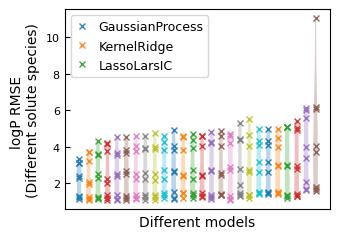

In [7]:
fig, axs = plt.subplots(1,1, figsize=(3.5,2.5), tight_layout=True, dpi=100)

cmap = mpl.colormaps['tab10']
colors_rgba = cmap(np.linspace(0, 1, 10)) #len(model_list)))
colors_rgba = list(colors_rgba)*4

sorted_idx = np.argsort(model_mean)
for n, idx in enumerate(sorted_idx):
    color = colors_rgba[n]
    b = model_list[idx]

    y = np.array( model_ranking[idx] )
    if not np.isnan(y).any():
        vp = axs.violinplot(y, positions=[n], showmeans=False, showmedians=False, showextrema=False)  # facecolor=color, linecolor=color, only for new 
        for pc in vp['bodies']:
            pc.set_facecolor(color)        # fill color
            pc.set_edgecolor("none")      # outline color 
        if n<3:
            axs.plot( [n]*len(y), y, color=color, markersize=5, marker='x', ls='', lw='1', alpha=0.9, label=b) 
        else:
            axs.plot( [n]*len(y), y, color=color, markersize=5, marker='x', ls='', lw='1', alpha=0.9,)
            

axs.tick_params(direction='in',labelsize=8)
axs.set_ylabel('logP RMSE \n(Different solute species)', fontsize=10)
axs.set_xlabel('Different models', fontsize=10)
axs.set_xticks([])

axs.legend(fontsize=9, loc='upper left', handlelength=1) # title='Element',

plt.savefig('Model_sweep_1.png', dpi=800, bbox_inches='tight')
plt.show()

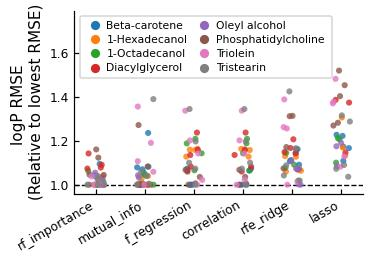

In [9]:
rows = []
for (nf, k), v in feature_method_list.items():
    solute = k.replace('ml_param_screening_', '').replace('_general_all.csv', '')
    for meth, rmse in v:
        rows.append(dict(solute=solute, n_features=nf, method=meth, RMSE=rmse))
D = pd.DataFrame(rows)

# normalize WITHIN each (solute, n_features) group -- RMSE scale differs ~4x
# between solutes, so raw values would only show which solute you are looking at
D['rel']  = D.groupby(['solute','n_features'])['RMSE'].transform(lambda s: s / s.min())
D['rank'] = D.groupby(['solute','n_features'])['RMSE'].rank()

order = D.groupby('method')['rel'].median().sort_values().index.tolist()
cmap = plt.get_cmap('tab10')
sol_colors = {s: cmap(i) for i, s in enumerate(sorted(D.solute.unique()))}

fig, ax = plt.subplots(figsize=(3.5, 2.5), dpi=110, tight_layout=True)
#bp = ax.boxplot([D.loc[D.method == m, 'rel'] for m in order], positions=range(len(order)),
#                widths=0.55, showfliers=False, patch_artist=True,
#                medianprops=dict(color='k', lw=1.4))
#for p in bp['boxes']:
#    p.set(facecolor='0.92', edgecolor='0.4', lw=0.8)

rng = np.random.RandomState(0)
for i, m in enumerate(order):
    sub = D[D.method == m]
    ax.scatter(i + rng.uniform(-0.18, 0.18, len(sub)), sub['rel'],
               s=16, c=[sol_colors[s] for s in sub.solute], alpha=0.8, linewidths=0, zorder=3)

ax.axhline(1.0, color='k', ls='--', lw=0.9, zorder=1)
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('logP RMSE \n(Relative to lowest RMSE)', fontsize=10) # \n(within each solute and feature count)  
ax.tick_params(direction='in', labelsize=8)
for s in ['top','right']:
    ax.spines[s].set_visible(False)

for i, m in enumerate(order):                      # how often each was outright best
    sub = D[D.method == m]
    #ax.text(i, ax.get_ylim()[1]*0.99, f"{(sub['rank']==1).sum()}/{len(sub)}",
    #        ha='center', va='top', fontsize=7, color='0.3')

h = [plt.Line2D([], [], marker='o', ls='', color=sol_colors[s], ms=5, label=header_to_name[s])
     for s in sorted(D.solute.unique())]
ax.legend(handles=h, fontsize=7, frameon=True, ncol=2, loc='upper left', title_fontsize=8, # title='Solute species', 
         labelspacing=0.4, columnspacing=0.6, handletextpad=0.1 )
          #bbox_to_anchor=(0.01, 1.01), 
ax.set_ylim( (0.96,1.79) )

plt.savefig('feature_method_comparison.png', dpi=400, bbox_inches='tight')
plt.show()

# 5. ML model training/testing

In [4]:
def get_base_estimator(screener, model_name):
    """Pulls the raw, untuned estimator template -- from get_model_zoo() for
    models that already exist there (unwrapping any GridSearchCV wrapper),
    or freshly constructed for BayesianRidge."""
    if model_name == 'BayesianRidge':
        return BayesianRidge()
    est = screener.get_model_zoo()[model_name].named_steps['model']
    return est.estimator if isinstance(est, GridSearchCV) else est


def get_selected_indices(fitted_selector):
    """Unified extraction regardless of selector type -- custom selectors
    (CorrelationSelector/LassoImportanceSelector/RFImportanceSelector) expose
    .indices_ directly; sklearn's own SelectKBest/RFE expose a boolean mask
    via .get_support() instead."""
    if hasattr(fitted_selector, 'indices_'):
        return np.asarray(fitted_selector.indices_)
    if hasattr(fitted_selector, 'get_support'):
        return np.where(fitted_selector.get_support())[0]
    raise ValueError(f"Cannot determine selected indices for {type(fitted_selector)}")


class ModelInfo:
    """Matches your existing convention: .features, .model, .scaler --
    so your existing predict_rdkfp() works with these objects unchanged."""
    def __init__(self, molecule, features, model, scaler, model_name, feature_method,
                 n_features, best_params=None, R2=None, RMSE=None, selection_basis=None):
        self.molecule = molecule
        self.features = features        # list of real RDKit descriptor NAMES
        self.model = model               # fitted, unwrapped regressor
        self.scaler = scaler              # fitted StandardScaler (fit on selected columns only)
        self.model_name = model_name
        self.feature_method = feature_method
        self.n_features = n_features
        self.best_params = best_params
        self.R2 = R2
        self.RMSE = RMSE
        self.selection_basis = selection_basis

    def save(self, path):
        joblib.dump(self, path)

    @classmethod
    def load(cls, path):
        return joblib.load(path)

## Outlier check

In [5]:
data_Y = pd.read_csv('data_Y.csv', index_col=0) #.drop( columns=['SMILES','Solvent Inchi'] )
data_X = pd.read_csv('data_X.csv', index_col=0)


In [6]:
def find_outliers_modified_zscore(series, threshold=3.5):
    s = series.dropna()
    median = s.median()
    mad = np.median(np.abs(s - median))
    if mad == 0:
        return pd.Index([])  # degenerate: no spread to compare against
    modified_z = 0.6745 * (s - median) / mad
    return s[np.abs(modified_z) > threshold].index


def build_clean_XY_per_molecule(df_features_prop, solvation_data, molecule_tags=None, smiles_col='SMILES', threshold=100, verbose=True):
    """
    For each molecule's dG column:
      1. Aligns X (df_features_prop) and Y (that dG column) on common solvents.
      2. Drops duplicate-SMILES rows 
      3. Drops robust (median/MAD) outlier rows from Y 
      4. Removes the SAME rows from X, so X and Y stay perfectly aligned.
    Returns a dict: {molecule_tag: {'X': DataFrame, 'Y': Series}}
    """
    if molecule_tags is None:
        molecule_tags = [c.replace('dG_', '').split('(')[0] for c in solvation_data.columns if c.startswith('dG_')]

    all_data = {}
    for tag in molecule_tags:
        col = f'dG_{tag}(kcal/mol)'
        if col not in solvation_data.columns:
            print(f"Skipping {tag}: column {col} not found")
            continue

        common_idx = df_features_prop.index.intersection(solvation_data.index)
        X = df_features_prop.loc[common_idx].copy()
        y = solvation_data.loc[common_idx, col].copy()

        # 1. Duplicate SMILES
        if smiles_col in solvation_data.columns:
            smiles = solvation_data.loc[common_idx, smiles_col]
            dup_solvents = smiles.index[smiles.duplicated(keep='first')]
            if len(dup_solvents) > 0:
                if verbose:
                    print(f"[{tag}] Dropping {len(dup_solvents)} duplicate-SMILES rows: {list(dup_solvents)}")
                X = X.drop(index=dup_solvents)
                y = y.drop(index=dup_solvents)

        # 2. Robust outliers 
        outlier_idx = find_outliers_modified_zscore(y, threshold=threshold)
        if len(outlier_idx) > 0:
            if verbose:
                print(f"[{tag}] Dropping {len(outlier_idx)} outlier rows: {list(outlier_idx)}")
            X = X.drop(index=outlier_idx)
            y = y.drop(index=outlier_idx)

        if verbose:
            print(f"[{tag}] Final clean data: {X.shape[0]} solvents, {X.shape[1]} features\n")

        all_data[tag] = {'X': X, 'Y': y}

    return all_data

# Generate X and Y for each solute molecule
all_data = build_clean_XY_per_molecule(data_X, data_Y)

joblib.dump(all_data, 'data_group_XY.pkl')

[c16] Dropping 3 duplicate-SMILES rows: ['DECALIN', 'TRANS-DECALIN', 'O-XYLENE']
[c16] Final clean data: 127 solvents, 121 features

[d18] Dropping 3 duplicate-SMILES rows: ['DECALIN', 'TRANS-DECALIN', 'O-XYLENE']
[d18] Final clean data: 127 solvents, 121 features

[o18] Dropping 3 duplicate-SMILES rows: ['DECALIN', 'TRANS-DECALIN', 'O-XYLENE']
[o18] Final clean data: 127 solvents, 121 features

[bcr] Dropping 3 duplicate-SMILES rows: ['DECALIN', 'TRANS-DECALIN', 'O-XYLENE']
[bcr] Final clean data: 127 solvents, 121 features

[dcg] Dropping 3 duplicate-SMILES rows: ['DECALIN', 'TRANS-DECALIN', 'O-XYLENE']
[dcg] Final clean data: 127 solvents, 121 features

[pcc] Dropping 3 duplicate-SMILES rows: ['DECALIN', 'TRANS-DECALIN', 'O-XYLENE']
[pcc] Final clean data: 127 solvents, 121 features

[pcs] Dropping 3 duplicate-SMILES rows: ['DECALIN', 'TRANS-DECALIN', 'O-XYLENE']
[pcs] Final clean data: 127 solvents, 121 features

[tro] Dropping 3 duplicate-SMILES rows: ['DECALIN', 'TRANS-DECALIN', 

['data_group_XY.pkl']

## First sweep

In [9]:
from sklearn.linear_model import BayesianRidge
from sklearn.base import clone
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import joblib

FOCUS_MODELS = ['GaussianProcess', 'KernelRidge', 'BayesianRidge', 'SVR-RBF']

def build_gpr_kernel_candidates():
    kernel_families = {
        'RBF':      lambda ls_b: RBF(length_scale=1.0, length_scale_bounds=ls_b),
        'Matern15': lambda ls_b: Matern(length_scale=1.0, length_scale_bounds=ls_b, nu=1.5),
        'Matern25': lambda ls_b: Matern(length_scale=1.0, length_scale_bounds=ls_b, nu=2.5),
        'RationalQuadratic': lambda ls_b: RationalQuadratic(length_scale=1.0, alpha=1.0),
    }
    bound_presets = {
        'tight':  {'ls': (0.5, 20),   'noise': (0.5,  10)},
        'medium': {'ls': (0.5, 50),   'noise': (0.3,  10)},
        'loose':  {'ls': (0.1, 100),  'noise': (0.03, 20)},
        'free':   {'ls': (0.01, 300), 'noise': (1e-3, 20)},   # high-capacity tier
    }
    kernels = []
    for kname, kfn in kernel_families.items():
        for bname, b in bound_presets.items():
            base = kfn(b['ls'])
            kernels.append(ConstantKernel(1.0, (0.01, 1000)) * base
                           + WhiteKernel(b['noise'][0], b['noise']))   # init AT the floor
    return kernels
    
EXPANDED_GRIDS_FOCUSED = {
    'GaussianProcess': {'kernel': build_gpr_kernel_candidates()},   # capacity is in the kernel bounds, below
    # floor alpha=3e-4 / gamma=3e-4 -> ratio ~1.5; the low-alpha/high-gamma corner
    # reaches ratio 1.0 (memorization). CV rejects it if it doesn't generalize.
    'KernelRidge': {'alpha': [0.0003, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10],
                    'gamma': [0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0]},
    'BayesianRidge': {},   # self-tuning 
    'SVR-RBF': { 'C': [1, 10, 100, 1000, 10000], 'gamma': ['scale', 0.0003, 0.003, 0.03, 0.3], 'epsilon': [0.01, 0.05, 0.1] }
}

def train_focused_models_kfold(all_data, feature_methods=('mutual_info', 'rf_importance'),
                                 n_features_list=(15, 20, 25), cv_splits=10, cv_inner=5,
                                 random_state=24, extra_grids=None, save_dir='.', verbose=True):
    """
    For each molecule in all_data ({'X':..., 'Y':...}), sweeps
    FOCUS_MODELS x feature_methods x n_features_list under pooled K-Fold CV
    (3 x 2 x 3 = 18 combos per molecule). Saves ALL combo performances to one
    CSV per molecule, and refits + saves ONLY the single overall-best
    (lowest RMSE, across every model/feature_method/n_features combination)
    as one ModelInfo pickle.
    """
    grids = extra_grids or EXPANDED_GRIDS_FOCUSED
    all_sweeps = {}

    for tag, d in all_data.items():
        X, y = d['X'], d['Y']
        screener = SolventModelScreener(cv_splits=cv_splits, random_state=random_state)
        screener.X_clean, screener.y = X, y  # already row-cleaned; skip load_data/clean_features

        rows = []
        for model_name in FOCUS_MODELS:
            base_est = get_base_estimator(screener, model_name)
            for fmethod in feature_methods:
                for k in n_features_list:
                    selector = screener.get_feature_selector_transformers(k=k)[fmethod]
                    tuned_model = _tune(clone(base_est), grids[model_name], cv_inner=cv_inner)
                    pipe = Pipeline([('select', selector), ('scaler', StandardScaler()), ('model', tuned_model)])
                    y_pred = cross_val_predict(pipe, X.values, y.values,
                                                cv=KFold(cv_splits, shuffle=True, random_state=random_state))
                    r2 = metrics.r2_score(y.values, y_pred)
                    rmse = metrics.root_mean_squared_error(y.values, y_pred)
                    mae = metrics.mean_absolute_error(y.values, y_pred)
                    rows.append({'model': model_name, 'feature_method': fmethod, 'n_features': k,
                                'R2': r2, 'RMSE': rmse, 'MAE': mae})
                    if verbose:
                        print(f"[{tag}] {model_name:16s} {fmethod:14s} k={k:2d}  R2={r2:.3f} RMSE={rmse:.3f}")

        sweep_df = pd.DataFrame(rows).sort_values('RMSE').reset_index(drop=True)
        sweep_df.to_csv(f"{save_dir}/focused_sweep_{tag}.csv", index=False)
        all_sweeps[tag] = sweep_df

        # Single global best combo -- across ALL model x feature_method x n_features,
        # not one-per-model anymore
        best = sweep_df.iloc[0]
        model_name, fmethod, k = best['model'], best['feature_method'], int(best['n_features'])

        selector = screener.get_feature_selector_transformers(k=k)[fmethod]
        selector.fit(X.values, y.values)
        selected_cols = list(X.columns[get_selected_indices(selector)])

        X_sel = X[selected_cols]
        scaler = StandardScaler().fit(X_sel.values)
        X_scaled = scaler.transform(X_sel.values)

        base_est = get_base_estimator(screener, model_name)
        search = GridSearchCV(clone(base_est), grids[model_name], scoring='neg_mean_absolute_error',
                               cv=cv_inner, n_jobs=-1)
        search.fit(X_scaled, y.values)

        mi = ModelInfo(tag, selected_cols, search.best_estimator_, scaler, model_name, fmethod, k,
                        search.best_params_, best['R2'], best['RMSE'], 'kfold')
        mi.save(f"{save_dir}/model_info_{tag}.pkl")

        if verbose:
            print(f"\n[{tag}] BEST OVERALL: {model_name} | {fmethod} | k={k}  "
                  f"R2={best['R2']:.3f} RMSE={best['RMSE']:.3f}")
            print(f"Saved focused_sweep_{tag}.csv ({len(sweep_df)} rows) "
                  f"and model_info_{tag}.pkl\n")

    return all_sweeps

In [15]:
# Run it
results = train_focused_models_kfold(all_data)

[c16] GaussianProcess  mutual_info    k=15  R2=0.394 RMSE=1.196
[c16] GaussianProcess  mutual_info    k=20  R2=0.435 RMSE=1.155
[c16] GaussianProcess  mutual_info    k=25  R2=0.485 RMSE=1.103
[c16] GaussianProcess  rf_importance  k=15  R2=0.293 RMSE=1.292
[c16] GaussianProcess  rf_importance  k=20  R2=0.352 RMSE=1.237
[c16] GaussianProcess  rf_importance  k=25  R2=0.354 RMSE=1.235
[c16] KernelRidge      mutual_info    k=15  R2=-0.069 RMSE=1.589
[c16] KernelRidge      mutual_info    k=20  R2=0.144 RMSE=1.421
[c16] KernelRidge      mutual_info    k=25  R2=0.037 RMSE=1.508
[c16] KernelRidge      rf_importance  k=15  R2=0.309 RMSE=1.277
[c16] KernelRidge      rf_importance  k=20  R2=0.250 RMSE=1.330
[c16] KernelRidge      rf_importance  k=25  R2=0.307 RMSE=1.279
[c16] BayesianRidge    mutual_info    k=15  R2=0.042 RMSE=1.504
[c16] BayesianRidge    mutual_info    k=20  R2=0.071 RMSE=1.481
[c16] BayesianRidge    mutual_info    k=25  R2=0.187 RMSE=1.386
[c16] BayesianRidge    rf_importance  k

## Second sweep - narrowed

In [13]:
from sklearn.base import clone
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (RBF, Matern, RationalQuadratic,
                                               WhiteKernel, ConstantKernel)
from sklearn import metrics

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(it, **kw): return it


KERNEL_FAMILIES = {
    'RBF':      lambda ls_b: RBF(length_scale=1.0, length_scale_bounds=ls_b),
    'Matern15': lambda ls_b: Matern(length_scale=1.0, length_scale_bounds=ls_b, nu=1.5),
    'Matern25': lambda ls_b: Matern(length_scale=1.0, length_scale_bounds=ls_b, nu=2.5),
    'RatQuad':  lambda ls_b: RationalQuadratic(length_scale=1.0, alpha=1.0),
}

# length-scale bounds are held FIXED across presets so the noise floor is the
# only thing that varies -- otherwise you cannot attribute a difference to either
BOUND_PRESETS = {
    'f1.0':  {'ls': (0.5, 100), 'noise': (1.0,  20)},
    'f0.5':  {'ls': (0.5, 100), 'noise': (0.5,  20)},
    'f0.2':  {'ls': (0.5, 100), 'noise': (0.2,  20)},
    'f0.1':  {'ls': (0.5, 100), 'noise': (0.1,  20)},
    'f0.05': {'ls': (0.5, 100), 'noise': (0.05, 20)},
    'f0.02': {'ls': (0.5, 100), 'noise': (0.02, 20)},
}


def make_gp(kernel_family, bound_preset, random_state=24, n_restarts=2):
    """Build a GP with a FIXED kernel family and noise bounds. Exposed so the
    downstream refit step can reconstruct the exact winning setting."""
    kfn = KERNEL_FAMILIES[kernel_family]
    b = BOUND_PRESETS[bound_preset]
    kern = (ConstantKernel(1.0, (0.1, 100)) * kfn(b['ls'])
            + WhiteKernel(b['noise'][0], b['noise']))
    return GaussianProcessRegressor(kernel=kern, normalize_y=True,
                                     n_restarts_optimizer=n_restarts,
                                     alpha=1e-6, random_state=random_state)


def gp_effective_dof(gp, Xt):
    """trace(K(K + sigma^2 I)^-1): parameters the fit actually consumes, after
    accounting for how much the noise term regularizes."""
    try:
        Ks, s2 = gp.kernel_.k1(Xt), gp.kernel_.k2.noise_level
    except AttributeError:
        Ks, s2 = gp.kernel_(Xt), 1e-6
    dof = float(np.trace(Ks @ np.linalg.inv(Ks + s2 * np.eye(len(Ks)))))
    return dof, s2


def screen_gp_settings(all_data, feature_methods=('mutual_info',),
                        n_features_list=(15, 20, 25, 30),
                        kernel_families=tuple(KERNEL_FAMILIES),
                        bound_presets=tuple(BOUND_PRESETS),
                        cv_splits=10, random_state=24,
                        save_dir='.', file_prefix='gp_sweep',
                        verbose=True, screener_cls=None):
    """
    Screen GP settings for every molecule in all_data ({'X':..., 'Y':...}).

    Writes {save_dir}/{file_prefix}_{tag}.csv per molecule and returns
    {tag: DataFrame}. Picks NO winner and saves NO model -- do that downstream.

    screener_cls : your SolventModelScreener (used only for its feature selectors).
    """
    all_sweeps = {}
    for tag, d in all_data.items():
        X, y = d['X'], d['Y']
        n = len(y)
        screener = screener_cls(cv_splits=cv_splits, random_state=random_state)
        screener.X_clean, screener.y = X, y

        combos = [(kf, bp, fm, k) for kf in kernel_families for bp in bound_presets
                  for fm in feature_methods for k in n_features_list]
        rows = []
        it = tqdm(combos, desc=tag, leave=False) if verbose else combos
        for kf, bp, fm, k in it:
            try:
                sel = screener.get_feature_selector_transformers(k=k)[fm]
                pipe = Pipeline([('select', sel), ('scaler', StandardScaler()),
                                 ('model', clone(make_gp(kf, bp, random_state)))])
                yp = cross_val_predict(pipe, X.values, y.values,
                                        cv=KFold(cv_splits, shuffle=True,
                                                 random_state=random_state))
                # model size from a full-data fit of the same pipeline
                pipe.fit(X.values, y.values)
                Xt = pipe.named_steps['scaler'].transform(
                     pipe.named_steps['select'].transform(X.values))
                dof, noise = gp_effective_dof(pipe.named_steps['model'], Xt)
                floor = BOUND_PRESETS[bp]['noise'][0]

                rows.append(dict(molecule=tag, kernel=kf, bounds=bp,
                                 feature_method=fm, n_features=k, n_samples=n,
                                 R2=metrics.r2_score(y.values, yp),
                                 RMSE=metrics.root_mean_squared_error(y.values, yp),
                                 MAE=metrics.mean_absolute_error(y.values, yp),
                                 n_params=dof, ratio=n / dof,
                                 fitted_noise=noise, noise_floor=floor,
                                 at_noise_floor=abs(noise - floor) < 1e-6,
                                 fitted_kernel=str(pipe.named_steps['model'].kernel_)))
            except Exception as e:
                print(f'  FAIL {tag} {kf}/{bp}/{fm}/k={k}: {type(e).__name__}: {e}')

        sweep = pd.DataFrame(rows).sort_values('RMSE').reset_index(drop=True)
        path = f'{save_dir}/{file_prefix}_{tag}.csv'
        sweep.to_csv(path, index=False)
        all_sweeps[tag] = sweep

        if verbose:
            print(f"[{tag}] {len(sweep)} settings -> {path}"
                  f"   (at_noise_floor: {sweep['at_noise_floor'].sum()}/{len(sweep)})")
            print(sweep.head(5)[['kernel','bounds','n_features','R2','RMSE',
                                  'n_params','ratio']].round(3).to_string(index=False))
            print()
    return all_sweeps
    

In [10]:
sweeps = screen_gp_settings(
    all_data,
    feature_methods=('mutual_info','rf_importance'),
    n_features_list=(15, 20, 25, 30),
    bound_presets=('f1.0','f0.5','f0.2','f0.1','f0.05','f0.02'),
    cv_splits=10, random_state=24,
    save_dir='.', screener_cls=SolventModelScreener,
)

c16:   0%|          | 0/192 [00:00<?, ?it/s]

[c16] 192 settings -> ./gp_sweep_c16.csv   (at_noise_floor: 189/192)
  kernel bounds  n_features    R2  RMSE  n_params  ratio
Matern15  f0.02          25 0.539 1.044    90.200  1.408
Matern15  f0.05          25 0.536 1.047    74.799  1.698
 RatQuad   f0.1          25 0.528 1.055    57.809  2.197
     RBF   f0.1          25 0.528 1.056    55.627  2.283
Matern15   f0.1          25 0.527 1.056    60.743  2.091



d18:   0%|          | 0/192 [00:00<?, ?it/s]

[d18] 192 settings -> ./gp_sweep_d18.csv   (at_noise_floor: 177/192)
  kernel bounds  n_features    R2  RMSE  n_params  ratio
     RBF   f0.1          20 0.454 1.236    49.884  2.546
     RBF   f0.2          20 0.449 1.242    38.620  3.288
 RatQuad   f0.1          20 0.438 1.254    51.189  2.481
Matern15  f0.02          25 0.437 1.255    93.298  1.361
 RatQuad   f0.2          20 0.436 1.256    39.246  3.236



o18:   0%|          | 0/192 [00:00<?, ?it/s]

...

[trs] 192 settings -> ./gp_sweep_trs.csv   (at_noise_floor: 191/192)
  kernel bounds  n_features    R2  RMSE  n_params  ratio
     RBF  f0.02          15 0.733 3.157    71.900  1.766
Matern25  f0.02          15 0.730 3.171    77.073  1.648
 RatQuad  f0.02          15 0.706 3.311    71.900  1.766
Matern15  f0.02          15 0.704 3.322    84.939  1.495
Matern25  f0.05          15 0.687 3.417    63.629  1.996



bdo:   0%|          | 0/192 [00:00<?, ?it/s]

[bdo] 192 settings -> ./gp_sweep_bdo.csv   (at_noise_floor: 192/192)
  kernel bounds  n_features    R2  RMSE  n_params  ratio
     RBF  f0.02          15 0.911 0.508    51.189  2.481
 RatQuad  f0.02          15 0.909 0.513    51.189  2.481
Matern25  f0.02          15 0.905 0.524    53.649  2.367
     RBF  f0.02          30 0.905 0.526    66.751  1.903
 RatQuad  f0.02          30 0.905 0.526    66.751  1.903



wat:   0%|          | 0/192 [00:00<?, ?it/s]

[wat] 192 settings -> ./gp_sweep_wat.csv   (at_noise_floor: 192/192)
  kernel bounds  n_features    R2  RMSE  n_params  ratio
Matern15  f0.02          30 0.903 0.534    62.722  2.025
Matern15  f0.05          30 0.901 0.538    48.335  2.628
Matern25  f0.02          30 0.900 0.542    59.511  2.134
Matern15   f0.1          30 0.899 0.545    38.138  3.330
Matern25  f0.05          30 0.899 0.546    46.239  2.747



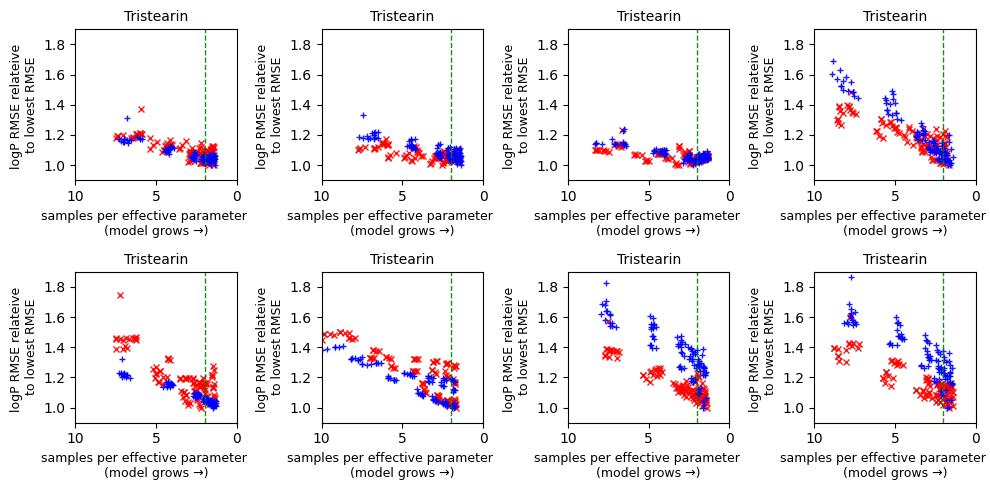

In [44]:
# Plot it

sweeps_csv = { k: f'gp_sweep_{k}.csv' for k in all_data.keys() if if_contain_keys(k) }

fig, axs = plt.subplots(2,int(len(sweeps_csv)/2), figsize=(2.5*len(sweeps_csv)/2,5), tight_layout=True, dpi=100)
for n, (k, csv) in enumerate(sweeps_csv.items()):
    ax = axs[int(n/4)][n%4]
        
    df = pd.read_csv(csv)
    df1 = df[ df['feature_method']=='mutual_info' ] 
    df2 = df[ df['feature_method']=='rf_importance' ] 
    x1,y1 = df1['ratio'], df1['RMSE']
    x2,y2 = df2['ratio'], df2['RMSE']
    best_y1 = min(y1)
    best_y2 = min(y2)
    
    color='r'
    ax.plot( x1, y1/best_y1, color=color, markersize=5, marker='x', ls='', lw='1', alpha=0.9,)
    color='b'
    ax.plot( x2, y2/best_y2, color=color, markersize=5, marker='+', ls='', lw='1', alpha=0.9,)

    ax.set_xlim( [0,10] )
    ax.set_ylim( [0.9,1.9] )
    ax.invert_xaxis()                      # left-to-right = bigger model
    ax.set_xlabel('samples per effective parameter      \n(model grows →)', fontsize=9)
    ax.set_ylabel('logP RMSE relateive \nto lowest RMSE', fontsize=9)
    ax.set_title(header_to_name[mol_tag], fontsize=10)

    ax.plot( [2,2],[0.9, 1.9], color='g', markersize=5, marker='', ls='--', lw='1', alpha=0.9,)

plt.savefig('GP_sweep.png', dpi=800, bbox_inches='tight')
plt.show()


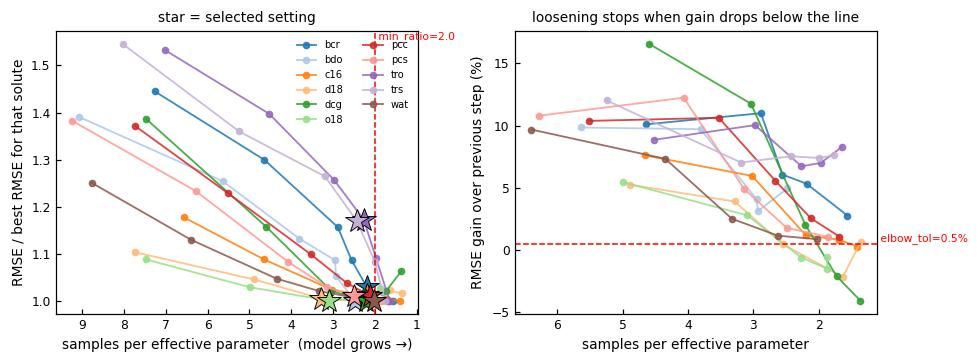

In [42]:
def elbow_curve(sweep):
    """Best setting at each noise floor, ordered from most- to least-regularized,
    with the marginal RMSE gain from loosening the floor one step."""
    g = (sweep.sort_values('RMSE').groupby('noise_floor')
         .first()[['kernel', 'bounds', 'n_features', 'RMSE', 'R2', 'n_params', 'ratio']]
         .sort_index(ascending=False))
    g['pct_RMSE_gain'] = -g['RMSE'].diff() / g['RMSE'].shift(1) * 100
    g['rel_RMSE'] = g['RMSE'] / g['RMSE'].min()
    return g


def _pick(curve, min_ratio, elbow_tol):
    """Reproduce choose_setting's floor selection on the elbow curve."""
    floors = list(curve.index)
    chosen = floors[0]
    for i in range(1, len(floors)):
        if curve.loc[floors[i], 'pct_RMSE_gain'] >= elbow_tol:
            chosen = floors[i]
        else:
            break
    return chosen


def plot_elbow(sweeps, min_ratio=2.0, elbow_tol=0.5, x='ratio', normalize=True,
               figsize=(9, 3.4), dpi=110, savepath=None, annotate_gain=True):
    """
    RMSE against model size, one line per solute.

    sweeps : {tag: DataFrame or path to gp_sweep_{tag}.csv}
    x      : 'ratio' (samples per effective parameter, decreasing = bigger model)
             or 'n_params' or 'noise_floor'
    normalize : divide each solute's RMSE by its own minimum, so solutes with
                very different RMSE scales (1.1 to 4.6 kcal/mol here) share an axis
    """
    curves = {}
    for tag, s in sweeps.items():
        s = pd.read_csv(s) if isinstance(s, str) else s
        curves[tag] = elbow_curve(s)

    fig, axs = plt.subplots(1, 2, figsize=figsize, dpi=dpi, tight_layout=True)
    cmap = plt.get_cmap('tab20')
    ycol = 'rel_RMSE' if normalize else 'RMSE'
    ylab = 'RMSE / best RMSE for that solute' if normalize else 'RMSE (kcal/mol)'

    for i, (tag, c) in enumerate(sorted(curves.items())):
        col = cmap(i % 20)
        xs = c[x].values
        axs[0].plot(xs, c[ycol], '-o', color=col, ms=4, lw=1.2, label=tag, alpha=0.85)
        chosen = _pick(c, min_ratio, elbow_tol)
        # the setting actually deployed must also satisfy min_ratio
        ok = c[c['ratio'] >= min_ratio]
        pick_floor = chosen if (chosen in ok.index) else (ok.index[ok['RMSE'].argmin()]
                                                          if len(ok) else chosen)
        axs[0].plot(c.loc[pick_floor, x], c.loc[pick_floor, ycol], marker='*',
                    ms=16, color=col, mec='k', mew=0.6, zorder=5, ls='')

    if x == 'ratio':
        axs[0].axvline(min_ratio, color='r', ls='--', lw=1)
        axs[0].text(min_ratio, axs[0].get_ylim()[1], f' min_ratio={min_ratio}',
                    color='r', fontsize=7, va='top')
        axs[0].invert_xaxis()                      # left-to-right = bigger model
        axs[0].set_xlabel('samples per effective parameter  (model grows →)', fontsize=9)
    elif x == 'noise_floor':
        axs[0].set_xscale('log'); axs[0].invert_xaxis()
        axs[0].set_xlabel('GP noise floor  (model grows →)', fontsize=9)
    else:
        axs[0].set_xlabel('effective parameters  (model grows →)', fontsize=9)
    axs[0].set_ylabel(ylab, fontsize=9)
    axs[0].tick_params(direction='in', labelsize=8)
    axs[0].legend(fontsize=6.5, frameon=False, ncol=2)
    axs[0].set_title('star = selected setting', fontsize=9)

    # right panel: marginal gain per step, which is what the elbow rule tests
    for i, (tag, c) in enumerate(sorted(curves.items())):
        axs[1].plot(c[x].values, c['pct_RMSE_gain'], '-o', color=cmap(i % 20),
                    ms=4, lw=1.2, alpha=0.85)
    axs[1].axhline(elbow_tol, color='r', ls='--', lw=1)
    axs[1].text(axs[1].get_xlim()[0], elbow_tol, f' elbow_tol={elbow_tol}%',
                color='r', fontsize=7, va='bottom')
    if x == 'ratio':
        axs[1].invert_xaxis(); axs[1].set_xlabel('samples per effective parameter', fontsize=9)
    elif x == 'noise_floor':
        axs[1].set_xscale('log'); axs[1].invert_xaxis(); axs[1].set_xlabel('GP noise floor', fontsize=9)
    else:
        axs[1].set_xlabel('effective parameters', fontsize=9)
    axs[1].set_ylabel('RMSE gain over previous step (%)', fontsize=9)
    axs[1].tick_params(direction='in', labelsize=8)
    axs[1].set_title('loosening stops when gain drops below the line', fontsize=9)

    if savepath:
        plt.savefig(savepath, dpi=400, bbox_inches='tight')
    return fig, curves


sweeps_csv = {k: f'gp_sweep_{k}.csv' for k in all_data.keys()}
fig, curves = plot_elbow(sweeps_csv, min_ratio=2.0, elbow_tol=0.5, x='ratio',)# savepath='elbow_all.png')

In [14]:
"""
Downstream of screen_gp_settings: read the performance CSV, choose a setting,
and refit.

Two artefacts are produced per molecule:
  1. model_info_{tag}.pkl      -- ONE model fitted on all data (deployment model)
  2. model_info_{tag}_loo.pkl  -- N models, one per leave-one-out fold, each
                                  fitted on N-1 samples with its OWN feature
                                  selection and scaler (no leakage). Useful for
                                  honest LOO metrics and for ensemble spread as
                                  an uncertainty estimate.
"""
import numpy as np
import pandas as pd
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(it, **kw): return it


# ------------------------------------------------------------------ selection
def elbow_table(sweep):
    """Best setting at each noise floor, with the marginal gain from loosening
    the floor one step, expressed both ways.

    pct_RMSE_gain is the primary currency: RMSE has target-specific units
    (c16 ~1.1 kcal/mol vs tro ~4.0), so an ABSOLUTE RMSE tolerance would mean
    very different things per molecule. The relative gain is scale-free, like R2.

    Note ranking by RMSE and by R2 is IDENTICAL within a molecule -- they are
    monotonically related -- so only the elbow threshold differs, not the order.
    """
    g = (sweep.sort_values('RMSE').groupby('noise_floor')
         .first()[['kernel', 'bounds', 'feature_method', 'n_features',
                   'R2', 'RMSE', 'n_params', 'ratio']]
         .sort_index(ascending=False))
    g['dR2_vs_previous'] = g['R2'].diff()
    g['dRMSE_vs_previous'] = g['RMSE'].diff()
    g['pct_RMSE_gain'] = -g['RMSE'].diff() / g['RMSE'].shift(1) * 100
    return g


def choose_setting(sweep, min_ratio=3.0, elbow_tol=2.0, criterion='RMSE', verbose=True):
    """
    Pick one setting from a sweep, minimizing RMSE subject to a capacity limit.

    Rule: walk from the most-regularized noise floor downward, continuing only
    while each step still improves RMSE by at least elbow_tol PERCENT. Stop at
    the elbow. Among settings at that floor, take the lowest RMSE that also
    satisfies min_ratio.

    elbow_tol : percent RMSE improvement required to justify a looser floor
                (default 2.0 = 2%). Relative, so the same value is meaningful
                for every target regardless of its dG scale.
    criterion : 'RMSE' (default, relative percent) or 'R2' (absolute), which
                select the same ordering but apply the threshold differently.

    Rationale: marginal likelihood almost always wants a lower noise floor
    (at_noise_floor is nearly always True), but cross-validated error plateaus
    well before that. The CV elbow -- not the flag -- is the criterion.
    """
    tbl = elbow_table(sweep)                      # index sorted high floor -> low
    floors = list(tbl.index)
    col = 'pct_RMSE_gain' if criterion == 'RMSE' else 'dR2_vs_previous'
    chosen_floor = floors[0]
    for i in range(1, len(floors)):
        if tbl.loc[floors[i], col] >= elbow_tol:
            chosen_floor = floors[i]
        else:
            break

    cand = sweep[sweep['noise_floor'] == chosen_floor].sort_values('RMSE')
    ok = cand[cand['ratio'] >= min_ratio] if min_ratio else cand
    if not len(ok):
        # elbow floor has nothing meeting min_ratio -> back off to a stricter floor
        alt = sweep[sweep['ratio'] >= min_ratio].sort_values('RMSE')
        if verbose:
            print(f"  no setting at floor {chosen_floor} meets ratio>={min_ratio}; "
                  f"falling back to best ratio-compliant setting overall")
        ok = alt if len(alt) else cand
    best = ok.iloc[0]

    if verbose:
        print(tbl[['kernel', 'n_features', 'RMSE', 'R2', 'ratio',
                   'pct_RMSE_gain']].round(4).to_string())
        print(f"  -> elbow floor {chosen_floor} ({criterion} gain < {elbow_tol}"
              f"{'%' if criterion=='RMSE' else ''}); chosen: {best['kernel']}/{best['bounds']} "
              f"| {best['feature_method']} | k={int(best['n_features'])} "
              f"| RMSE={best['RMSE']:.4f} R2={best['R2']:.3f} ratio={best['ratio']:.2f}")
    return best


# ------------------------------------------------------------------ containers
class ModelInfo:
    """Single deployment model. Matches the existing .features/.model/.scaler convention."""
    def __init__(self, molecule, features, model, scaler, model_name, feature_method,
                 n_features, best_params=None, R2=None, RMSE=None, selection_basis=None,
                 n_params=None, ratio=None):
        self.molecule, self.features, self.model, self.scaler = molecule, features, model, scaler
        self.model_name, self.feature_method, self.n_features = model_name, feature_method, n_features
        self.best_params, self.R2, self.RMSE = best_params, R2, RMSE
        self.selection_basis, self.n_params, self.ratio = selection_basis, n_params, ratio

    def predict(self, new_X, return_std=False):
        Xs = self.scaler.transform(new_X[self.features].values)
        return self.model.predict(Xs, return_std=return_std)

    def save(self, path): joblib.dump(self, path)
    @classmethod
    def load(cls, path): return joblib.load(path)


class LOOModels:
    """N models, one per leave-one-out fold. Each fold has its own selected
    features and scaler, so nothing from the held-out point leaks in."""
    def __init__(self, molecule, setting, folds, loo_scores):
        self.molecule, self.setting, self.folds = molecule, setting, folds
        self.LOO_R2 = loo_scores['R2']
        self.LOO_RMSE = loo_scores['RMSE']
        self.LOO_MAE = loo_scores['MAE']
        self.n_models = len(folds)

    def oof_predictions(self):
        """The held-out prediction for every sample (each predicted exactly once)."""
        return pd.DataFrame([{'index': f['test_index'], 'y_true': f['y_true'],
                              'y_pred': f['y_pred'], 'y_std': f['y_std']}
                             for f in self.folds]).set_index('index')

    def predict_ensemble(self, new_X):
        """Average across all N fold-models. The spread between them is a
        model-uncertainty estimate that is separate from each GP's own posterior
        std, and it reflects sensitivity to which samples were in training."""
        preds, stds = [], []
        for f in self.folds:
            Xs = f['scaler'].transform(new_X[f['features']].values)
            m, s = f['model'].predict(Xs, return_std=True)
            preds.append(m); stds.append(s)
        P, S = np.array(preds), np.array(stds)
        return pd.DataFrame({'mean': P.mean(0),
                             'ensemble_std': P.std(0),        # disagreement between folds
                             'mean_gp_std': S.mean(0)},       # average posterior width
                            index=new_X.index)

    def save(self, path): joblib.dump(self, path)
    @classmethod
    def load(cls, path): return joblib.load(path)


# ------------------------------------------------------------------ refitting
def refit_from_sweep(all_data, sweeps, screener_cls, min_ratio=3.0, elbow_tol=2.0,
                      criterion='RMSE', random_state=24, save_dir='.', do_loo=True, verbose=True):
    """
    For each molecule: choose a setting from its sweep, fit the all-data model,
    and (optionally) fit the full set of leave-one-out models.

    sweeps : {tag: DataFrame} from screen_gp_settings, or {tag: path to its CSV}.
    """
    out = {}
    for tag, d in all_data.items():
        if tag not in sweeps:
            continue
        sweep = sweeps[tag]
        if isinstance(sweep, str):
            sweep = pd.read_csv(sweep)

        X, y = d['X'], d['Y']
        n = len(y)
        if verbose:
            print(f"\n{'='*64}\n{tag}\n{'='*64}")
        best = choose_setting(sweep, min_ratio=min_ratio, elbow_tol=elbow_tol,
                              criterion=criterion, verbose=verbose)
        kf, bp, fm, k = best['kernel'], best['bounds'], best['feature_method'], int(best['n_features'])

        screener = screener_cls(random_state=random_state)
        screener.X_clean, screener.y = X, y

        # ---------- 1. all-data model ----------
        sel = screener.get_feature_selector_transformers(k=k)[fm]
        sel.fit(X.values, y.values)
        idx = sel.indices_ if hasattr(sel, 'indices_') else np.where(sel.get_support())[0]
        cols = list(X.columns[idx])
        scaler = StandardScaler().fit(X[cols].values)
        Xs = scaler.transform(X[cols].values)
        gp = make_gp(kf, bp, random_state).fit(Xs, y.values)
        dof, noise = gp_effective_dof(gp, Xs)

        mi = ModelInfo(tag, cols, gp, scaler, f'GP-{kf}-{bp}', fm, k,
                       {'kernel': str(gp.kernel_), 'fitted_noise': noise},
                       best['R2'], best['RMSE'], 'kfold_elbow', dof, n / dof)
        mi.save(f'{save_dir}/model_info_{tag}.pkl')
        if verbose:
            print(f"  saved model_info_{tag}.pkl  (eff_params={dof:.1f}, ratio={n/dof:.2f})")

        # ---------- 2. leave-one-out models ----------
        loo_obj = None
        if do_loo:
            folds = []
            rng = range(n)
            for i in tqdm(rng, desc=f'{tag} LOO', leave=False) if verbose else rng:
                te = X.index[[i]]
                tr = X.index.drop(te)
                s = screener.get_feature_selector_transformers(k=k)[fm]
                s.fit(X.loc[tr].values, y.loc[tr].values)
                ii = s.indices_ if hasattr(s, 'indices_') else np.where(s.get_support())[0]
                c = list(X.columns[ii])
                sc = StandardScaler().fit(X.loc[tr, c].values)
                m = make_gp(kf, bp, random_state).fit(sc.transform(X.loc[tr, c].values),
                                                       y.loc[tr].values)
                mu, sd = m.predict(sc.transform(X.loc[te, c].values), return_std=True)
                folds.append(dict(test_index=te[0], features=c, scaler=sc, model=m,
                                  y_true=float(y.loc[te].iloc[0]),
                                  y_pred=float(mu[0]), y_std=float(sd[0])))

            yt = np.array([f['y_true'] for f in folds])
            yp = np.array([f['y_pred'] for f in folds])
            scores = dict(R2=metrics.r2_score(yt, yp),
                          RMSE=metrics.root_mean_squared_error(yt, yp),
                          MAE=metrics.mean_absolute_error(yt, yp))
            setting = dict(kernel=kf, bounds=bp, feature_method=fm, n_features=k,
                           noise_floor=BOUND_PRESETS[bp]['noise'][0], random_state=random_state)
            loo_obj = LOOModels(tag, setting, folds, scores)
            loo_obj.save(f'{save_dir}/model_info_{tag}_loo.pkl')
            if verbose:
                print(f"  saved model_info_{tag}_loo.pkl  ({len(folds)} models)  "
                      f"LOO RMSE={scores['RMSE']:.4f}  R2={scores['R2']:.3f}  "
                      f"(K-fold RMSE was {best['RMSE']:.4f})")

        out[tag] = {'setting': best, 'model_info': mi, 'loo': loo_obj}
    return out

In [15]:
sweeps_csv = { k: f'gp_sweep_{k}.csv' for k in all_data.keys() }

results = refit_from_sweep(
    all_data, sweeps_csv, SolventModelScreener,
    min_ratio=2, elbow_tol=0.1, criterion='RMSE', save_dir='.',  # elbow_tol 2.0 = 2%
    do_loo = False,
)


c16
               kernel  n_features    RMSE      R2   ratio  pct_RMSE_gain
noise_floor                                                             
1.00              RBF          25  1.2288  0.3604  6.5729            NaN
0.50              RBF          25  1.1354  0.4540  4.6544         7.6023
0.20              RBF          25  1.0678  0.5170  3.0199         5.9520
0.10          RatQuad          25  1.0554  0.5282  2.1969         1.1677
0.05         Matern15          25  1.0466  0.5360  1.6979         0.8304
0.02         Matern15          25  1.0437  0.5386  1.4080         0.2741
  -> elbow floor 0.02 (RMSE gain < 0.1%); chosen: RBF/f0.02 | mutual_info | k=15 | RMSE=1.1953 R2=0.395 ratio=2.21
  saved model_info_c16.pkl  (eff_params=57.5, ratio=2.21)

d18
               kernel  n_features    RMSE      R2   ratio  pct_RMSE_gain
noise_floor                                                             
1.00          RatQuad          15  1.3635  0.3358  7.7437            NaN
0.50          

# 6. ML prediction

In [5]:
from rdkit.ML.Descriptors import MoleculeDescriptors

def _is_ensemble(model):
    return hasattr(model, 'folds')

def _required_features(model):
    """Every descriptor the model(s) need, so RDKit is called only once."""
    if _is_ensemble(model):
        feats = set()
        for f in model.folds:
            feats.update(f['features'])
        return sorted(feats)
    return list(model.features)

def load_model(path_or_model):
    return joblib.load(path_or_model) if isinstance(path_or_model, str) else path_or_model


# ---------------------------------------------------------------- descriptors
def compute_descriptors(smiles, feature_names, verbose=True):
    """RDKit descriptors for the named features only. SMILES that fail to parse
    become NaN rows rather than silently shifting the table."""
    calc = MoleculeDescriptors.MolecularDescriptorCalculator(list(feature_names))
    rows, bad = [], []
    it = tqdm(smiles, desc='descriptors') if verbose else smiles
    for s in it:
        mol = Chem.MolFromSmiles(s)
        if mol is None:
            bad.append(s); rows.append([np.nan] * len(feature_names))
        else:
            rows.append(list(calc.CalcDescriptors(mol)))
    if bad and verbose:
        print(f'  {len(bad)} SMILES failed to parse, e.g. {bad[:3]}')
    return pd.DataFrame(rows, columns=list(feature_names), index=list(smiles))

# ------------------------------------------------------------------ prediction
def predict_from_descriptors(model, desc_df, temp_K=298.15, return_per_model=False):
    model = load_model(model)
    need = _required_features(model)
    missing = [c for c in need if c not in desc_df.columns]
    if missing:
        raise ValueError(f'descriptor table missing {len(missing)} columns, e.g. {missing[:5]}')

    if _is_ensemble(model):
        mus, sds = [], []
        for f in model.folds:
            mu, sd = f['model'].predict(
                f['scaler'].transform(desc_df[f['features']].values), return_std=True)
            mus.append(mu); sds.append(sd)
        MU, SD = np.asarray(mus), np.asarray(sds)
        mean = MU.mean(axis=0)
        gp_var = (SD ** 2).mean(axis=0)                 # within-model
        ens_var = MU.var(axis=0, ddof=1)                # between-model
        n_models, mtype = MU.shape[0], 'ensemble'
    else:
        mu, sd = model.model.predict(
            model.scaler.transform(desc_df[model.features].values), return_std=True)
        MU = mu[None, :]
        mean, gp_var, ens_var = mu, sd ** 2, np.zeros_like(mu)
        n_models, mtype = 1, 'single'

    total_std = np.sqrt(gp_var + ens_var)
    conv = -1.0 / (2.303 * 1.987e-3 * temp_K)           # dG (kcal/mol) -> logP
    out = pd.DataFrame({
        'dG_mean':    mean,
        'dG_std':     total_std,
        'dG_gp_std':  np.sqrt(gp_var),
        'dG_ens_std': np.sqrt(ens_var),
        'logP_mean':  mean * conv,
        'logP_std':   total_std * abs(conv),
        'n_models':   n_models,
        'model_type': mtype,
    }, index=desc_df.index)
    out['logP_lo95'] = out['logP_mean'] - 1.96 * out['logP_std']
    out['logP_hi95'] = out['logP_mean'] + 1.96 * out['logP_std']

    if return_per_model:
        return out, pd.DataFrame(MU, columns=desc_df.index)
    return out


def predict_from_smiles(model, smiles, temp_K=298.15, verbose=True, return_per_model=False):
    model = load_model(model)
    feats = _required_features(model)
    if verbose:
        if _is_ensemble(model):
            per = len(model.folds[0]['features'])
            print(f'ensemble: {len(model.folds)} models, {per} features each, '
                  f'{len(feats)} unique across folds')
        else:
            print(f'single model: {len(feats)} features')
    desc = compute_descriptors(smiles, feats, verbose=verbose)
    return predict_from_descriptors(model, desc, temp_K, return_per_model)


def predict_all_targets(models, smiles, temp_K=298.15, value='logP_mean', verbose=True):
    """
    models : {tag: ModelInfo/LOOModels/path}. RDKit runs ONCE over the union of
    every model's features, then each target is predicted from that one table.

    Returns (values_df, full_dict) where values_df has one column per target.
    """
    models = {t: load_model(m) for t, m in models.items()}
    feats = sorted(set().union(*[set(_required_features(m)) for m in models.values()]))
    if verbose:
        print(f'{len(models)} targets, {len(feats)} unique descriptors overall')
    desc = compute_descriptors(smiles, feats, verbose=verbose)

    full = {t: predict_from_descriptors(m, desc, temp_K) for t, m in models.items()}
    values = pd.DataFrame({t: r[value] for t, r in full.items()}, index=desc.index)
    return values, full
    
#models = {tag: f'model_info_{tag}_loo.pkl' for tag in header_to_name}
#values, full = predict_all_targets(models, new_smiles, temp_K=273.15+25)

single model: 15 features


descriptors: 100%|██████████| 129/129 [00:00<00:00, 1368.72it/s]


single model: 20 features


descriptors: 100%|██████████| 129/129 [00:00<00:00, 943.11it/s]


single model: 20 features


...

descriptors: 100%|██████████| 129/129 [00:00<00:00, 713.48it/s]


single model: 15 features


descriptors: 100%|██████████| 129/129 [00:00<00:00, 1384.26it/s]


single model: 15 features


descriptors: 100%|██████████| 129/129 [00:00<00:00, 847.25it/s]
C:\Users\d2j\AppData\Local\Temp\ipykernel_21196\3453083741.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig('Training_results.png', dpi=800, bbox_inches='tight')
C:\MyApp\Anaconda\envs\RDkit_from_globopt\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


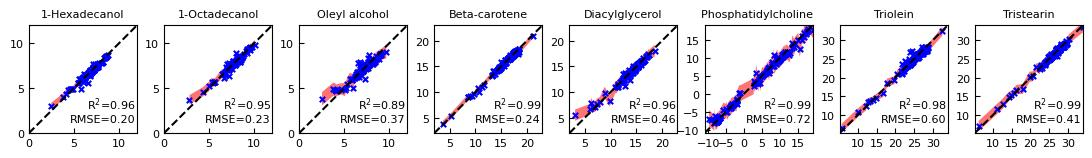

"\n# --------------- Plot the colorbar ---------------\ncmap = sc.get_cmap()             \nnorm = sc.norm          \n\nfig2 = plt.figure(figsize=(2.0, 4.0))\n# create a narrow axes on the right side for the colorbar\ncax2 = fig2.add_axes([0.7, 0.1, 0.15, 0.8])  # [left, bottom, width, height] in figure coords\n# create a dummy mappable with the SAME norm/cmap\nsm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)\nsm.set_array([])  # only needed to satisfy colorbar internals\n\ncbar2 = fig2.colorbar(sm, cax=cax2)\ncbar2.set_ticks([])\ncbar2.ax.xaxis.set_ticks([])\ncbar2.ax.yaxis.set_ticks([])\ncbar2.ax.tick_params(length=0, labelsize=0)  # hide tick marks and labels\ncbar2.outline.set_visible(False)\nfig2.tight_layout()\nplt.savefig('Training_resultcolorbar.png', dpi=800, bbox_inches='tight')\nfig2.show()\n"

In [6]:
from matplotlib.colors import LogNorm

from scipy.stats import gaussian_kde
from scipy.interpolate import UnivariateSpline

temp_K = 273.15 + 25
env_color = 'r' #'y' #plt.get_cmap('Oranges')(0.60)

data_Y = pd.read_csv('data_Y.csv', index_col=0)
group_XY = joblib.load('data_group_XY.pkl')
models_zoo_path = 'data/'

plot_speices_keys = [ k for k in header_to_name if if_contain_keys(k) ]
#fig, axs = plt.subplots(2,4, figsize=(7, 3.5), tight_layout=True, dpi=100, gridspec_kw={'wspace': 0.25, 'hspace': 0.4})
fig, axs = plt.subplots(1,len(plot_speices_keys), figsize=(1.7*len(plot_speices_keys), 1.4), tight_layout=True, dpi=100, gridspec_kw={'wspace': 0.25})

ax_lim_setting = [ (0,12), (0,12), (0,12), (2,23), (2,23), (-11,19), (5.1,34), (5.1,34), ]
for n, mol_tag in enumerate(plot_speices_keys):
    df = data_Y
    df = df[ df['SMILES']!='O' ] # Show the real metric & (df['SMILES']!='C1CCC2CCCCC2C1') & (df['SMILES']!='CC1=CC=CC=C1C')
    smiles = df['SMILES']
    reference = df[f'dG_{mol_tag}(kcal/mol)']

    model_file = os.path.join(models_zoo_path, f'model_info_{mol_tag}.pkl')
    predictions_summary = predict_from_smiles(model_file, smiles, temp_K=temp_K)

    reference = -reference / (2.303*1.987*0.001*temp_K)
    predictions = predictions_summary['logP_mean'] 
    prediction_uncertainty = predictions_summary['logP_std'] 

    # compute metrics in the SAME units already shown on the plot
    r2 = metrics.r2_score(reference, predictions)
    rmse = metrics.root_mean_squared_error(reference, predictions)
    mae = metrics.mean_absolute_error(reference, predictions)

    # Color data points by density
    xy = np.vstack([reference, predictions])    
    kde = gaussian_kde(xy)
    z = kde(xy)  
    idx = np.argsort(z)
    x_sorted = reference.iloc[idx]
    y_sorted = predictions.iloc[idx]
    z_sorted = z[idx]
    e_sorted = prediction_uncertainty.iloc[idx]

    # Add error envelope
    y_upper = y_sorted + e_sorted
    y_lower = y_sorted - e_sorted
    order = np.argsort(x_sorted)
    x_env = np.asarray(x_sorted)[order]
    y_up_env = np.asarray(y_upper)[order]
    y_lo_env = np.asarray(y_lower)[order]

    ax = axs[n] #[int(n/4)][n%4]
    #axs[n].plot(reference, predictions, ls='', marker='o', color='b')
    sc = ax.scatter( x_sorted, y_sorted, c='b',  marker='x', s=15, zorder=2) #z_sorted, cmap='cool', norm=LogNorm(), edgecolor='none', 
    #axs[n].errorbar( x_sorted, y_sorted, yerr=e_sorted, fmt='none', ecolor='0.3', elinewidth=1.2, capsize=3, color='k')
    ax.fill_between( x_env, y_lo_env, y_up_env, color=env_color, alpha=0.55, edgecolor='none', zorder=0, label='Error envelope' )
    
    ax.tick_params(which='both', direction='in', labelsize='8')
    #ax.set_ylabel('ML predicted logP', fontsize=12, color='k')
    #ax.set_xlabel('DFT logP', fontsize=12, color='k')
    ax.set_title(header_to_name[mol_tag], fontsize=8)
    
    ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(5))
    #ax_max = np.max([reference.max(), predictions.max()])+0.5
    #ax_min = np.min([reference.min(), predictions.min()])-0.5
    ax_lim = ax_lim_setting[n]
    ax.set_xlim(ax_lim)#(ax_min, ax_max))
    ax.set_ylim(ax_lim)#(ax_min, ax_max))
    #ax.plot((ax_min, ax_max), (ax_min, ax_max), ls='--', marker='', color='k')
    ax.plot( ax_lim, ax_lim, ls='--', marker='', color='k')
            
    ax.text(0.38, 0.35, f'R$^2$={r2:.2f}\nRMSE={rmse:.2f}',#\nMAE={mae:.3f}',
                transform=ax.transAxes, fontsize=8, va='top', ha='left', ma='right',)
                #bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.8))

plt.savefig('Training_results.png', dpi=800, bbox_inches='tight')
plt.show()
"""
# --------------- Plot the colorbar ---------------
cmap = sc.get_cmap()             
norm = sc.norm          

fig2 = plt.figure(figsize=(2.0, 4.0))
# create a narrow axes on the right side for the colorbar
cax2 = fig2.add_axes([0.7, 0.1, 0.15, 0.8])  # [left, bottom, width, height] in figure coords
# create a dummy mappable with the SAME norm/cmap
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # only needed to satisfy colorbar internals

cbar2 = fig2.colorbar(sm, cax=cax2)
cbar2.set_ticks([])
cbar2.ax.xaxis.set_ticks([])
cbar2.ax.yaxis.set_ticks([])
cbar2.ax.tick_params(length=0, labelsize=0)  # hide tick marks and labels
cbar2.outline.set_visible(False)
fig2.tight_layout()
plt.savefig('Training_resultcolorbar.png', dpi=800, bbox_inches='tight')
fig2.show()
"""

## Revisit BDO

single model: 15 features


descriptors: 100%|██████████| 129/129 [00:00<00:00, 876.59it/s]


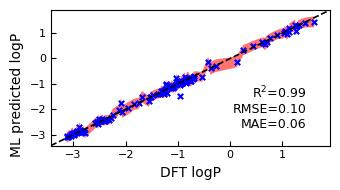

In [9]:
# Revisit BDO:
temp_K = 273.15 + 25
env_color = 'r' #'y' #plt.get_cmap('Oranges')(0.60)

data_Y = pd.read_csv('data_Y.csv', index_col=0)
models_zoo_path = './'

mol_tag = 'bdo'

df = data_Y
df = df[ df['SMILES']!='O' ] # Show the real metric & (df['SMILES']!='C1CCC2CCCCC2C1') & (df['SMILES']!='CC1=CC=CC=C1C')
smiles = df['SMILES']
reference = df[f'dG_{mol_tag}(kcal/mol)']

model_file = os.path.join(models_zoo_path, f'model_info_{mol_tag}.pkl')
predictions_summary = predict_from_smiles(model_file, smiles, temp_K=temp_K)

reference = -reference / (2.303*1.987*0.001*temp_K)
predictions = predictions_summary['logP_mean'] 
prediction_uncertainty = predictions_summary['logP_std'] 
# compute metrics in the SAME units already shown on the plot
r2 = metrics.r2_score(reference, predictions)
rmse = metrics.root_mean_squared_error(reference, predictions)
mae = metrics.mean_absolute_error(reference, predictions)

# Color data points by density
xy = np.vstack([reference, predictions])    
kde = gaussian_kde(xy)
z = kde(xy)  
idx = np.argsort(z)
x_sorted, y_sorted, e_sorted = reference.iloc[idx], predictions.iloc[idx], prediction_uncertainty.iloc[idx]
# Add error envelope
y_upper, y_lower = y_sorted + e_sorted, y_sorted - e_sorted
order = np.argsort(x_sorted)
x_env, y_up_env, y_lo_env = np.asarray(x_sorted)[order], np.asarray(y_upper)[order], np.asarray(y_lower)[order]

fig, ax = plt.subplots(1,1, figsize=(3.5,2), tight_layout=True, dpi=100 )
sc = ax.scatter( x_sorted, y_sorted, c='b',  marker='x', s=15, zorder=2) #z_sorted, cmap='cool', norm=LogNorm(), edgecolor='none', 
ax.fill_between( x_env, y_lo_env, y_up_env, color=env_color, alpha=0.55, edgecolor='none', zorder=0, label='Error envelope' )
    
ax.tick_params(which='both', direction='in', labelsize='8')
ax.set_ylabel('ML predicted logP        ', fontsize=10, color='k')
ax.set_xlabel('DFT logP', fontsize=10, color='k')

ax_max = np.max([reference.max(), predictions.max()])+0.3
ax_min = np.min([reference.min(), predictions.min()])-0.3
ax_lim = [ax_min, ax_max]
ax.plot(ax_lim,ax_lim, ls='--', lw=1.2, marker='', color='k')
ax.set_xlim(ax_lim)
ax.set_ylim(ax_lim)

ax.text(0.65, 0.45, f'R$^2$={r2:.2f}\nRMSE={rmse:.2f}\nMAE={mae:.2f}', transform=ax.transAxes, fontsize=9, va='top', ha='left', ma='right',)

plt.savefig('Revisit_BDO_1.png', dpi=800, bbox_inches='tight')
plt.show()

[14:03:00] WARNING: Omitted undefined stereo

[14:03:00] WARNING: Omitted undefined stereo

[14:03:00] WARNING: Omitted undefined stereo

[14:03:00] WARNING: Omitted undefined stereo



Fitting coeff:  0.057 0.021
single model: 15 features


descriptors: 100%|██████████| 11/11 [00:00<00:00, 578.61it/s]


CCCCO               0.924322
CCCCCCO             0.512407
CCCCCCCO            0.388624
CCCCCCCCO           0.269466
CCCCCCCCCO          0.201773
CCOC(=O)C           0.023775
CCCCCOC(=O)C        0.022725
CC1=CC=CC=C1        0.021258
CC1CCCCC1           0.021068
CCCCCCCCCCCC        0.021053
CCCCCCCCCCCCCCCC    0.021045
Name: logP_mean, dtype: float64

CCCCO               0.108512
CCCCCCO             0.108224
CCCCCCCO            0.108425
CCCCCCCCO           0.109131
CCCCCCCCCO          0.110202
CCOC(=O)C           0.108777
CCCCCOC(=O)C        0.112745
CC1=CC=CC=C1        0.110815
CC1CCCCC1           0.109293
CCCCCCCCCCCC        0.108977
CCCCCCCCCCCCCCCC    0.113465
Name: logP_std, dtype: float64

...

CCCCC(C)O                   0.109687
CC(C)CC(C)O                 0.110156
CC(C)CCCC(C)CCO             0.124392
CCCCCCCC/C=C\CCCCCCCCO      0.241894
CC(C)COC(=O)C               0.112117
CCC(C)OC(=O)C               0.112701
CC(C)OC(=O)C                0.110072
CCCCOC(=O)CCC               0.117575
CCCCCCOC(=O)C               0.116760
CCCCOC(=O)C(=O)OCCCC        0.845473
CCOC(=O)CCCCC(=O)OCC        0.845282
CCCCCCCCCCCCCC(=O)OC(C)C    0.289724
CC(C)(C)C1CCCCC1            0.118659
Name: logP_std, dtype: float64

single model: 15 features


descriptors: 100%|██████████| 7/7 [00:00<00:00, 364.95it/s]


CCC(C)CO          0.522614
CC(C)CCO          0.493672
CCC(CC)O          0.461081
CCC(CC)CO         0.432615
CCCC(CC)O         0.260337
C1CCC(CC1)CCO     0.103487
CCCC(C(CC)CO)O    0.027836
Name: logP_mean, dtype: float64

CCC(C)CO          0.108076
CC(C)CCO          0.107994
CCC(CC)O          0.110221
CCC(CC)CO         0.108688
CCCC(CC)O         0.111209
C1CCC(CC1)CCO     0.115538
CCCC(C(CC)CO)O    0.316315
Name: logP_std, dtype: float64

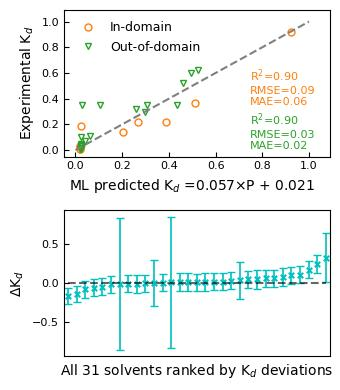

In [10]:
temp_K = 273.15+25

# Re-visit BDO data
exp_bdo = pd.read_csv('../Diol/Experimental_data.csv')#, index_col=0).set_index('Solvent Name')
included_data, dft = [],[]
for smi in exp_bdo['SMILES']:
    mol = Chem.MolFromSmiles(smi)
    inchi = Chem.MolToInchi(mol)
    df = data_Y[ (data_Y['SMILES']==smi) | (data_Y['Solvent Inchi']==inchi) ]
    if len(df)==0:
        included_data.append( False )
        dft.append( np.nan )
    else:
        included_data.append( True )
        dft.append( df['dG_bdo(kcal/mol)'].values[0] )
exp_bdo['in-domain'] = included_data
exp_bdo['dG_DFT'] = dft

# Fit P to Kd
dG, experiment = exp_bdo[exp_bdo['in-domain']]['dG_DFT'], exp_bdo[exp_bdo['in-domain']]['Kd 20C']
predictions = np.power( 10, -dG / (2.303*1.987*0.001*temp_K) ) 
fit_a, fit_b = np.polyfit(predictions, experiment, 1)
fit_a, fit_b = np.round( [fit_a, fit_b], 3 )
print('Fitting coeff: ',fit_a, fit_b)

all_bdo_points = []
# Plot ------------- subplot 1 --------------
fig, axs = plt.subplots(2,1,figsize=(3.5,4),tight_layout=True)
model_file = 'model_info_bdo.pkl'

# Get in-domain prediction
df = exp_bdo[ exp_bdo['in-domain'] ] 
solvent_name, experiment, SMILES  = df['Solvent'], df['Kd 20C'], df['SMILES'].to_list()

predictions_summary = predict_from_smiles(model_file, SMILES, temp_K=temp_K)
predictions = np.power( 10, predictions_summary['logP_mean'] )
prediction_uncertainty = np.power( 10, predictions_summary['logP_std'] )
predictions = fit_a*predictions + fit_b
prediction_uncertainty = fit_a*prediction_uncertainty + fit_b
display( predictions, prediction_uncertainty )
all_bdo_points += [ [p,e,u,0] for p,e,u in zip(predictions,experiment,prediction_uncertainty) ]

#colors = [plt.cm.rainbow(n) for n in np.linspace(0,1,len(predictions)) ]
axs[0].plot( predictions, experiment, color='tab:orange', label='In-domain', lw=2, ls='', marker='o', ms=5, markerfacecolor='none')
#axs[0].errorbar( predictions, experiment, xerr=prediction_uncertainty, fmt='none', ecolor='0.3', elinewidth=1.2, capsize=3, color='k')
r2 = metrics.r2_score(predictions, experiment)
rmse = metrics.root_mean_squared_error(predictions, experiment)
mae = metrics.mean_absolute_error(predictions, experiment)
axs[0].text(0.7, 0.35, f'R$^2$={r2:.2f}\nRMSE={rmse:.2f}\nMAE={mae:.2f}', transform=axs[0].transAxes, fontsize=8, color='tab:orange')
            #va='top', ha='left', bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.8))

# Plot out-of-domain
df = exp_bdo[ ~exp_bdo['in-domain'] ] 
solvent_name, experiment, SMILES  = df['Solvent'], df['Kd 20C'], df['SMILES'].to_list()

predictions_summary = predict_from_smiles(model_file, SMILES, temp_K=temp_K)
predictions = np.power( 10, predictions_summary['logP_mean'] )
prediction_uncertainty = np.power( 10, predictions_summary['logP_std'] )
predictions = fit_a*predictions + fit_b
prediction_uncertainty = fit_a*prediction_uncertainty + fit_b
display( predictions, prediction_uncertainty )
all_bdo_points += [ [p,e,u,1] for p,e,u in zip(predictions,experiment,prediction_uncertainty) ]

axs[0].plot( predictions, experiment, color='tab:green', label='Out-of-domain', lw=2, ls='', marker='v', ms=5, markerfacecolor='none' )
r2 = metrics.r2_score(predictions, experiment)
rmse = metrics.root_mean_squared_error(predictions, experiment)
mae = metrics.mean_absolute_error(predictions, experiment)
axs[0].text(0.7, 0.05, f'R$^2$={r2:.2f}\nRMSE={rmse:.2f}\nMAE={mae:.2f}', transform=axs[0].transAxes, fontsize=8, color='tab:green')#
            #va='top', ha='left', bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.8))
# Labels
fitted_text_line = fr'{fit_a}$\times$P + {fit_b}   '
axs[0].set_ylabel('Experimental K$_d$',fontsize=10) 
axs[0].set_xlabel('ML predicted K$_d$ =' +fitted_text_line, fontsize=10) 
axs[0].tick_params(direction='in',labelsize=8)
axs[0].set_xlim([-0.05, 1.09])
axs[0].set_ylim([-0.05, 1.09])
axs[0].legend(fontsize=9, frameon=False, loc='upper left', ncol=1, columnspacing=1, )#bbox_to_anchor=(0.5, 1.25) )

axs[0].plot([0,1], [0,1], ls='--',marker='', lw=1.5, color='gray') 

# Plot ------------- subplot 2 --------------
df = pd.read_csv('../Diol/Experimental_data_2ndGen.csv')
solvent_name, experiment, SMILES  = df['Solvent'], df['Kd 20C'], df['SMILES'].to_list()

predictions_summary = predict_from_smiles(model_file, SMILES, temp_K=temp_K)
predictions = np.power( 10, predictions_summary['logP_mean'] )
prediction_uncertainty = np.power( 10, predictions_summary['logP_std'] )
predictions = fit_a*predictions + fit_b
prediction_uncertainty = fit_a*prediction_uncertainty + fit_b
display( predictions, prediction_uncertainty )
all_bdo_points += [ [p,e,u,1] for p,e,u in zip(predictions,experiment,prediction_uncertainty) ]
axs[0].plot( predictions, experiment, color='tab:green', lw=2, ls='', marker='v', ms=5, markerfacecolor='none')

"""
df['K_BDO'] = predictions

bars = df.plot(kind='bar', stacked=False, y=['Kd 20C','K_BDO'], ax=axs[1], xlabel=solvent_name, color=['deeppink','deepskyblue'], width=0.8, alpha=0.9)
axs[1].set_xlabel(None,fontsize=10) ## input X name
axs[1].set_ylabel('K$_d$' ,fontsize=10) ## input Y name
axs[1].tick_params(direction='in',labelsize=8, axis='y')
axs[1].set_xticklabels( solvent_name, rotation=45, fontsize=10, ha='right', rotation_mode='anchor')
#axs.set_ylim([0.1,1.4])
#axs.set_xticks( [] )
axs[1].legend( ['Experiment','ML'], fontsize=10, frameon=False, ncol=1, handlelength=1, handletextpad=0.2, columnspacing=1)
#plt.yscale('log')
"""

all_bdo_points = np.transpose( all_bdo_points )
y = all_bdo_points[1] - all_bdo_points[0]
idx = np.argsort(y)
x = np.arange( len(y) )
y = y[idx]
y_error = all_bdo_points[2][idx]
colors = [ 'tab:orange' if i==0 else 'tab:green' for i in all_bdo_points[3] ]
#axs[1].plot( x,y, color='c', lw=2, ls='', marker='s', ms=3)
axs[1].scatter( x,y,  c='c',  marker='x', s=15 )
eb = axs[1].errorbar( x,y, yerr=y_error, fmt='none', ecolor='c', elinewidth=1.2, capsize=3 )

#axs[1].bar(x, y, color='skyblue', edgecolor='black')
axs[1].plot( x,[0]*len(x), color='k', lw=1.5, ls='--', marker='', ms=5, alpha=0.6)
axs[1].set_xlim([-0.5, len(x)-1+0.5])
axs[1].set_xticks( [] )
axs[1].set_ylabel('ΔK$_d$',fontsize=10) 
axs[1].set_xlabel('All 31 solvents ranked by K$_d$ deviations', fontsize=10) 
axs[1].tick_params(direction='in',labelsize=8)

plt.savefig('Revisit_BDO_2.png', dpi=800, bbox_inches='tight')
plt.show()

## Solvent screening

In [10]:
# From a collection of solvent SMILES
new_solvent = pd.read_csv('solvent_list.csv' )
solvents = new_solvent['SMILES'].to_list()

good_elements = ['C','H','O','N',]#'S']#,'P']
mask_element = []   ## molecules to keep, keep=True
for smi in solvents:
    mol = Chem.MolFromSmiles( smi )
    element = set([at.GetSymbol() for at in mol.GetAtoms()])  ## GetSymbol , GetAtomicNum
    mask = all(e in good_elements for e in element) and '.' not in smi
    mask_element.append( mask )
new_solvent = new_solvent[mask_element]

new_solvent = new_solvent.rename(columns={'Solvent': 'Name'})
new_solvent = new_solvent.set_index('SMILES')

new_solvent

[14:48:41] WARNING: not removing hydrogen atom without neighbors


,Name,Inchi,Synonym
SMILES,,,
CC(=CCCC(=CC=O)C)C,(E)-Citral,"InChI=1S/C10H16O/c1-9(2)5-4-6-10(3)7-8-11/h5,7...",RefChem:1066155
CC(=C)C1CCC(=CC1)CO,(S)-( )-Perillyl Alcohol.,InChI=1S/C10H16O/c1-8(2)10-5-3-9(7-11)4-6-10/h...,PERILLYL ALCOHOL
CCC=CCCO,(Z)-3-Hexen-1-ol,"InChI=1S/C6H12O/c1-2-3-4-5-6-7/h3-4,7H,2,5-6H2...",Hex-3-en-1-ol
CCC=CCCOC=O,(Z)-3-Hexen-1-Yl Formate,"InChI=1S/C7H12O2/c1-2-3-4-5-6-9-7-8/h3-4,7H,2,...",HEX-3-EN-1-YL FORMATE
CCC=CCCCO,(Z)-4-Hepten-1-ol,"InChI=1S/C7H14O/c1-2-3-4-5-6-7-8/h3-4,8H,2,5-7...",20851-55-2
...,...,...,...
COC1=CC=C(C=C1)/C=C/C2=CC(=CC(=O)O2)OC,NaN,InChI=1S/C15H14O4/c1-17-12-6-3-11(4-7-12)5-8-1...,NaN
CC1=CC=CC=C1N=NC2=C(C=CC3=CC=CC=C32)N,NaN,InChI=1S/C17H15N3/c1-12-6-2-5-9-16(12)19-20-17...,NaN
C[C@H]1CCCC(=O)CCC/C=C/C2=C(C(=CC(=C2)O)O)C(=O)O1,NaN,InChI=1S/C18H22O5/c1-12-6-5-9-14(19)8-4-2-3-7-...,NaN


In [11]:
# Merge old and new solvents
old_solvent = data_Y[ ['SMILES','Solvent Inchi'] ]
old_solvent = old_solvent.reset_index().set_index('SMILES')
old_solvent = old_solvent.rename(columns={'Solvent Name': 'Name', 'Solvent Inchi': 'Inchi'})

old_solvent['tag'] = 'dft'
new_solvent['tag'] = 'new'

new_solvent = new_solvent[~new_solvent.index.isin(old_solvent.index)] # if the solvent is in DFT already, skip
df_solvents = pd.concat([old_solvent, new_solvent])
df_solvents = df_solvents.drop_duplicates(subset=['Inchi']) # double check Inchi
#df_solvents.to_csv("solvent_list.csv", index=False)

df_solvents

,Name,Inchi,tag,Synonym
SMILES,,,,
C1CCC2CCCCC2C1,CIS-DECALIN,InChI=1S/C10H18/c1-2-6-10-8-4-3-7-9(10)5-1/h9-...,dft,NaN
CCCCCCCCCCCCCCCC,N-HEXADECANE,InChI=1S/C16H34/c1-3-5-7-9-11-13-15-16-14-12-1...,dft,NaN
CCCCCCCCCCCCCCC,N-PENTADECANE,InChI=1S/C15H32/c1-3-5-7-9-11-13-15-14-12-10-8...,dft,NaN
CCCCCCCCCCCC,N-DODECANE,InChI=1S/C12H26/c1-3-5-7-9-11-12-10-8-6-4-2/h3...,dft,NaN
CCCCCC(=O)O,HEXANOIC ACID,"InChI=1S/C6H12O2/c1-2-3-4-5-6(7)8/h2-5H2,1H3,(...",dft,NaN
...,...,...,...,...
COC1=CC=C(C=C1)/C=C/C2=CC(=CC(=O)O2)OC,NaN,InChI=1S/C15H14O4/c1-17-12-6-3-11(4-7-12)5-8-1...,new,NaN
CC1=CC=CC=C1N=NC2=C(C=CC3=CC=CC=C32)N,NaN,InChI=1S/C17H15N3/c1-12-6-2-5-9-16(12)19-20-17...,new,NaN
C[C@H]1CCCC(=O)CCC/C=C/C2=C(C(=CC(=C2)O)O)C(=O)O1,NaN,InChI=1S/C18H22O5/c1-12-6-5-9-14(19)8-4-2-3-7-...,new,NaN


In [12]:
from thermo.group_contribution import Joback

def get_joback_properties(smi):
    try:
        j = Joback(smi)
        result = j.estimate()
        return result.get('Tb'), result.get('Tm')
    except Exception as e:
        return None, None

Tb_K, Tm_K = [],[]
for smi in df_solvents.index:
    b, m = get_joback_properties(smi) 
    Tb_K.append( b )
    Tm_K.append( m ) 
    
df_solvents['Tb_K'] = Tb_K
df_solvents['Tm_K'] = Tm_K

[14:49:02] WARNING: not removing hydrogen atom without neighbors


In [14]:
%%capture --no-display

def get_descriptor(model, smiles):
    model = load_model(model)
    feats = _required_features(model)
    desc = compute_descriptors(smiles, feats)
    return desc


temp_K = 273.15+25

feature_solvents = {}
solvents = df_solvents.index.to_list()
for n, mol_tag in enumerate(header_to_name):
    model_file = os.path.join(models_zoo_path, f'model_info_{mol_tag}.pkl')
    predictions_summary = predict_from_smiles(model_file, solvents, temp_K=temp_K)
    logp = predictions_summary['logP_mean'] 
    logp_uncertainty = predictions_summary['logP_std'] 
    
    df_solvents[f'logP_{mol_tag}'] = logp
    df_solvents[f'logP_{mol_tag}_err'] = logp_uncertainty

    feature = get_descriptor(model_file, solvents)
    feature_solvents[mol_tag] = feature
    
df_solvents

,Name,Inchi,tag,Synonym,Tb_K,Tm_K,logP_c16,logP_c16_err,logP_d18,logP_d18_err,...,logP_pcs,logP_pcs_err,logP_tro,logP_tro_err,logP_trs,logP_trs_err,logP_bdo,logP_bdo_err,logP_wat,logP_wat_err
SMILES,,,,,,,,,,,,,,,,,,,,,
C1CCC2CCCCC2C1,CIS-DECALIN,InChI=1S/C10H18/c1-2-6-10-8-4-3-7-9(10)5-1/h9-...,dft,NaN,458.96,224.26,5.545450,0.361926,6.600057,0.497450,...,-25.146752,1.670798,21.849616,1.129162,23.301572,1.361599,-3.040562,0.222191,-4.229915,0.221622
CCCCCCCCCCCCCCCC,N-HEXADECANE,InChI=1S/C16H34/c1-3-5-7-9-11-13-15-16-14-12-1...,dft,NaN,565.68,270.08,6.046549,0.289526,6.749935,0.476318,...,-25.902155,1.596304,22.360953,1.069772,23.783682,1.303313,-3.103335,0.210103,-4.211700,0.216551
CCCCCCCCCCCCCCC,N-PENTADECANE,InChI=1S/C15H32/c1-3-5-7-9-11-13-15-14-12-10-8...,dft,NaN,542.80,258.81,6.056669,0.289109,6.788585,0.448709,...,-26.152168,1.494885,22.518699,0.985861,23.961333,1.204979,-3.093880,0.201820,-4.233638,0.205191
CCCCCCCCCCCC,N-DODECANE,InChI=1S/C12H26/c1-3-5-7-9-11-12-10-8-6-4-2/h3...,dft,NaN,474.16,225.00,6.101183,0.287746,6.978652,0.420461,...,-26.531029,1.422646,23.120259,0.951334,24.630023,1.189418,-3.031032,0.188492,-4.255183,0.193162
CCCCCC(=O)O,HEXANOIC ACID,"InChI=1S/C6H12O2/c1-2-3-4-5-6(7)8/h2-5H2,1H3,(...",dft,NaN,482.39,317.98,4.791996,0.340757,5.714007,0.429533,...,-24.859636,1.634801,13.498845,0.981054,14.920299,1.246170,-2.979369,0.211279,-3.346301,0.225835
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
COC1=CC=C(C=C1)/C=C/C2=CC(=CC(=O)O2)OC,NaN,InChI=1S/C15H14O4/c1-17-12-6-3-11(4-7-12)5-8-1...,new,NaN,705.64,424.68,6.642318,2.617923,7.096586,2.860072,...,-12.846263,7.971921,26.405794,9.104348,30.055612,10.206473,-1.270474,1.160983,-3.118858,1.331827
CC1=CC=CC=C1N=NC2=C(C=CC3=CC=CC=C32)N,NaN,InChI=1S/C17H15N3/c1-12-6-2-5-9-16(12)19-20-17...,new,NaN,897.57,NaN,6.921499,2.709871,6.928555,2.341757,...,-12.017336,7.807795,26.131882,8.598569,24.366872,8.289077,-1.270459,1.160983,-2.434241,1.241541
C[C@H]1CCCC(=O)CCC/C=C/C2=C(C(=CC(=C2)O)O)C(=O)O1,NaN,InChI=1S/C18H22O5/c1-12-6-5-9-14(19)8-4-2-3-7-...,new,NaN,966.17,659.61,6.549262,2.925432,6.931784,2.974508,...,-13.214167,7.988781,24.090593,9.961345,24.423529,11.405660,-1.270458,1.160983,-2.859074,1.417746


In [15]:
df_solvents.to_csv("df_solvents_list.csv", index=True)

with open("feature_of_solvents_list.pkl", "wb") as file:
    pickle.dump(feature_solvents, file)

# 7. Solvent analysis

In [10]:
# Performance data
ranked = pd.read_csv('df_solvents_list.csv' , index_col=0)

mask_tag = ranked['tag']=='dft'# SMD
ranked1 = ranked[mask_tag] # Full SMD
ranked2 = ranked[~mask_tag] # Full new

print('Original length = ', len(ranked))
ranked = ranked[ ranked['Tm_K']<273.15+80 ]  # liquid state instead of solid
print('After liquid check, length = ', len(ranked))

logp = [ Chem.Crippen.MolLogP(Chem.MolFromSmiles(smi)) for smi in ranked.index ]
ranked['logS'] = 0.5 - 0.01 * ((ranked['Tm_K']-273.15 - 25).clip(lower=0)) - logp # General Solubility Equation (Yalkowsky & Valvani, 1980)
ranked = ranked[ ranked['logS']<-2 ]
print('After water solubility check, length = ', len(ranked))

ranked

Original length =  7125
After liquid check, length =  3191
After water solubility check, length =  1147


,Name,Inchi,tag,Synonym,Tb_K,Tm_K,logP_c16,logP_c16_err,logP_d18,logP_d18_err,...,logP_pcs_err,logP_tro,logP_tro_err,logP_trs,logP_trs_err,logP_bdo,logP_bdo_err,logP_wat,logP_wat_err,logS
SMILES,,,,,,,,,,,,,,,,,,,,,
C1CCC2CCCCC2C1,CIS-DECALIN,InChI=1S/C10H18/c1-2-6-10-8-4-3-7-9(10)5-1/h9-...,dft,NaN,458.96,224.26,5.545450,0.361926,6.600057,0.497450,...,1.670798,21.849616,1.129162,23.301572,1.361599,-3.040562,0.222191,-4.229915,0.221622,-2.86680
CCCCCCCCCCCCCCCC,N-HEXADECANE,InChI=1S/C16H34/c1-3-5-7-9-11-13-15-16-14-12-1...,dft,NaN,565.68,270.08,6.046549,0.289526,6.749935,0.476318,...,1.596304,22.360953,1.069772,23.783682,1.303313,-3.103335,0.210103,-4.211700,0.216551,-5.98760
CCCCCCCCCCCCCCC,N-PENTADECANE,InChI=1S/C15H32/c1-3-5-7-9-11-13-15-14-12-10-8...,dft,NaN,542.80,258.81,6.056669,0.289109,6.788585,0.448709,...,1.494885,22.518699,0.985861,23.961333,1.204979,-3.093880,0.201820,-4.233638,0.205191,-5.59750
CCCCCCCCCCCC,N-DODECANE,InChI=1S/C12H26/c1-3-5-7-9-11-12-10-8-6-4-2/h3...,dft,NaN,474.16,225.00,6.101183,0.287746,6.978652,0.420461,...,1.422646,23.120259,0.951334,24.630023,1.189418,-3.031032,0.188492,-4.255183,0.193162,-4.42720
CCCCCCCCCC,N-DECANE,"InChI=1S/C10H22/c1-3-5-7-9-10-8-6-4-2/h3-10H2,...",dft,NaN,428.40,202.46,6.152396,0.287035,7.169877,0.413541,...,1.391638,23.640375,0.918930,25.155033,1.111981,-2.973685,0.184936,-4.254252,0.189742,-3.64700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CCCCCCC(C)CCCCCC,NaN,InChI=1S/C14H30/c1-4-6-8-10-12-14(3)13-11-9-7-...,new,NaN,519.48,232.54,6.199917,0.330357,6.834512,0.687922,...,2.319343,22.810204,2.478668,24.307228,3.994218,-3.056628,0.200141,-4.211888,0.220496,-5.06330
CCCCCCCCCCCCC#N,NaN,InChI=1S/C13H25N/c1-2-3-4-5-6-7-8-9-10-11-12-1...,new,NaN,599.12,301.26,7.360441,0.738948,7.356536,1.237690,...,3.894255,27.305065,4.741875,24.764909,4.468005,-1.174432,0.694233,-2.704605,0.358302,-4.35208
CC(=CC(C)(C)CC(C)(C)C)C,NaN,"InChI=1S/C12H24/c1-10(2)8-12(6,7)9-11(3,4)5/h8...",new,NaN,471.74,210.80,6.672696,1.522067,7.594588,0.588166,...,2.353522,24.838776,1.922725,25.631263,3.661027,-2.863655,0.407051,-4.035120,0.282197,-3.91500


## Feature space

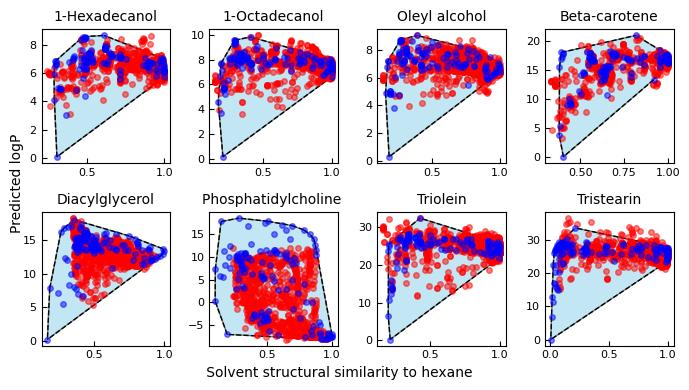

In [11]:
from numpy.linalg import norm
from scipy.spatial import ConvexHull


# Feature data
with open("feature_of_solvents_list.pkl", "rb") as file:
    feature_solvents = pickle.load(file)
# Not DFT solvent
ranked2 = ranked[ ranked['tag']=='new' ] #.index
# Interested solutes
interested_keys = [ k for k in feature_solvents.keys() if if_contain_keys(k) ]

# Plot distribution
fig, axs = plt.subplots(2, 4, figsize=(7, 4), tight_layout=True, dpi=100)

for n,k in enumerate(interested_keys):
    ax = axs[int(n/4)][n%4]
    df = feature_solvents[k]
    ref =  df[ df.index == 'CCCCCC' ].values[0] # Hexane vector
    # SMD
    df1 = df.loc[ ranked1.index ]
    cos_sim1 = np.dot(df1,ref)/(norm(df1,axis=1)*norm(ref))
    logp1 = ranked1[f"logP_{k}"]
    # New
    df2 = df.loc[ ranked2.index ]
    cos_sim2 = np.dot(df2,ref)/(norm(df2,axis=1)*norm(ref))
    logp2 = ranked2[f"logP_{k}"]

    points = np.transpose( [ cos_sim1, logp1 ] )
    hull = ConvexHull(points)
    hull_points = points[hull.vertices]
    ax.fill(hull_points[:, 0], hull_points[:, 1], facecolor='skyblue', alpha=0.5, edgecolor='k', linewidth=1, )#label='Solvent space defined by DFT data')
    for simplex in hull.simplices:
        ax.plot(points[simplex, 0], points[simplex, 1], color='k', lw=1, ls='--')
    
    ax.plot(cos_sim2, logp2, ls='', marker='o', color='r', label='New solvents', alpha=0.5, markersize=4)
    ax.plot(cos_sim1, logp1, ls='', marker='o', color='b', label='SMD solvents', alpha=0.5, markersize=4)
    
    ax.tick_params(which='both', direction='in', labelsize='8')
    ax.set_title(header_to_name[k], fontsize=10)
    #ax_max = np.max([reference.max(), predictions.max()])+0.5
    #ax_min = np.min([reference.min(), predictions.min()])-0.5
    #axs[n].set_xlim((ax_min, ax_max))
    #axs[n].set_ylim((ax_min, ax_max))

axs[0][0].set_ylabel('Predicted logP'+' '*40, fontsize=10, color='k')
axs[1][1].set_xlabel(' '*30+'Solvent structural similarity to hexane', fontsize=10, color='k')

plt.savefig('Feature_analysis_similarity.png', dpi=400,)# bbox_inches='tight')
plt.show()


        threshold  frac_new_in_domain  median_nn_dft  median_nn_new
solute                                                             
c16         4.679               0.774          0.592          1.915
d18         5.557               0.751          0.320          2.058
o18         5.174               0.749          0.503          2.258
bcr         5.171               0.903          0.158          1.735
dcg         6.426               0.699          1.390          4.140
pcc         8.166               0.809          0.875          3.655
tro         5.481               0.922          0.349          1.969
trs         4.244               0.660          1.023          2.727


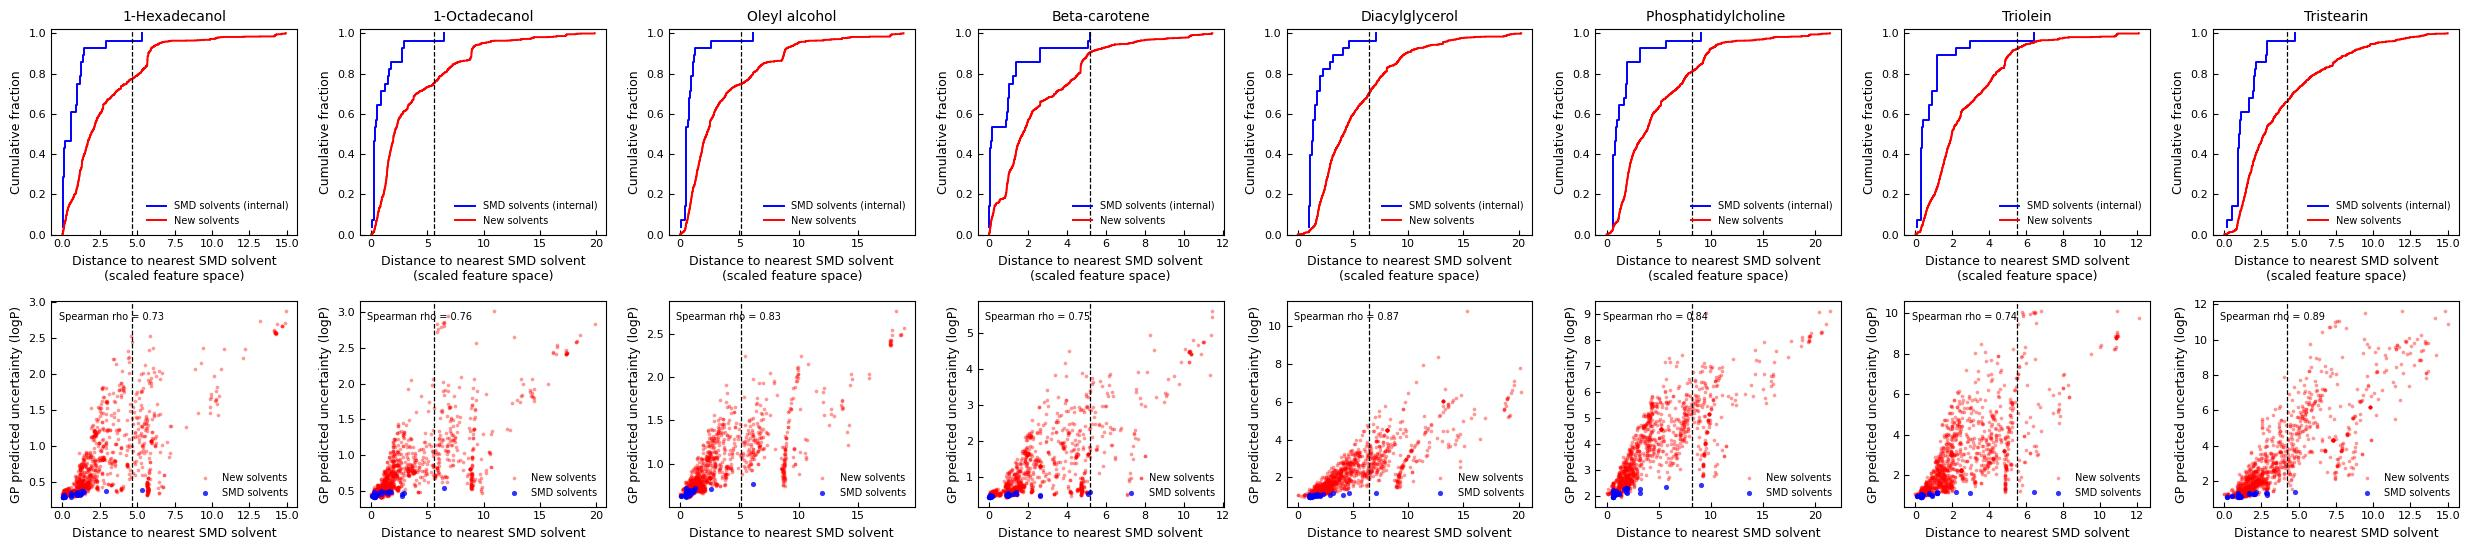

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

def nn_domain(features, dft_idx, new_idx, k=1, pct=95):
    """
    Nearest-neighbour applicability domain in a model's feature space.

    features : DataFrame (rows = solvents, cols = the descriptors this solute's
               model uses), e.g. feature_solvents[k]
    Returns a frame with, per solvent:
        nn_dist  -- distance to nearest DFT solvent (for DFT solvents: nearest OTHER)
        in_domain-- nn_dist <= pct-th percentile of the DFT set's own nn_dist
    plus the threshold used.
    """
    dft_idx = features.index.intersection(dft_idx)
    new_idx = features.index.intersection(new_idx)
    sc = StandardScaler().fit(features.loc[dft_idx].values)        # scale on DFT only
    Xd = sc.transform(features.loc[dft_idx].values)
    Xn = sc.transform(features.loc[new_idx].values)

    nn = NearestNeighbors(n_neighbors=k + 1).fit(Xd)
    d_dft = nn.kneighbors(Xd)[0][:, 1:].mean(axis=1)               # skip self
    d_new = nn.kneighbors(Xn, n_neighbors=k)[0].mean(axis=1)

    thr = np.percentile(d_dft, pct)
    out = pd.concat([pd.DataFrame({'nn_dist': d_dft, 'tag': 'dft'}, index=dft_idx),
                     pd.DataFrame({'nn_dist': d_new, 'tag': 'new'}, index=new_idx)])
    out['in_domain'] = out['nn_dist'] <= thr
    return out, thr


def plot_nn_domain(dom, thr, ax=None, title=None, err=None, dpi=110, figsize=(3.6, 3.0)):
    """ECDF of NN distance: DFT-internal reference vs new solvents, with threshold."""
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, dpi=dpi, tight_layout=True)
    for tag, col, lab in [('dft', 'b', 'SMD solvents (internal)'), ('new', 'r', 'New solvents')]:
        d = np.sort(dom.loc[dom.tag == tag, 'nn_dist'].values)
        ax.step(d, np.arange(1, len(d) + 1) / len(d), where='post', color=col, lw=1.4, label=lab)
    ax.axvline(thr, color='k', ls='--', lw=0.9)
    frac_in = dom.loc[dom.tag == 'new', 'in_domain'].mean()
    #ax.text(0.53, 0.56, f'{frac_in:.0%} of new solvents\ninside SMD 95th pct',
    #        transform=ax.transAxes, fontsize=7, va='top')
    #print( f'{frac_in:.0%} of new solvents\ninside SMD 95th pct' )
    ax.set_xlabel('Distance to nearest SMD solvent\n(scaled feature space)', fontsize=9)
    ax.set_ylabel('Cumulative fraction', fontsize=9)
    ax.set_ylim(0, 1.02); ax.tick_params(direction='in', labelsize=8)
    ax.legend(fontsize=7, frameon=False, loc='lower right')
    if title: ax.set_title(title, fontsize=10)
    return ax


def plot_nn_vs_uncertainty(dom, err, thr, ax=None, title=None, dpi=110, figsize=(3.6, 3.0)):
    """Does the GP's own uncertainty track distance from training data? It should."""
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, dpi=dpi, tight_layout=True)
    d = dom.join(err.rename('err'), how='inner')
    new = d[d.tag == 'new']; dft = d[d.tag == 'dft']
    ax.scatter(new['nn_dist'], new['err'], s=7, c='r', alpha=0.4, linewidths=0, label='New solvents')
    ax.scatter(dft['nn_dist'], dft['err'], s=14, c='b', alpha=0.8, linewidths=0, label='SMD solvents')
    ax.axvline(thr, color='k', ls='--', lw=0.9)
    from scipy.stats import spearmanr
    rho = spearmanr(new['nn_dist'], new['err']).statistic
    ax.text(0.03, 0.95, f'Spearman rho = {rho:.2f}', transform=ax.transAxes, fontsize=7, va='top')
    #print( f'Spearman rho = {rho:.2f}' )
    ax.set_xlabel('Distance to nearest SMD solvent', fontsize=9)
    ax.set_ylabel('GP predicted uncertainty (logP)', fontsize=9)
    ax.tick_params(direction='in', labelsize=8)
    ax.legend(fontsize=7, frameon=False, loc='lower right')
    if title: ax.set_title(title, fontsize=10)
    return ax


def domain_report(feature_solvents, ranked, solutes, header_to_name, pct=95, k=1,
                  savepath=None, dpi=100):
    """Two rows: ECDF per solute (top) and NN-distance vs GP uncertainty (bottom)."""
    dft_idx = ranked.index[ranked.tag == 'dft']; new_idx = ranked.index[ranked.tag == 'new']
    n = len(solutes)
    fig, axs = plt.subplots(2, n, figsize=(3.1 * n, 5.6), dpi=dpi, tight_layout=True)
    axs = np.atleast_2d(axs)
    if n == 1: axs = axs.T
    summary = []
    for j, s in enumerate(solutes):
        #print( s )
        dom, thr = nn_domain(feature_solvents[s], dft_idx, new_idx, k=k, pct=pct)
        plot_nn_domain(dom, thr, ax=axs[0, j], title=header_to_name.get(s, s))
        plot_nn_vs_uncertainty(dom, ranked[f'logP_{s}_err'], thr, ax=axs[1, j])
        summary.append(dict(solute=s, threshold=thr,
                            frac_new_in_domain=dom.loc[dom.tag == 'new', 'in_domain'].mean(),
                            median_nn_dft=dom.loc[dom.tag == 'dft', 'nn_dist'].median(),
                            median_nn_new=dom.loc[dom.tag == 'new', 'nn_dist'].median()))
    if savepath: plt.savefig(savepath, dpi=400, bbox_inches='tight')
    return pd.DataFrame(summary).set_index('solute').round(3)


report = domain_report(feature_solvents, ranked, interested_keys, header_to_name, pct=99, k=1, savepath='Feature_analysis_domain.png')
print(report)

## Pareto Front

In [14]:
# ----------------------------------------------------------------- scoring
class SelectivityScaler:
    """Robust z = 0.6745 (x - median) / MAD, anchors fitted ONCE and reused."""
    def __init__(self): self.anchors = {}
    def fit(self, df, cols):
        for c in cols:
            v = df[c].dropna(); med = v.median(); mad = np.median(np.abs(v - med))
            self.anchors[c] = {'median': med, 'mad': mad}
        return self
    def transform(self, df, cols):
        out = pd.DataFrame(index=df.index)
        for c in cols:
            med, mad = self.anchors[c]['median'], self.anchors[c]['mad']
            out[c] = 0.0 if (mad == 0 or np.isnan(mad)) else 0.6745 * (df[c] - med) / mad
        return out
    def scale_err(self, df, cols):
        """Uncertainty passes through the same linear map (no centering)."""
        out = pd.DataFrame(index=df.index)
        for c in cols:
            mad = self.anchors[c]['mad']
            out[c] = 0.0 if (mad == 0 or np.isnan(mad)) else 0.6745 * df[f'{c}_err'] / mad
        return out

def pareto_mask(x, y):
    o = np.argsort(-x, kind='stable'); dom = np.zeros(len(x), bool); best = -np.inf
    for i in o:
        if y[i] <= best: dom[i] = True
        else: best = y[i]
    return ~dom

def score_and_rank(ranked, good, bad, baseline='CCCCCC', n_draws=1000,
                   random_state=42, correlated_errors=False, verbose=True):
    cg = [f'logP_{m}' for m in good]; cb = [f'logP_{m}' for m in bad]
    sc = SelectivityScaler().fit(ranked, cg + cb)
    z = sc.transform(ranked, cg + cb); e = sc.scale_err(ranked, cg + cb)
    zg, zb = z[cg].values, z[cb].values
    eg, eb = e[cg].values, e[cb].values

    out = ranked.copy()
    for c in cg + cb: out[f'z_{c}'] = z[c]
    out['Gi'] = zg.mean(1)
    out['Bi'] = zb.mean(1)
    out['bad_rejection_score'] = -out['Bi']
    out['composite'] = out['Gi'] + out['bad_rejection_score']
    if correlated_errors:
        gstd, bstd = eg.mean(1), eb.mean(1); out['composite_std'] = gstd + bstd
    else:
        gstd = np.sqrt((eg**2).sum(1))/len(cg); bstd = np.sqrt((eb**2).sum(1))/len(cb)
        out['composite_std'] = np.sqrt(gstd**2 + bstd**2)
    out['det_front'] = pareto_mask(out['Gi'].values, out['bad_rejection_score'].values)

    rng = np.random.default_rng(random_state); n = len(out)
    onf = np.zeros(n); beat = np.zeros(n)
    bi = out.index.get_loc(baseline) if baseline in out.index else None
    for _ in range(n_draws):
        if correlated_errors:
            ug = rng.normal(0, 1, (n, 1)); ub = rng.normal(0, 1, (n, 1))
        else:
            ug = rng.normal(0, 1, zg.shape); ub = rng.normal(0, 1, zb.shape)
        g = (zg + ug*eg).mean(1); b = -(zb + ub*eb).mean(1)
        onf += pareto_mask(g, b)
        if bi is not None: beat += (g > g[bi]) & (b > b[bi])
    out['P_pareto'] = onf / n_draws
    if bi is not None: out[f'P_beats_{baseline}'] = beat / n_draws

    if verbose:
        print(f'{n} candidates | deterministic front {out.det_front.sum()} | '
              f'mean MC front {onf.sum()/n_draws:.1f} | max P_pareto {out.P_pareto.max():.3f}')
        if bi is not None:
            print(f'baseline {baseline} composite={out.composite.iloc[bi]:+.3f} | '
                  f'{(out[f"P_beats_{baseline}"]>0.7).sum()} beat it with P>0.7, '
                  f'{(out[f"P_beats_{baseline}"]>0.5).sum()} with P>0.5')
    key = f'P_beats_{baseline}' if bi is not None else 'P_pareto'
    return out.sort_values(key, ascending=False), sc


# ----------------------------------------------------------------- figures
def plot_pareto(out, baseline='CCCCCC', color_by=None, n_label=4, figsize=(7, 2.3), dpi=100, cmap='cool', savepath=None,
                          front_dft_color='darkorange', front_new_color='b'):
    """
    Left : DFT (SMD) solvents only, with their own Pareto front.
    Right: full library, with the combined front AND the DFT-only front overlaid, showing how far the new candidates push the front outward.
    color_by : column used for point colour. Default P_beats_<baseline> (fixed 0-1 scale). Pass 'composite' to colour by composite score instead
               (then a robust 0.5-99.5 percentile range is used).
    """
    pkey = f'P_beats_{baseline}'
    color_by = color_by or pkey
    is_prob = color_by.startswith('P_')
    if is_prob:
        vmin, vmax = 0.0, 1.0
    else:
        vmin, vmax = np.percentile(out[color_by], [0.5, 99.5])

    dft = out[out.tag == 'dft']; new = out[out.tag == 'new']
    front_dft = dft[pareto_mask(dft['Gi'].values, dft['bad_rejection_score'].values)].sort_values('Gi')
    front_all = out[out['det_front']].sort_values('Gi')

    fig, axs = plt.subplots(1, 2, figsize=figsize, dpi=dpi)
    common = dict(cmap=cmap, s=12, alpha=0.75, linewidths=0, vmin=vmin, vmax=vmax)

    # ---- left: DFT only ----
    axs[0].scatter(dft['Gi'], dft['bad_rejection_score'], c=dft[color_by], **common, zorder=2)
    axs[0].scatter(dft['Gi'], dft['bad_rejection_score'], facecolors='none', edgecolors='k', s=14, linewidths=0.6, label='DFT solvents', zorder=3)
    axs[0].plot(front_dft['Gi'], front_dft['bad_rejection_score'], color=front_dft_color, lw=1.5, marker='', ms=1, label='Pareto front (DFT)', zorder=1)

    # ---- right: new library + combined front + DFT front ----
    axs[1].scatter(dft['Gi'], dft['bad_rejection_score'], facecolors='none', edgecolors='k', s=14, linewidths=0.6, label='DFT solvents', zorder=3)
    sc = axs[1].scatter(new['Gi'], new['bad_rejection_score'], c=new[color_by], label='New solvents', **common, zorder=2)
    axs[1].plot(front_all['Gi'], front_all['bad_rejection_score'], color=front_new_color, lw=1.5, marker='', ms=1, label='Pareto front (New)', zorder=1)
    axs[1].plot(front_dft['Gi'], front_dft['bad_rejection_score'], color=front_dft_color, lw=1.5, marker='', ms=1, zorder=4) # label='Pareto front (SMD)', 

    if n_label:
        top = out.nlargest(n_label, pkey)
        offs = [(6, 8), (6, -10), (-6, 8), (-6, -10), (6, 20), (6, -22)]
        for k, (smi, r) in enumerate(top.iterrows()):
            nm = r['Name'] if isinstance(r.get('Name'), str) else smi
            dx, dy = offs[k % len(offs)]
            axs[1].annotate(nm[:16], (r['Gi'], r['bad_rejection_score']), fontsize=6, zorder=6,
                            xytext=(dx, dy), textcoords='offset points',
                            ha='left' if dx > 0 else 'right',
                            arrowprops=dict(arrowstyle='-', lw=0.4, color='0.4'))

    # ---- shared decoration ----
    xlim = (out['Gi'].min() - 0.2, out['Gi'].max() + 0.2)
    ylim = (out['bad_rejection_score'].min() - 0.2, out['bad_rejection_score'].max() + 0.2)
    for n in (0, 1):
        if baseline in out.index:
            h = out.loc[baseline]
            axs[n].plot(h['Gi'], h['bad_rejection_score'], color='r', marker='*', ms=11,  mec='k', mew=0.5, ls='', zorder=6, label='Hexane' if n == 0 else None)
        axs[n].set_xlabel('Target component score'  , fontsize=10)  # $G_i$'
        axs[n].tick_params(direction='in', labelsize=8)
        axs[n].set_xlim(xlim); axs[n].set_ylim(ylim)
        axs[n].legend(fontsize=10, frameon=False, loc='lower left' if n==1 else 'upper left', handlelength=1)
    axs[0].set_ylabel('Impurity exclusion score', fontsize=10)  #   $-B_i$
    axs[1].tick_params(labelleft=False)

    # colourbar in its own axes so both panels keep the same width
    fig.subplots_adjust(wspace=0.08, right=0.85, left=0.09, bottom=0.16, top=0.96)
    pos1 = axs[1].get_position()
    cax = fig.add_axes([pos1.x1 + 0.02, pos1.y0, 0.02, pos1.height])
    cb = fig.colorbar(sc, cax=cax)
    cb.set_label('P(beats hexane)' if is_prob else color_by.replace('_', ' '), fontsize=9)
    cb.ax.tick_params(labelsize=8)
    if savepath: plt.savefig(savepath, dpi=400, bbox_inches='tight')
    return axs


1147 candidates | deterministic front 40 | mean MC front 10.0 | max P_pareto 0.196
baseline CCCCCC composite=-0.123 | 69 beat it with P>0.7, 126 with P>0.5


array([<Axes: xlabel='Target component score', ylabel='Impurity exclusion score'>,
       <Axes: xlabel='Target component score'>], dtype=object)

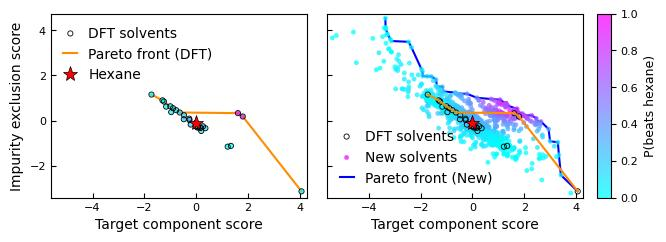

In [15]:
good = ['c16', 'd18', 'o18']
bad = ['bcr', 'pcc', 'tro', 'trs', 'dcg']

out, scaler = score_and_rank(ranked, good, bad, baseline='CCCCCC', n_draws=10000)

plot_pareto(out, n_label=0, savepath='pareto_front.png')

In [16]:
dfs_top = {}
dfs_top['all'] = out.sort_values(by='P_beats_CCCCCC', ascending=False)  #out.nlargest(20, 'P_beats_CCCCCC').iloc[::-1]

tags = ['dft','new']
for tag in tags:
    df = out[ out['tag']==tag ]
    df = df.sort_values(by='P_beats_CCCCCC', ascending=False)
    dfs_top[tag] = df

display( dfs_top['dft'].head(3) , dfs_top['new'].head(3) )

,Name,Inchi,tag,Synonym,Tb_K,Tm_K,logP_c16,logP_c16_err,logP_d18,logP_d18_err,...,z_logP_trs,z_logP_dcg,Gi,Bi,bad_rejection_score,composite,composite_std,det_front,P_pareto,P_beats_CCCCCC
SMILES,,,,,,,,,,,,,,,,,,,,,
CCCCCCCCCCO,1-DECANOL,InChI=1S/C10H22O/c1-2-3-4-5-6-7-8-9-10-11/h11H...,dft,NaN,520.58,263.28,7.717497,0.295062,8.147557,0.460348,...,-1.029646,0.745944,1.610308,-0.334449,0.334449,1.944758,0.545694,False,0.0004,0.9048
CCCCCCCCCO,1-NONANOL,"InChI=1S/C9H20O/c1-2-3-4-5-6-7-8-9-10/h10H,2-9...",dft,NaN,497.70,252.01,7.730377,0.294080,8.290248,0.432725,...,-0.792402,0.962631,1.796898,-0.186565,0.186565,1.983463,0.516140,False,0.0002,0.8226
CCCCCCC,N-HEPTANE,"InChI=1S/C7H16/c1-3-5-7-6-4-2/h3-7H2,1-2H3",dft,NaN,359.76,168.65,6.313436,0.290246,7.560311,0.410907,...,0.168073,-0.069766,-0.267270,-0.088752,0.088752,-0.178518,0.497518,False,0.0000,0.2588


,Name,Inchi,tag,Synonym,Tb_K,Tm_K,logP_c16,logP_c16_err,logP_d18,logP_d18_err,...,z_logP_trs,z_logP_dcg,Gi,Bi,bad_rejection_score,composite,composite_std,det_front,P_pareto,P_beats_CCCCCC
SMILES,,,,,,,,,,,,,,,,,,,,,
CCCCCCCCCCCO,1-Undecanol,InChI=1S/C11H24O/c1-2-3-4-5-6-7-8-9-10-11-12/h...,new,1-UNDECANOL,543.46,274.55,7.707602,0.295994,8.016533,0.507771,...,-1.270265,0.553210,1.436742,-0.470636,0.470636,1.907377,0.607857,False,0.0005,0.9216
CCCCCCCCCCCCO,1-Dodecanol,InChI=1S/C12H26O/c1-2-3-4-5-6-7-8-9-10-11-12-1...,new,1-DODECANOL,566.34,285.82,7.699810,0.296860,7.898046,0.577382,...,-1.501551,0.389389,1.278240,-0.592964,0.592964,1.871204,0.705192,False,0.0013,0.9095
C1CCCCC(CCCC1)O,NaN,InChI=1S/C10H20O/c11-10-8-6-4-2-1-3-5-7-9-10/h...,new,NaN,557.21,256.58,7.271357,0.394469,8.781084,0.810646,...,-0.857367,0.373642,1.723501,-0.525662,0.525662,2.249163,0.787367,True,0.0081,0.8956


In [17]:
def get_synonyms(smi):
    results = None
    try:
        results = pcp.get_compounds(smi, 'smiles')
    except:
        time.sleep(1.0)
        results = pcp.get_compounds(smi, 'smiles')
    if results is None:
        time.sleep(2.0)
        results = pcp.get_compounds(smi, 'smiles')

    output = []
    if len(results)==1: # Found the only matched compound
        names = results[0].synonyms
        if len(names)>=3:
            output = names[:3]
        else:
            output = names + ['-']*( 3 - len(names) )
    else:
        print( smi, 'cannot find name')
        output = ['-']*3
    print('Finished ', smi)
    return output

def add_synonyms( df ):
    compound_synonyms = {}
    for name, smiles in zip(df['Name'], df.index):
        if pd.isna(name):
            sym = get_synonyms(smiles)
        else:
            sym = [name]*3
        compound_synonyms[smiles] = sym 
    compound_synonyms = pd.DataFrame.from_dict(compound_synonyms, orient="index", columns=['Name_synonyms1', 'Name_synonyms2', 'Name_synonyms3'] )
    compound_synonyms.index.name = 'SMILES'
    df_output = df.join(compound_synonyms)
    return df_output


df_candidate = add_synonyms( dfs_top['all'].head(20) )

Finished  C1CCCCC(CCCC1)O
Finished  C=CC1(CCCCC1)CCCO
Finished  C=CCCCCCCCCCCO
Finished  CC1(CCCCC1=C)CCO
Finished  CCCCCCC/C(=C/CO)/C
Finished  CCCCCC/C=C(/C)\CO
Finished  CC=CCCCCCCCCO
Finished  C=CCCCCCCCCCO
Finished  CCCCCCCCCCCC(C)O
Finished  CCCC1=CC=C(C=C1)O
Finished  CCCCCC/C=C/CCCO
Finished  CCCC/C=C\CCCCCO
Finished  CCCCCCCCCCCCC(C)O
Finished  CCCC1=CC(=CC=C1)O


--> 1-undecanol <--
--> 1-dodecanol <--
--> 1-decanol <--
--> cyclodecanol <--
--> 3-(1-vinylcyclohexyl)-1-propanol <--
--> 1-tridecanol <--
--> 11-dodecen-1-ol <--
--> 2-(1-methyl-2-methylene
cyclohexyl)-ethanol <--
--> (E)-3-methyldec-2-en-1-ol <--
--> (2z)-2-methyl-2-nonen-1-ol <--
--> 1-nonanol <--
--> undec-9-en-1-ol <--
--> 10-undecen-1-ol <--
--> 2-tridecanol <--
--> 4-propylphenol <--
--> 1-tetradecanol <--
--> (e)-4-undecen-1-ol <--
--> (z)-6-undecen-1-ol <--
--> 2-tetradecanol <--
--> 3-n-propylphenol <--


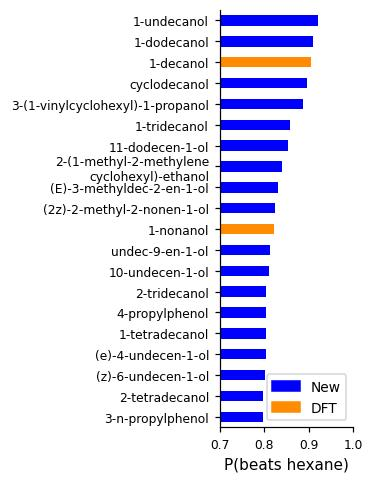

In [18]:
from matplotlib.patches import Patch

def customized_names(input_names):
    customized = {'2-(1-methyl-2-methylenecyclohexyl)ethanol': '2-(1-methyl-2-methylene\ncyclohexyl)-ethanol',
                 'SCHEMBL8998633':'(E)-3-methyldec-2-en-1-ol',
                  '(-)-Borneol': 'L-Borneol',
                  'RefChem:1092893':'bornan-2-exo-ol',
                 }
    input_names = [ customized[m] if m in customized else m.lower() for m in input_names ]
    print( '='*20 )
    for m in input_names:
        print('-->', m, '<--')
    print( '='*20 )
    return input_names
    
def plot_top_candidates(df, n=15, figsize=(3.5, 4.5), dpi=110, xlim=None, colorlist=None, savepath=None, legend=None):
    n = n if n<len(df) else len(df)
    df = df.head(n)
    if xlim is None:
        xlim = ( df['P_beats_CCCCCC'].min(), df['P_beats_CCCCCC'].max() )
    xrange = np.round( np.arange( np.round(xlim[0],1), xlim[1]+0.01, 0.1) , 1 )
    
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi, tight_layout=True)
    
    names = [r['Name_synonyms1'] if isinstance(r.get('Name_synonyms1'), str) else smi for smi, r in df.iterrows()]
    names = customized_names(names)
    if colorlist is None:
        colors = ['darkorange' if t == 'dft' else 'b' for t in df.tag]
    else:
        colors = colorlist

    bar_pos = n-np.arange(n)
    ax.barh(bar_pos, df['P_beats_CCCCCC'], color=colors, height=0.5)
    ax.set_yticks(bar_pos)
    ax.set_yticklabels(names, fontsize=7)
    ax.set_xticks(xrange)
    ax.set_xticklabels(xrange, fontsize=8)
    ax.set_xlabel(f'P(beats hexane)', fontsize=10)
    ax.set_xlim( xlim )
    ax.set_ylim( min(bar_pos)-0.5, max(bar_pos)+0.5 )
    #ax.axvline(0.5, color='0.6', ls=':', lw=0.8)
    ax.tick_params(direction='out', labelsize=8)
    #for i, (p, c) in enumerate(zip(top[pkey], top['composite'])):
    #    ax.text(p + 0.01, i, f'{p:.2f}  (S={c:+.2f})', va='center', fontsize=6)
    if legend is not None:
        ax.legend(handles=legend, fontsize=9, frameon=True, loc='lower right', ncol=1) # bbox_to_anchor=(0.0, -0.08),
    for s in ['top', 'right']: ax.spines[s].set_visible(False)
    if savepath: plt.savefig(savepath, dpi=400, bbox_inches='tight')
    return ax
    
plot_top_candidates(df_candidate, n=20, xlim=(0.7,1), savepath='top_candidates_OH.png', legend=[Patch(color='b', label='New'), Patch(color='darkorange', label='DFT')])
df_candidate.drop(columns=['Name', 'Synonym']).to_csv("Candidates_OH.csv", index=True)


In [19]:
# 3 classes of solvents" -OH, N, CH
df = dfs_top['all'] 
mask_O = np.array([ 'O' not in smi for smi in df.index ])
mask_N = np.array([ 'N' not in smi for smi in df.index ])
mask_N_notO    = np.all([mask_O, ~mask_N], axis=0)
mask_notN_notO = np.all([mask_O,  mask_N], axis=0) # Only CH

df_with_N = df[mask_N_notO]
df_CH = df[mask_notN_notO]

df_candidate_N = add_synonyms( df_with_N.head(10) )
df_candidate_CH = add_synonyms( df_CH.head(10) )

Finished  CC1=CC(=C(C=C1C)N)C
Finished  CC1=CC(=C(C(=C1)C)N)C
Finished  CCN(CC)C1=CC=CC=C1C
Finished  CCC(C)C(C)C(C)C
Finished  CC(C)CC(C)C(C)C
Finished  CC(C)CCC(C)C(C)C
Finished  CC(C)C(C(C)C)C(C)C
Finished  CCC(C)(CC)C(C)(C)C


--> 2,4,5-trimethylaniline <--
--> 2,4,6-trimethylaniline <--
--> 2,6-diethylaniline <--
--> indole <--
--> n-nonylamine <--
--> n-decylamine <--
--> n-butylaniline <--
--> n,n-diethylaniline <--
--> n,n-diethyl-o-toluidine <--
--> undecylamine <--
--> 2,3,4-trimethylpentane <--
--> 2,3,4-trimethylhexane <--
--> 2,3,5-trimethylhexane <--
--> heptane, 2,3,6-trimethyl- <--
--> 2,4-dimethyl-3-ethylpentane <--
--> 2,3,3,4-tetramethylpentane <--
--> 2,4-dimethyl-3-(propan-2-yl)pentane <--
--> 3-ethyl-2,2,3-trimethylpentane <--
--> 2,2,3,3-tetramethylhexane <--
--> 1-decene <--


<Axes: xlabel='P(beats hexane)'>

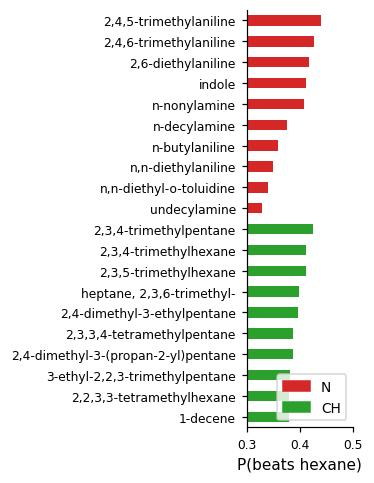

In [20]:
df_N_CH = pd.concat([df_candidate_N, df_candidate_CH], ignore_index=True)
colorlist = ['tab:red']*10 +  ['tab:green']*10  
df_N_CH.drop(columns=['Name', 'Synonym']).to_csv("Candidates_N_CH.csv", index=True)

plot_top_candidates(df_N_CH, n=20, xlim=(0.3,0.5), figsize=(3.5, 4.5), colorlist=colorlist, savepath='top_candidates_N_CH.png', legend=[Patch(color='tab:red', label='N'), Patch(color='tab:green', label='CH')] )


In [27]:
s1 = df_candidate.index.tolist() 
s1 = [ s1[n] for n in [0,4] ]
s2 = df_candidate_N.index.tolist() 
s2 = [ s2[n] for n in [0,3] ]
s3 = df_candidate_CH.index.tolist() 
s3 = [ s3[n] for n in [0] ]

#df_highlight = [ df_candidate.head(1), df_candidate_N.head(2), df_candidate_CH.head(1) ]
df_highlight =  [ df_candidate.loc[s1], df_candidate_N.loc[s2], df_candidate_CH.loc[s3] ]

df_highlight = pd.concat(df_highlight, ignore_index=False)
smiles_highlight = df_highlight.index.tolist()
names_highlight = df_highlight['Name_synonyms1'].str.lower().tolist()

df_highlight

,Name,Inchi,tag,Synonym,Tb_K,Tm_K,logP_c16,logP_c16_err,logP_d18,logP_d18_err,...,Bi,bad_rejection_score,composite,composite_std,det_front,P_pareto,P_beats_CCCCCC,Name_synonyms1,Name_synonyms2,Name_synonyms3
SMILES,,,,,,,,,,,,,,,,,,,,,
CCCCCCCCCCCO,1-Undecanol,InChI=1S/C11H24O/c1-2-3-4-5-6-7-8-9-10-11-12/h...,new,1-UNDECANOL,543.46,274.55,7.707602,0.295994,8.016533,0.507771,...,-0.470636,0.470636,1.907377,0.607857,False,0.0005,0.9216,1-Undecanol,1-Undecanol,1-Undecanol
C=CC1(CCCCC1)CCCO,NaN,InChI=1S/C11H20O/c1-2-11(9-6-10-12)7-4-3-5-8-1...,new,NaN,559.93,304.07,7.150721,0.447252,8.061596,0.518560,...,-0.754294,0.754294,1.968289,0.792564,False,0.0040,0.8867,3-(1-vinylcyclohexyl)-1-propanol,3-(1-vinyl-cyclohexyl)-propan-1-ol,-
CC1=CC(=C(C=C1C)N)C,NaN,"InChI=1S/C9H13N/c1-6-4-8(3)9(10)5-7(6)2/h4-5H,...",new,NaN,519.67,338.43,6.499698,1.196104,7.209759,0.693701,...,-0.767805,0.767805,0.698943,1.299860,False,0.0039,0.4404,"2,4,5-TRIMETHYLANILINE",137-17-7,Pseudocumidine
C1=CC=C2C(=C1)C=CN2,Indole,"InChI=1S/C8H7N/c1-2-4-8-7(3-1)5-6-9-8/h1-6,9H",new,indole,473.42,346.83,7.537637,1.043349,7.736936,0.702244,...,0.078393,-0.078393,0.804235,1.180619,False,0.0019,0.4111,Indole,Indole,Indole
CC(C)C(C)C(C)C,"2,3,4-Trimethylpentane","InChI=1S/C8H18/c1-6(2)8(5)7(3)4/h6-8H,1-5H3",new,"2,3,4-TRIMETHYLPENTANE",381.32,134.92,6.749586,0.376460,7.493026,0.743114,...,-0.140310,0.140310,0.349625,0.768561,False,0.0000,0.4246,"2,3,4-Trimethylpentane","2,3,4-Trimethylpentane","2,3,4-Trimethylpentane"


In [28]:
def relative_to_baseline(out, good, bad, baseline='CCCCCC', scale='z'):
    """
    Per-solute improvement over the baseline, oriented so that OUTWARD = BETTER
    on every axis:
        good solutes:  +(x_i - x_base)      (want higher logP)
        bad  solutes:  -(x_i - x_base)      (want lower  logP)
    scale='z'   : robust z-scored columns (z_logP_*); one comparable unit.
    scale='raw' : logP units; tro/trs (+-5) will visually swamp c16 (+-0.5).
    scale='pct' : percent change, 100*(x_i - x_base)/|x_base|, sign-flipped for
                  impurities. Well defined here because |logP_hexane| >= 6.5 on
                  every solute.
    """
    cols = {m: (f'z_logP_{m}' if scale == 'z' else f'logP_{m}') for m in good + bad}
    base = out.loc[baseline]
    rel = pd.DataFrame(index=out.index)
    for m in good + bad:
        d = out[cols[m]] - base[cols[m]]
        if scale == 'pct':
            b = abs(base[cols[m]])
            if b < 1e-6:
                raise ValueError(f'baseline logP for {m} is ~0; percent change undefined')
            d = 100.0 * d / b
        rel[m] = d #if m in good else -d
    return rel

def logp_per_z(out, solutes):
    """dlogP corresponding to one z-unit, per solute:  z = 0.6745*(x-med)/MAD
    so  dlogP = dz * MAD / 0.6745.  MAD recomputed from the same frame the
    z-scores were built on."""
    conv = {}
    for m in solutes:
        x = out[f'logP_{m}']
        mad = np.median(np.abs(x - x.median()))
        conv[m] = mad / 0.6745
    return conv

def radar_overlay(out, smiles_list, good, bad, header_to_name, baseline='CCCCCC', scale='z',
                  solutes=None, figsize=(7, 3), dpi=110, names=None, savepath=None,
                  rmax=None, rmin=None, unit_label=None, fill_alpha=0.05,
                  z_ticks=(-2, -1, 0, 1, 2), show_logp_ticks=True):
    """
    Several solvents on ONE radar (<=6 works well).
    solutes         : subset/order of axes; good/bad still set the sign (outward = better)
    show_logp_ticks : when scale='z', print the dlogP equivalent of each z gridline
                      along every spoke, so each axis reads in logP for that solute.
    """
    solutes = list(solutes) if solutes is not None else (good + bad)
    rel = relative_to_baseline(out, good, bad, baseline, scale).loc[smiles_list, solutes]
    labels = [header_to_name.get(s, s) for s in solutes]
    k = len(solutes)
    ang = np.linspace(0, 2*np.pi, k, endpoint=False); ang_c = np.r_[ang, ang[:1]]

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi, subplot_kw=dict(polar=True))
    if rmax is None: rmax = max(np.nanmax(np.abs(rel.values)) * 1.1, max(abs(t) for t in z_ticks) * 1.1)
    if rmin is None: rmin = -rmax -0.5
    ax.plot(ang_c, np.zeros_like(ang_c), color='k', lw=1.0, ls='--', label='Hexane (baseline)', zorder=8)
    cmap = plt.get_cmap('Set1')
    for i, smi in enumerate(smiles_list):
        v = rel.loc[smi].values; vc = np.r_[v, v[:1]]
        nm = (names[i] if names is not None else
              (out.loc[smi, 'Name'] if isinstance(out.loc[smi].get('Name'), str) else smi))
        ax.plot(ang_c, vc, color=cmap(i), lw=2, marker='', ms=3, label=str(nm)[:])
        ax.fill(ang_c, vc, color=cmap(i), alpha=fill_alpha)
        
    ax.set_ylim(rmin, rmax)
    ax.set_theta_offset(np.pi/2); ax.set_theta_direction(-1)
    ax.set_xticks(ang)

    bbox_props = dict(boxstyle='round,pad=0.3', fc='silver', ec='gray', alpha=0.5)

    if scale == 'z' and show_logp_ticks:
        conv = logp_per_z(out, solutes)
        # axis label carries the conversion factor
        ax.set_xticklabels([f'{lab}\n(grid={conv[s]:.1f}×ΔlogP)' for lab, s in zip(labels, solutes)], fontsize=7, bbox=bbox_props) # f'{lab}\n(1 grid = {conv[s]:.1f}×ΔlogP)' 
        ax.tick_params(axis='x', pad=5) 
        # per-spoke dlogP labels at each z gridline
        ax.set_yticks(list(z_ticks) + [0]); ax.set_yticklabels([])
        for a, s in zip(ang, solutes):
            for zt in z_ticks:
                if rmin < zt < rmax:
                    ax.text(a, zt, f'{zt*conv[s]:+.1f}' if zt!=0 else '0', fontsize=5, color='0.35', ha='center', va='center', zorder=10,
                            bbox=dict(boxstyle='round,pad=0.12', fc='white', ec='none', alpha=0.85))
        ttl = 'improvement vs hexane -- numbers along each spoke are dlogP for that solute'
    else:
        ax.set_xticklabels(labels, fontsize=7)
        ax.tick_params(axis='y', labelsize=6)
        ttl = unit_label or {'pct': '% change vs hexane', 'z': 'z-units vs hexane', 'raw': 'dlogP vs hexane'}[scale]
    print( ttl + '   (outward = better)', )#fontsize=7.5, pad=16 )
    ax.legend(fontsize=9, frameon=False, loc='upper left', bbox_to_anchor=(1.4, 1.05))
    ax.grid(lw=0.4, alpha=0.6)
    if savepath: plt.savefig(savepath, dpi=400, bbox_inches='tight')
    return rel


improvement vs hexane -- numbers along each spoke are dlogP for that solute   (outward = better)


,c16,bcr,pcc,tro,dcg
SMILES,,,,,
CCCCCCCCCCCO,2.994302,-2.403516,2.003569,-1.113647,0.366665
C=CC1(CCCCC1)CCCO,1.701505,-2.869167,2.189204,-0.708311,-1.004185
CC1=CC(=C(C=C1C)N)C,0.190156,-2.726138,1.490605,-1.266294,-0.577151
C1=CC=C2C(=C1)C=CN2,2.599730,-0.091513,1.585446,0.199929,-0.909631
CC(C)C(C)C(C)C,0.770271,-0.114490,0.073450,-0.444616,-0.506777


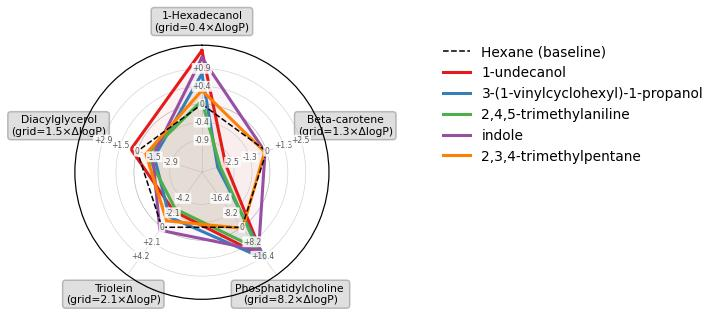

In [29]:
radar_overlay(dfs_top['all'], smiles_highlight, good, bad, header_to_name, scale='z', solutes=['c16','bcr','pcc','tro','dcg'], names=names_highlight,
              savepath='radar_map.png')

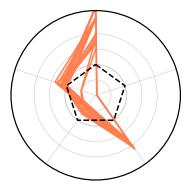

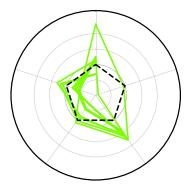

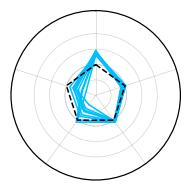

In [30]:
def radar_overlay_compact(out, smiles_list, good, bad, header_to_name, baseline='CCCCCC', scale='z', color='r',
                  solutes=None, figsize=(2, 2), dpi=110, names=None, savepath=None,
                  rmax=None, rmin=None, unit_label=None, fill_alpha=0.001,
                  z_ticks=(-2, -1, 0, 1, 2), show_logp_ticks=True):
    solutes = list(solutes) if solutes is not None else (good + bad)
    rel = relative_to_baseline(out, good, bad, baseline, scale).loc[smiles_list, solutes]
    labels = [header_to_name.get(s, s) for s in solutes]
    k = len(solutes)
    ang = np.linspace(0, 2*np.pi, k, endpoint=False); ang_c = np.r_[ang, ang[:1]]

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi, subplot_kw=dict(polar=True))
    if rmax is None: rmax = max(np.nanmax(np.abs(rel.values)) * 1.1, max(abs(t) for t in z_ticks) * 1.1)
    if rmin is None: rmin = -rmax -0.5
    ax.plot(ang_c, np.zeros_like(ang_c), color='k', lw=1.0, ls='--', label='Hexane (baseline)', zorder=8)
    for i, smi in enumerate(smiles_list):
        v = rel.loc[smi].values; vc = np.r_[v, v[:1]]
        nm = (names[i] if names is not None else
              (out.loc[smi, 'Name'] if isinstance(out.loc[smi].get('Name'), str) else smi))
        ax.plot(ang_c, vc, color=color, lw=1, marker='', ms=3, label=str(nm)[:])
        ax.fill(ang_c, vc, color=color, alpha=fill_alpha)
        
    ax.set_ylim(rmin, rmax)
    ax.set_theta_offset(np.pi/2); ax.set_theta_direction(-1)
    ax.set_xticks(ang)

    bbox_props = dict(boxstyle='round,pad=0.3', fc='silver', ec='gray', alpha=0.5)

    if scale == 'z' and show_logp_ticks:
        conv = logp_per_z(out, solutes)
        # axis label carries the conversion factor
        #ax.set_xticklabels([f'{lab}\n(grid={conv[s]:.1f}×ΔlogP)' for lab, s in zip(labels, solutes)], fontsize=7, bbox=bbox_props) # f'{lab}\n(1 grid = {conv[s]:.1f}×ΔlogP)' 
        ax.tick_params(axis='x', pad=5) ; ax.set_xticklabels([])
        # per-spoke dlogP labels at each z gridline
        ax.set_yticks(list(z_ticks) + [0]); ax.set_yticklabels([])
    ax.grid(lw=0.4, alpha=0.6)
    if savepath: plt.savefig(savepath, dpi=400, bbox_inches='tight')
    return rel

colors = ['coral','lawngreen','deepskyblue']
for i_df, df in enumerate([df_candidate, df_candidate_N, df_candidate_CH]):
    s1 = df.index.tolist() 
    name_s1 = df['Name_synonyms1'].str.lower().tolist()
    radar_overlay_compact(dfs_top['all'], s1, good, bad, header_to_name, scale='z', solutes=['c16','bcr','pcc','tro','dcg'], color=colors[i_df],
                      names=name_s1, rmax=3.5, rmin=-2, savepath=f'radar_map_compact_{i_df}.png')

# VGO, MCO, HCO...

In [53]:
%%capture --no-display

# VGO, MGO, HGO... all contain long chains
temp_K = 273.15+25

inp_smiles = ['C'*6] + ['C'*n for n in range(10,37) ] 

df_solvents = {}
for n, mol_tag in enumerate(header_to_name):
    model_file = os.path.join(models_zoo_path, f'model_info_{mol_tag}.pkl')
    predictions_summary = predict_from_smiles(model_file, inp_smiles, temp_K=temp_K)
    logp = predictions_summary['logP_mean'] 
    logp_uncertainty = predictions_summary['logP_std'] 
    
    df_solvents[f'logP_{mol_tag}'] = logp
    df_solvents[f'logP_{mol_tag}_err'] = logp_uncertainty
    df_solvents = pd.DataFrame(df_solvents)
df_solvents.index = inp_smiles

df_solvents

,logP_c16,logP_c16_err,logP_d18,logP_d18_err,logP_o18,logP_o18_err,logP_bcr,logP_bcr_err,logP_dcg,logP_dcg_err,...,logP_pcs,logP_pcs_err,logP_tro,logP_tro_err,logP_trs,logP_trs_err,logP_bdo,logP_bdo_err,logP_wat,logP_wat_err
CCCCCC,6.417787,0.296724,7.722957,0.417669,6.782512,0.621561,17.059987,0.451063,13.339799,0.948085,...,-26.825460,1.379280,25.135949,0.937442,26.814541,1.084508,-2.848059,0.190441,-4.233117,0.191234
CCCCCCCCCC,6.152396,0.287035,7.169877,0.413541,6.307155,0.630462,16.484793,0.438680,12.292507,0.958489,...,-26.665562,1.391638,23.640375,0.918930,25.155033,1.111981,-2.973685,0.184936,-4.254252,0.189742
CCCCCCCCCCC,6.123632,0.287326,7.067678,0.416878,6.227145,0.637063,16.419894,0.440108,12.143691,0.971236,...,-26.596844,1.407705,23.366248,0.935810,24.880116,1.138068,-3.006984,0.186710,-4.255168,0.190708
CCCCCCCCCCCC,6.101183,0.287746,6.978652,0.420461,6.148104,0.646346,16.368505,0.441634,11.970606,1.007015,...,-26.531029,1.422646,23.120259,0.951334,24.630023,1.189418,-3.031032,0.188492,-4.255183,0.193162
CCCCCCCCCCCCC,6.083278,0.288206,6.902611,0.425158,6.071394,0.656031,16.326917,0.443121,11.808519,1.054164,...,-26.452288,1.435087,22.898379,0.959904,24.394101,1.237830,-3.058149,0.191626,-4.253486,0.197449
CCCCCCCCCCCCCC,6.068714,0.288667,6.839349,0.433288,6.000343,0.662617,16.292610,0.444516,11.648041,1.054374,...,-26.332727,1.451387,22.698119,0.964314,24.169278,1.239784,-3.076303,0.195077,-4.247403,0.200519
CCCCCCCCCCCCCCC,6.056669,0.289109,6.788585,0.448709,5.938192,0.674073,16.263825,0.445804,11.516500,1.020596,...,-26.152168,1.494885,22.518699,0.985861,23.961333,1.204979,-3.093880,0.201820,-4.233638,0.205191
CCCCCCCCCCCCCCCC,6.046549,0.289526,6.749935,0.476318,5.887663,0.711840,16.239300,0.446983,11.399617,1.092700,...,-25.902155,1.596304,22.360953,1.069772,23.783682,1.303313,-3.103335,0.210103,-4.211700,0.216551
CCCCCCCCCCCCCCCCC,6.037933,0.289916,6.722906,0.520827,5.848996,0.792203,16.218117,0.448063,11.316576,1.407677,...,-25.586781,1.781031,22.227040,1.268715,23.653797,1.800441,-3.108465,0.225430,-4.183750,0.237589
CCCCCCCCCCCCCCCCCC,6.030501,0.290281,6.706897,0.585333,5.820987,0.911342,16.199587,0.449054,11.242697,1.924371,...,-25.216946,2.046220,22.119962,1.609010,23.588275,2.722421,-3.106871,0.242805,-4.155199,0.262832


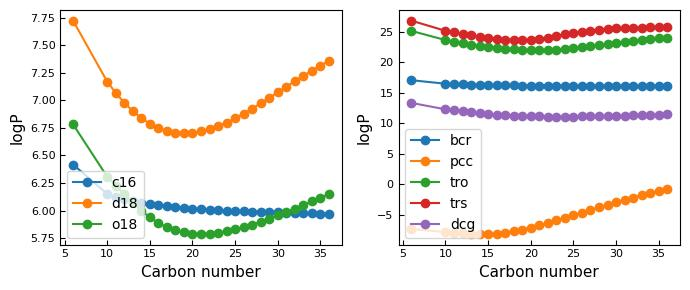

In [55]:
x = [ len(smi) for smi in df_solvents.index.to_list() ]

good = ['c16', 'd18', 'o18']
bad = ['bcr', 'pcc', 'tro', 'trs', 'dcg']

fig, axs = plt.subplots(1,2,figsize=(3.5*2,3), tight_layout=True,dpi=100)
#fig.subplots_adjust(wspace=0.0, bottom=0.2, left=0.2, right=0.95, top=0.95)

for mol_tag in good: 
    y = df_solvents[ f'logP_{mol_tag}' ]
    axs[0].plot( x,y, marker='o', label=mol_tag )#color=colors[n], alpha=0.5, ms=5, lw=0.5,   )# zorder=1)
    
for mol_tag in bad:
    y = df_solvents[ f'logP_{mol_tag}' ]
    axs[1].plot( x,y, marker='o', label=mol_tag )
#axs.set_ylim(5.5, 7.2)
#axs.set_xlim( )

for n in [0,1]:
    axs[n].set_xlabel('Carbon number',fontsize=11) ## input X name
    axs[n].set_ylabel('logP',fontsize=11, color='k') 
    axs[n].tick_params(which='both', direction='in',labelsize='8')
    axs[n].legend(fontsize=10, frameon=True, loc='lower left', ncol=1, )

#lower_limit = cutoff_logP 
#upper_limit = new_solvent.iloc[-1]['logP']
#print( lower_limit, upper_limit )
#y_upper = np.full(len(x), upper_limit )
#y_lower = np.full(len(x), lower_limit )
#axs.fill_between(x, y_lower, y_upper, alpha=0.15, color='y')
#axs.plot( (0,len(new_solvent)) , (lower_limit,lower_limit), color='k', lw=0.5, ls='--')   

#plt.savefig('Carbon_numbers.png', dpi=800)
plt.show()

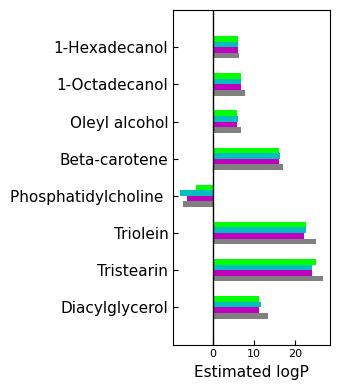

In [60]:
MCO = {11:2.52, 12:34.64, 14:18.65, 15:16.46, 16:10.52, 17:4.71, 18:9.2, 19:1.92 }
HCO = {12:1.56, 14:1.94, 15:1.38, 16:3.5, 17:4.32, 18:14.77, 20:14.66, 22:18.41, 24:18.6, 26:10.52, 28:7.34, 30:2.64 }
VGO = {18:1.74, 20:2.15, 24:21.48, 28:63.8, 32:8.03, 36:1.5 }

hexane = df_solvents.loc['CCCCCC'][ [f'logP_{mol_tag}' for mol_tag in good+bad] ]
fig, axs = plt.subplots(1,1,figsize=(3.5,4), tight_layout=True,dpi=100)
colors = ['lime','c','m']
y = np.arange( len(good+bad) )

score_header = [ 'good_score','bad_score','composite_score' ]
labels=['VGO', 'MCO', 'HCO']
df_petro_cut = {}
for n,O in enumerate([VGO, MCO, HCO]):
    carbon_number = np.array([k for k in O.keys() ])
    wt = np.array([v for v in O.values() ])
    smiles = ['C'*c for c in carbon_number ]
    df = df_solvents.loc[ smiles ]
    logp = [ np.sum( df[f'logP_{mol_tag}'] * wt ) / np.sum(wt) for mol_tag in good+bad ]
    #scores = [ np.sum( df[s] * wt ) / np.sum(wt) for s in score_header ]
    axs.barh( y+0.15*(n-1)-0.075, logp, height=0.15, color=colors[n], label=labels[n] )
    #df_petro_cut[ labels[n] ] = np.concatenate([logp, scores])
#df_petro_cut = pd.DataFrame.from_dict(df_petro_cut, orient="index", columns=[f'logP_{mol_tag}' for mol_tag in good+bad]+score_header )

axs.plot( [0,0], [min(y)-1,max(y)+1], color='k', lw=1 )
axs.barh( y+0.15*2-0.075, hexane, height=0.15, color='gray', label='Hexane')

axs.set_ylim((min(y)-1,max(y)+1))
axs.tick_params(which='both', direction='in',labelsize='8')
axs.set_xlabel('Estimated logP',fontsize=11, color='k')
axs.set_yticks(y)
axs.set_yticklabels([ header_to_name[mol_tag] for mol_tag in good+bad ] , fontsize=11 )
axs.invert_yaxis()   # keeps the first category at the top, matching your original left-to-right order
#axs.legend(fontsize=9, frameon=True, loc='upper right', ncol=1, )
#plt.savefig('Petroleum.png', dpi=800)
plt.show()

In [81]:
df_petro_cut['tag'] = 'pet'
df_output = pd.read_csv('Selected_Candidates.csv' , index_col=0)
df_output = pd.concat( [df_output, df_petro_cut] )
df_output = df_output[ ['tag']+[f'logP_{mol_tag}' for mol_tag in good+bad]+score_header ]
df_output

,tag,logP_c16,logP_d18,logP_o18,logP_bcr,logP_pcc,logP_tro,logP_trs,logP_dcg,good_score,bad_score,composite_score
CCCCCCCCCO,dft,7.230000,8.960000,7.780000,13.690000,11.910000,22.890000,24.780000,14.360000,1.139689,-0.813626,0.326063
CCCCCCCCCCO,dft,7.050000,8.960000,7.630000,13.570000,11.170000,22.430000,24.310000,14.010000,1.076188,-0.759751,0.316437
C1=CC=C(C=C1)OC2=CC=CC=C2,dft,8.190000,9.510000,7.560000,20.000000,5.470000,31.030000,32.870000,16.450000,1.429076,-1.134752,0.294324
CCCCCC,dft,6.530000,7.580000,7.090000,17.470000,-7.280000,25.330000,26.900000,13.480000,0.637042,-0.376491,0.260551
CCCCCCC,dft,6.400000,7.510000,6.940000,17.120000,-7.560000,24.730000,26.580000,13.170000,0.573051,-0.332420,0.240631
CCCCOCCCC,dft,6.800000,8.250000,7.510000,15.950000,1.480000,25.440000,27.130000,14.770000,0.876816,-0.653870,0.222946
CCCCCCCC,dft,6.280000,7.470000,6.770000,16.800000,-7.770000,24.240000,26.260000,12.880000,0.513784,-0.293662,0.220122
CCCCCCCCC,dft,6.170000,7.440000,6.610000,16.560000,-7.930000,23.880000,25.930000,12.600000,0.460025,-0.260730,0.199296
CC1=CC(=CC(=C1)C)C,dft,6.650000,7.780000,6.910000,17.150000,-4.190000,25.350000,27.370000,13.680000,0.674390,-0.477843,0.196547
CC(C)C1=CC=CC=C1,dft,6.750000,7.650000,7.260000,17.330000,-3.330000,26.330000,27.190000,14.220000,0.724958,-0.539767,0.185190


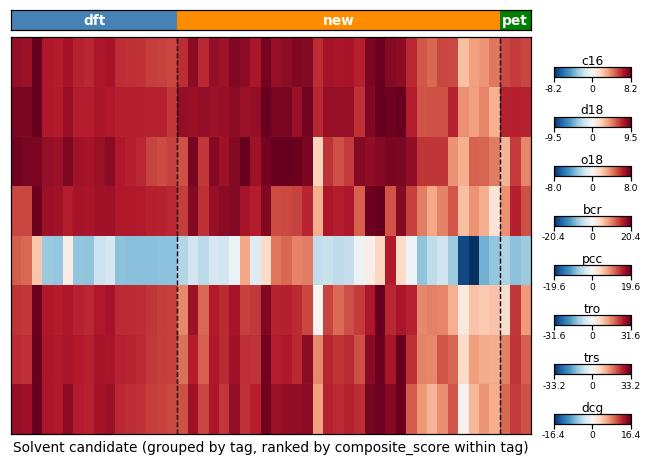

In [97]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

logp_cols = [c for c in df_output.columns if c.startswith('logP_')]
n_solutes = len(logp_cols)
tag_colors = {'dft': 'steelblue', 'new': 'darkorange', 'pet': 'green'}

tag_rank_map = {'dft': 0, 'new': 1, 'pet': 2}
df_sorted = df_output.copy()
df_sorted['tag_rank'] = df_sorted['tag'].map(tag_rank_map)
df_sorted = df_sorted.sort_values(['tag_rank', 'composite_score'], ascending=[True, False])
n = len(df_sorted)

tags_seq = df_sorted['tag'].values
boundaries = [i + 0.5 for i in range(len(tags_seq) - 1) if tags_seq[i] != tags_seq[i+1]]

# (1) Extra invisible SPACER row between the tag strip and the data rows
fig, axs = plt.subplots(n_solutes + 2, 1, figsize=(7, 5), dpi=110,
                          gridspec_kw={'height_ratios': [0.4, 0.15] + [1]*n_solutes, 'hspace': 0})
fig.subplots_adjust(right=0.8)

ax_tag = axs[0]
tag_numeric = df_sorted['tag'].map(tag_rank_map).values.reshape(1, -1)
ax_tag.imshow(tag_numeric, cmap=ListedColormap(list(tag_colors.values())), aspect='auto')
ax_tag.set_xticks([]); ax_tag.set_yticks([])

# (2) Tag labels drawn directly on the bar -- no separate legend
tag_list = df_sorted['tag'].values
start = 0
for k in range(1, len(tag_list) + 1):
    if k == len(tag_list) or tag_list[k] != tag_list[start]:
        center = (start + k - 1) / 2
        ax_tag.text(center, 0, tag_list[start], ha='center', va='center',
                    fontsize=9, color='white', fontweight='bold')
        start = k

ax_spacer = axs[1]
ax_spacer.axis('off')  # invisible -- exists purely to create the visual gap

for i, col in enumerate(logp_cols):
    ax = axs[i + 2]
    row_data = df_sorted[col].values.reshape(1, -1)
    vmax = np.abs(row_data).max()
    im = ax.imshow(row_data, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_yticks([])

    # (3) Grey lines between rows; black only for the outer top/bottom frame
    ax.spines['top'].set_visible(i == 0)
    if i == 0:
        ax.spines['top'].set_color('black')
    ax.spines['bottom'].set_visible(True)
    if i == n_solutes - 1:
        ax.spines['bottom'].set_color('black')
    else:
        ax.spines['bottom'].set_color('grey')
        ax.spines['bottom'].set_linewidth(0.7)

    for b in boundaries:
        ax.axvline(b, color='black', linestyle='--', linewidth=0.9)

    # (4) No x-axis ticks or number labels at all
    ax.set_xticks([])

    pos = ax.get_position()
    cax = fig.add_axes([pos.x1 + 0.03, pos.y0 + pos.height*0.2, 0.1, pos.height*0.2])
    cbar = fig.colorbar(im, cax=cax, orientation='horizontal')
    cbar.ax.tick_params(labelsize=6, pad=1)
    cbar.set_ticks([-vmax, 0, vmax])
    cbar.ax.set_xticklabels([f'{-vmax:.1f}', '0', f'{vmax:.1f}'])
    cax.set_title(col.replace('logP_', ''), fontsize=8, pad=2)

axs[-1].set_xlabel('Solvent candidate (grouped by tag, ranked by composite_score within tag)', fontsize=9)

#plt.savefig('heatmap_final.png', dpi=150)
plt.show()